# Turmeric Price Prediction – Duggirala APMC

### Objective
Predict the next trading day's modal price of Turmeric Finger
at Duggirala APMC, Guntur, Andhra Pradesh.

### Data Source
Government of India – Open Government Data (OGD) Platform

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("/content/raw_turmeric_mandi_data.csv.csv")

In [3]:
df.head()

,Arrival_Date,Commodity,Commodity_Code,District,Grade,Market,Max_Price,Min_Price,Modal_Price,State,Variety
0,02/07/2024,Turmeric,39,Guntur,FAQ,Duggirala,13000.0,11000.0,12750.0,Andhra Pradesh,Bulb
1,24/07/2024,Turmeric,39,Guntur,FAQ,Duggirala,13300.0,11800.0,13000.0,Andhra Pradesh,Bulb
2,01/07/2024,Turmeric,39,Guntur,FAQ,Duggirala,13720.0,12500.0,12575.0,Andhra Pradesh,Finger
3,12/07/2024,Turmeric,39,Guntur,FAQ,Duggirala,13600.0,10000.0,13400.0,Andhra Pradesh,Finger
4,15/07/2024,Turmeric,39,Guntur,FAQ,Duggirala,13625.0,12300.0,13481.0,Andhra Pradesh,Finger


In [4]:
df.shape

(1563, 11)

In [5]:
df.columns

Index(['Arrival_Date', 'Commodity', 'Commodity_Code', 'District', 'Grade',
       'Market', 'Max_Price', 'Min_Price', 'Modal_Price', 'State', 'Variety'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1563 entries, 0 to 1562
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Arrival_Date    1563 non-null   object 
 1   Commodity       1563 non-null   object 
 2   Commodity_Code  1563 non-null   int64  
 3   District        1563 non-null   object 
 4   Grade           1563 non-null   object 
 5   Market          1563 non-null   object 
 6   Max_Price       1563 non-null   float64
 7   Min_Price       1563 non-null   float64
 8   Modal_Price     1563 non-null   float64
 9   State           1563 non-null   object 
 10  Variety         1563 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 134.4+ KB


In [7]:
df.isnull().sum()

,0
Arrival_Date,0
Commodity,0
Commodity_Code,0
District,0
Grade,0
Market,0
Max_Price,0
Min_Price,0
Modal_Price,0
State,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Variety"].value_counts()

,count
Variety,
Finger,787
Bulb,775
Local,1


In [10]:
df["Market"].value_counts()

,count
Market,
Duggirala,1309
Duggirala APMC,254


In [11]:
df["Commodity"].value_counts()

,count
Commodity,
Turmeric,1563


In [12]:
print("States:")
print(df["State"].unique())

print("\nDistricts:")
print(df["District"].unique())

States:
['Andhra Pradesh']

Districts:
['Guntur']


In [13]:
df["Arrival_Date"].head(10)

,Arrival_Date
0,02/07/2024
1,24/07/2024
2,01/07/2024
3,12/07/2024
4,15/07/2024
5,22/08/2024
6,01/08/2024
7,05/08/2024
8,19/08/2024
9,10/06/2024


In [14]:
df["Arrival_Date"].tail(10)

,Arrival_Date
1553,01/06/2026
1554,05/06/2026
1555,09/06/2026
1556,09/07/2026
1557,24/07/2026
1558,15/07/2026
1559,05/08/2026
1560,31/08/2026
1561,18/08/2026
1562,20/08/2026


In [15]:
df["Arrival_Date"] = pd.to_datetime(
    df["Arrival_Date"],
    dayfirst=True,
    errors="coerce"
)

In [16]:
df["Arrival_Date"].isnull().sum()

np.int64(0)

In [17]:
print("Earliest date:", df["Arrival_Date"].min())
print("Latest date:", df["Arrival_Date"].max())

Earliest date: 2021-04-09 00:00:00
Latest date: 2026-09-07 00:00:00


In [18]:
df[["Min_Price", "Max_Price", "Modal_Price"]].describe()

,Min_Price,Max_Price,Modal_Price
count,1563.000000,1563.000000,1563.000000
mean,8420.381949,9654.473865,9332.625070
std,2925.776370,3145.945234,3132.706066
min,2600.000000,0.000000,2600.000000
25%,5300.000000,6200.000000,5900.000000
50%,9100.000000,10411.000000,10200.000000
75%,10550.000000,12000.000000,11650.000000
max,15050.000000,16466.662550,16466.662550


In [19]:
df[["Min_Price", "Max_Price", "Modal_Price"]].dtypes

,0
Min_Price,float64
Max_Price,float64
Modal_Price,float64


In [20]:
df.sample(10)

,Arrival_Date,Commodity,Commodity_Code,District,Grade,Market,Max_Price,Min_Price,Modal_Price,State,Variety
1460,2026-07-13,Turmeric,39,Guntur,Local,Duggirala APMC,14175.0,12000.0,13900.0,Andhra Pradesh,Finger
817,2024-01-22,Turmeric,39,Guntur,FAQ,Duggirala,10150.0,9400.0,10001.0,Andhra Pradesh,Finger
1286,2023-04-12,Turmeric,39,Guntur,FAQ,Duggirala,4900.0,4000.0,4700.0,Andhra Pradesh,Finger
1420,2026-02-04,Turmeric,39,Guntur,Local,Duggirala APMC,13325.0,11950.0,13300.0,Andhra Pradesh,Finger
168,2025-02-28,Turmeric,39,Guntur,FAQ,Duggirala,10500.0,8450.0,10500.0,Andhra Pradesh,Finger
934,2023-07-25,Turmeric,39,Guntur,FAQ,Duggirala,9641.0,8400.0,9275.0,Andhra Pradesh,Finger
1436,2026-04-23,Turmeric,39,Guntur,Local,Duggirala APMC,11900.0,10000.0,11100.0,Andhra Pradesh,Bulb
91,2022-05-05,Turmeric,39,Guntur,FAQ,Duggirala,6000.0,4500.0,5800.0,Andhra Pradesh,Finger
1543,2026-04-24,Turmeric,39,Guntur,Local,Duggirala APMC,11750.0,10300.0,11350.0,Andhra Pradesh,Bulb
26,2024-02-19,Turmeric,39,Guntur,FAQ,Duggirala,11700.0,9800.0,11700.0,Andhra Pradesh,Finger


Step 2: Data Cleaning


In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df[df["Max_Price"] == 0]

,Arrival_Date,Commodity,Commodity_Code,District,Grade,Market,Max_Price,Min_Price,Modal_Price,State,Variety
227,2023-08-02,Turmeric,39,Guntur,FAQ,Duggirala,0.0,8411.0,9700.0,Andhra Pradesh,Finger


In [23]:
print("Zero Min_Price:", (df["Min_Price"] == 0).sum())
print("Zero Max_Price:", (df["Max_Price"] == 0).sum())
print("Zero Modal_Price:", (df["Modal_Price"] == 0).sum())

Zero Min_Price: 0
Zero Max_Price: 1
Zero Modal_Price: 0


In [24]:
invalid_price_rows = df[
    (df["Min_Price"] > df["Modal_Price"]) |
    (df["Modal_Price"] > df["Max_Price"])
]

print("Invalid price rows:", len(invalid_price_rows))

Invalid price rows: 1


In [25]:
df["Market"].value_counts()

,count
Market,
Duggirala,1309
Duggirala APMC,254


In [26]:
df["Grade"].value_counts()

,count
Grade,
FAQ,1318
Local,245


In [27]:
print("Commodity:")
print(df["Commodity"].value_counts())

print("\nState:")
print(df["State"].value_counts())

print("\nDistrict:")
print(df["District"].value_counts())

Commodity:
Commodity
Turmeric    1563
Name: count, dtype: int64

State:
State
Andhra Pradesh    1563
Name: count, dtype: int64

District:
District
Guntur    1563
Name: count, dtype: int64


In [28]:
pd.crosstab(df["Variety"], df["Grade"])

Grade,FAQ,Local
Variety,,
Bulb,654,121
Finger,663,124
Local,1,0


In [29]:
pd.crosstab(df["Variety"], df["Market"])

Market,Duggirala,Duggirala APMC
Variety,,
Bulb,650,125
Finger,659,128
Local,0,1


In [30]:
invalid_price_rows

,Arrival_Date,Commodity,Commodity_Code,District,Grade,Market,Max_Price,Min_Price,Modal_Price,State,Variety
227,2023-08-02,Turmeric,39,Guntur,FAQ,Duggirala,0.0,8411.0,9700.0,Andhra Pradesh,Finger


In [31]:
finger_df = df[df["Variety"] == "Finger"].copy()

In [32]:
finger_df.shape

(787, 11)

In [33]:
finger_df["Market"] = finger_df["Market"].replace(
    {
        "Duggirala": "Duggirala APMC",
        "Duggirala APMC": "Duggirala APMC"
    }
)

In [34]:
finger_df["Market"].value_counts()

,count
Market,
Duggirala APMC,787


In [35]:
print("Invalid Max_Price rows:",
      (finger_df["Max_Price"] == 0).sum())

Invalid Max_Price rows: 1


In [36]:
finger_df = finger_df[finger_df["Max_Price"] > 0].copy()

In [37]:
finger_df.shape

(786, 11)

In [38]:
invalid_price_rows = finger_df[
    (finger_df["Min_Price"] > finger_df["Modal_Price"]) |
    (finger_df["Modal_Price"] > finger_df["Max_Price"])
]

print("Invalid price rows:", len(invalid_price_rows))

Invalid price rows: 0


In [39]:
finger_df.isnull().sum()

,0
Arrival_Date,0
Commodity,0
Commodity_Code,0
District,0
Grade,0
Market,0
Max_Price,0
Min_Price,0
Modal_Price,0
State,0


In [40]:
finger_df.head()

,Arrival_Date,Commodity,Commodity_Code,District,Grade,Market,Max_Price,Min_Price,Modal_Price,State,Variety
2,2024-07-01,Turmeric,39,Guntur,FAQ,Duggirala APMC,13720.0,12500.0,12575.0,Andhra Pradesh,Finger
3,2024-07-12,Turmeric,39,Guntur,FAQ,Duggirala APMC,13600.0,10000.0,13400.0,Andhra Pradesh,Finger
4,2024-07-15,Turmeric,39,Guntur,FAQ,Duggirala APMC,13625.0,12300.0,13481.0,Andhra Pradesh,Finger
6,2024-08-01,Turmeric,39,Guntur,FAQ,Duggirala APMC,13300.0,11000.0,13000.0,Andhra Pradesh,Finger
7,2024-08-05,Turmeric,39,Guntur,FAQ,Duggirala APMC,13375.0,12250.0,13100.0,Andhra Pradesh,Finger


In [41]:
finger_df.tail()

,Arrival_Date,Commodity,Commodity_Code,District,Grade,Market,Max_Price,Min_Price,Modal_Price,State,Variety
1554,2026-06-05,Turmeric,39,Guntur,Local,Duggirala APMC,11000.0,9875.0,10825.0,Andhra Pradesh,Finger
1555,2026-06-09,Turmeric,39,Guntur,Local,Duggirala APMC,11275.0,10600.0,11100.0,Andhra Pradesh,Finger
1558,2026-07-15,Turmeric,39,Guntur,Local,Duggirala APMC,15000.0,14700.0,14900.0,Andhra Pradesh,Finger
1561,2026-08-18,Turmeric,39,Guntur,Local,Duggirala APMC,15050.0,14825.0,15000.0,Andhra Pradesh,Finger
1562,2026-08-20,Turmeric,39,Guntur,Local,Duggirala APMC,14900.0,14700.0,14750.0,Andhra Pradesh,Finger


In [42]:
finger_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 786 entries, 2 to 1562
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Arrival_Date    786 non-null    datetime64[ns]
 1   Commodity       786 non-null    object        
 2   Commodity_Code  786 non-null    int64         
 3   District        786 non-null    object        
 4   Grade           786 non-null    object        
 5   Market          786 non-null    object        
 6   Max_Price       786 non-null    float64       
 7   Min_Price       786 non-null    float64       
 8   Modal_Price     786 non-null    float64       
 9   State           786 non-null    object        
 10  Variety         786 non-null    object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(6)
memory usage: 73.7+ KB


In [43]:
finger_df = finger_df.sort_values("Arrival_Date").reset_index(drop=True)

In [44]:
finger_df.head()

,Arrival_Date,Commodity,Commodity_Code,District,Grade,Market,Max_Price,Min_Price,Modal_Price,State,Variety
0,2021-04-09,Turmeric,39,Guntur,FAQ,Duggirala APMC,6871.0,5700.0,6400.0,Andhra Pradesh,Finger
1,2021-04-12,Turmeric,39,Guntur,FAQ,Duggirala APMC,7000.0,5100.0,6550.0,Andhra Pradesh,Finger
2,2021-11-18,Turmeric,39,Guntur,FAQ,Duggirala APMC,5290.0,4100.0,5290.0,Andhra Pradesh,Finger
3,2021-11-19,Turmeric,39,Guntur,FAQ,Duggirala APMC,5800.0,4600.0,4925.0,Andhra Pradesh,Finger
4,2021-11-22,Turmeric,39,Guntur,FAQ,Duggirala APMC,6001.0,5650.0,5800.0,Andhra Pradesh,Finger


In [45]:
finger_df.tail()

,Arrival_Date,Commodity,Commodity_Code,District,Grade,Market,Max_Price,Min_Price,Modal_Price,State,Variety
781,2026-08-24,Turmeric,39,Guntur,Local,Duggirala APMC,15000.0,14300.0,15000.0,Andhra Pradesh,Finger
782,2026-08-27,Turmeric,39,Guntur,Local,Duggirala APMC,15000.0,13800.0,15000.0,Andhra Pradesh,Finger
783,2026-08-31,Turmeric,39,Guntur,Local,Duggirala APMC,15450.0,10300.0,15050.0,Andhra Pradesh,Finger
784,2026-09-01,Turmeric,39,Guntur,Local,Duggirala APMC,15700.0,14600.0,15325.0,Andhra Pradesh,Finger
785,2026-09-07,Turmeric,39,Guntur,Local,Duggirala APMC,15250.0,13300.0,14650.0,Andhra Pradesh,Finger


In [46]:
print("Start:", finger_df["Arrival_Date"].min())
print("End:", finger_df["Arrival_Date"].max())

Start: 2021-04-09 00:00:00
End: 2026-09-07 00:00:00


In [47]:
finger_df.shape

(786, 11)

In [48]:
finger_df["Market"].value_counts()

,count
Market,
Duggirala APMC,786


In [49]:
finger_df["Grade"].value_counts()

,count
Grade,
FAQ,662
Local,124


In [50]:
finger_df.isnull().sum()

,0
Arrival_Date,0
Commodity,0
Commodity_Code,0
District,0
Grade,0
Market,0
Max_Price,0
Min_Price,0
Modal_Price,0
State,0


In [51]:
print("Start:", finger_df["Arrival_Date"].min())
print("End:", finger_df["Arrival_Date"].max())

Start: 2021-04-09 00:00:00
End: 2026-09-07 00:00:00


Step 3 — Exploratory Data Analysis (EDA) 📊


In [52]:
finger_df = finger_df.sort_values("Arrival_Date").reset_index(drop=True)

In [53]:
finger_df.head(10)

,Arrival_Date,Commodity,Commodity_Code,District,Grade,Market,Max_Price,Min_Price,Modal_Price,State,Variety
0,2021-04-09,Turmeric,39,Guntur,FAQ,Duggirala APMC,6871.0,5700.0,6400.0,Andhra Pradesh,Finger
1,2021-04-12,Turmeric,39,Guntur,FAQ,Duggirala APMC,7000.0,5100.0,6550.0,Andhra Pradesh,Finger
2,2021-11-18,Turmeric,39,Guntur,FAQ,Duggirala APMC,5290.0,4100.0,5290.0,Andhra Pradesh,Finger
3,2021-11-19,Turmeric,39,Guntur,FAQ,Duggirala APMC,5800.0,4600.0,4925.0,Andhra Pradesh,Finger
4,2021-11-22,Turmeric,39,Guntur,FAQ,Duggirala APMC,6001.0,5650.0,5800.0,Andhra Pradesh,Finger
5,2021-11-23,Turmeric,39,Guntur,FAQ,Duggirala APMC,6000.0,5590.0,5621.0,Andhra Pradesh,Finger
6,2021-11-25,Turmeric,39,Guntur,FAQ,Duggirala APMC,5700.0,5300.0,5300.0,Andhra Pradesh,Finger
7,2021-11-26,Turmeric,39,Guntur,FAQ,Duggirala APMC,6450.0,4000.0,5950.0,Andhra Pradesh,Finger
8,2021-11-30,Turmeric,39,Guntur,FAQ,Duggirala APMC,6000.0,4525.0,5675.0,Andhra Pradesh,Finger
9,2022-01-03,Turmeric,39,Guntur,FAQ,Duggirala APMC,7200.0,6800.0,7075.0,Andhra Pradesh,Finger


In [54]:
finger_df.tail(10)

,Arrival_Date,Commodity,Commodity_Code,District,Grade,Market,Max_Price,Min_Price,Modal_Price,State,Variety
776,2026-08-12,Turmeric,39,Guntur,Local,Duggirala APMC,14800.0,14250.0,14800.0,Andhra Pradesh,Finger
777,2026-08-17,Turmeric,39,Guntur,Local,Duggirala APMC,15200.0,13000.0,14900.0,Andhra Pradesh,Finger
778,2026-08-18,Turmeric,39,Guntur,Local,Duggirala APMC,15050.0,14825.0,15000.0,Andhra Pradesh,Finger
779,2026-08-19,Turmeric,39,Guntur,FAQ,Duggirala APMC,15125.0,15050.0,15100.0,Andhra Pradesh,Finger
780,2026-08-20,Turmeric,39,Guntur,Local,Duggirala APMC,14900.0,14700.0,14750.0,Andhra Pradesh,Finger
781,2026-08-24,Turmeric,39,Guntur,Local,Duggirala APMC,15000.0,14300.0,15000.0,Andhra Pradesh,Finger
782,2026-08-27,Turmeric,39,Guntur,Local,Duggirala APMC,15000.0,13800.0,15000.0,Andhra Pradesh,Finger
783,2026-08-31,Turmeric,39,Guntur,Local,Duggirala APMC,15450.0,10300.0,15050.0,Andhra Pradesh,Finger
784,2026-09-01,Turmeric,39,Guntur,Local,Duggirala APMC,15700.0,14600.0,15325.0,Andhra Pradesh,Finger
785,2026-09-07,Turmeric,39,Guntur,Local,Duggirala APMC,15250.0,13300.0,14650.0,Andhra Pradesh,Finger


In [55]:
finger_df[["Min_Price", "Max_Price", "Modal_Price"]].describe()

,Min_Price,Max_Price,Modal_Price
count,786.000000,786.000000,786.000000
mean,8442.421954,9679.934675,9363.885057
std,2919.103523,3135.246563,3128.391365
min,2600.000000,4300.000000,2600.000000
25%,5328.750000,6250.000000,5950.000000
50%,9150.000000,10418.000000,10200.000000
75%,10500.000000,12011.000000,11690.250000
max,15050.000000,16466.662550,16466.662550


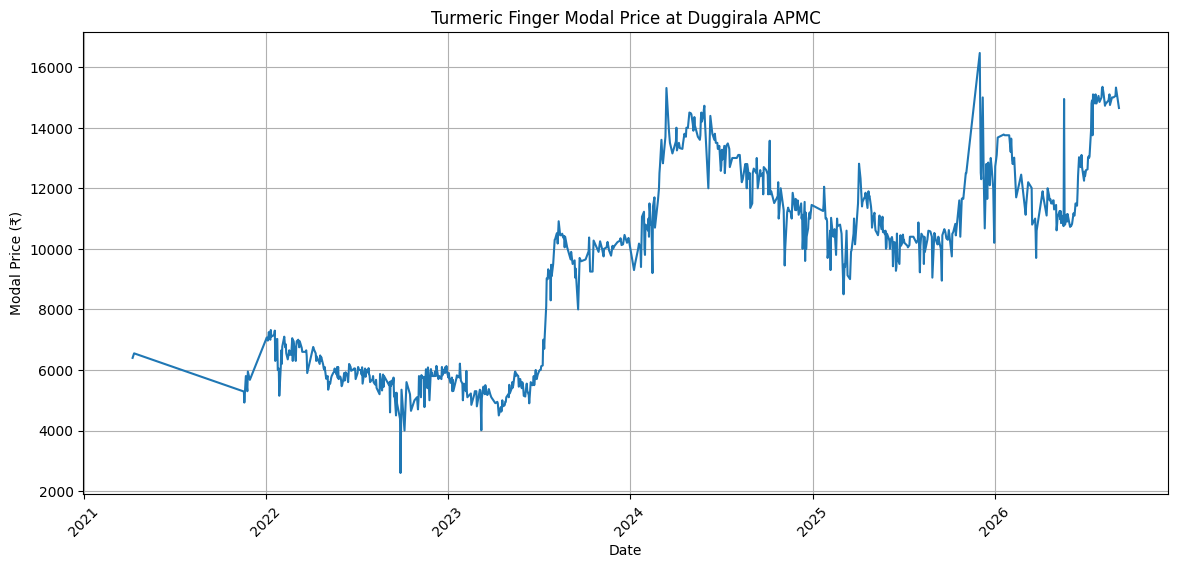

In [56]:
plt.figure(figsize=(14, 6))

plt.plot(
    finger_df["Arrival_Date"],
    finger_df["Modal_Price"]
)

plt.title("Turmeric Finger Modal Price at Duggirala APMC")
plt.xlabel("Date")
plt.ylabel("Modal Price (₹)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

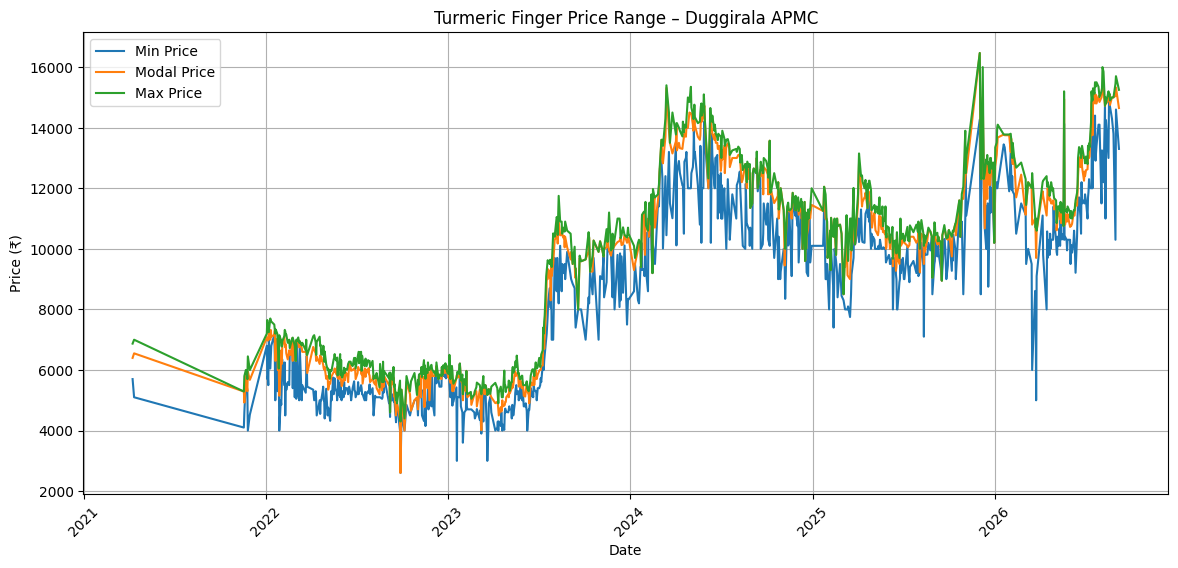

In [57]:
plt.figure(figsize=(14, 6))

plt.plot(
    finger_df["Arrival_Date"],
    finger_df["Min_Price"],
    label="Min Price"
)

plt.plot(
    finger_df["Arrival_Date"],
    finger_df["Modal_Price"],
    label="Modal Price"
)

plt.plot(
    finger_df["Arrival_Date"],
    finger_df["Max_Price"],
    label="Max Price"
)

plt.title("Turmeric Finger Price Range – Duggirala APMC")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

In [58]:
finger_df.groupby("Grade")["Modal_Price"].describe()

,count,mean,std,min,25%,50%,75%,max
Grade,,,,,,,,
FAQ,662.0,8753.581571,2968.677044,2600.0,5800.0,9487.5,11000.0,15311.00000
Local,124.0,12622.118186,1546.756857,9700.0,11250.0,12480.5,13750.0,16466.66255


In [59]:
finger_df.groupby("Grade")["Modal_Price"].mean()

,Modal_Price
Grade,
FAQ,8753.581571
Local,12622.118186


In [60]:
finger_df[["Min_Price", "Max_Price", "Modal_Price"]].corr()

,Min_Price,Max_Price,Modal_Price
Min_Price,1.000000,0.960292,0.967023
Max_Price,0.960292,1.000000,0.994840
Modal_Price,0.967023,0.994840,1.000000


In [61]:
finger_df["Price_Range"] = (
    finger_df["Max_Price"] - finger_df["Min_Price"]
)

finger_df["Price_Range"].describe()

,Price_Range
count,786.000000
mean,1237.512721
std,879.507461
min,0.000000
25%,652.750000
50%,1100.000000
75%,1657.500000
max,6500.000000


In [62]:
finger_df["Year"] = finger_df["Arrival_Date"].dt.year
finger_df["Month"] = finger_df["Arrival_Date"].dt.month

In [63]:
yearly_price = (
    finger_df
    .groupby("Year")["Modal_Price"]
    .mean()
)

yearly_price

,Modal_Price
Year,
2021,5723.444444
2022,5960.820652
2023,7045.289941
2024,12326.821656
2025,10817.947540
2026,12645.305521


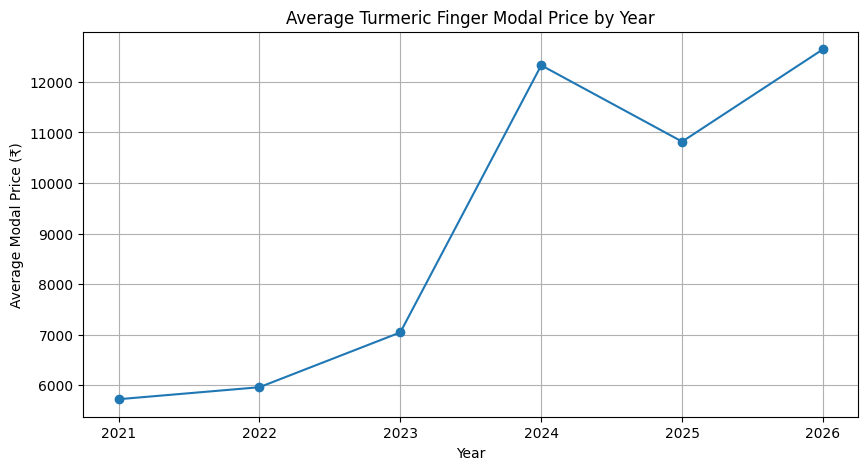

In [64]:
plt.figure(figsize=(10, 5))

plt.plot(
    yearly_price.index,
    yearly_price.values,
    marker="o"
)

plt.title("Average Turmeric Finger Modal Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Modal Price (₹)")
plt.grid(True)

plt.show()

In [65]:
monthly_price = (
    finger_df
    .groupby("Month")["Modal_Price"]
    .mean()
)

monthly_price

,Modal_Price
Month,
1,8360.915254
2,8955.158730
3,8779.192982
4,9544.184211
5,9254.715750
6,9098.152941
7,9855.846154
8,10823.588235
9,9204.641509


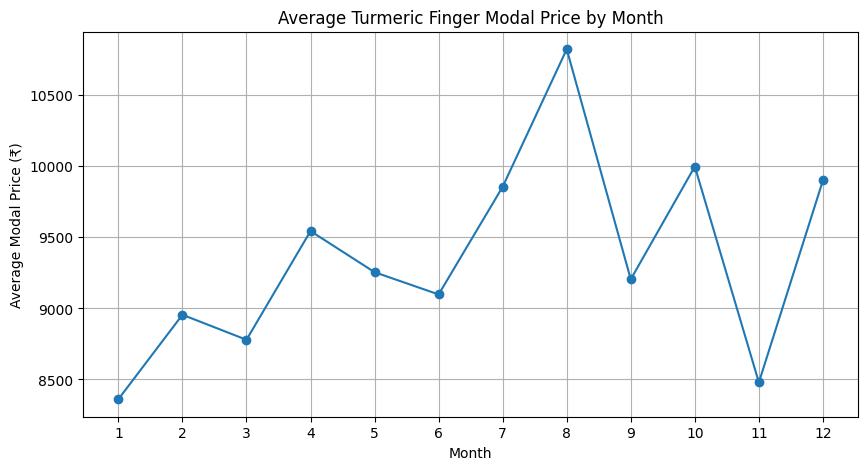

In [66]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_price.index,
    monthly_price.values,
    marker="o"
)

plt.title("Average Turmeric Finger Modal Price by Month")
plt.xlabel("Month")
plt.ylabel("Average Modal Price (₹)")
plt.xticks(range(1, 13))
plt.grid(True)

plt.show()

In [67]:
finger_df["Year"].value_counts().sort_index()

,count
Year,
2021,9
2022,184
2023,169
2024,157
2025,159
2026,108


In [68]:
monthly_count = finger_df.groupby("Month").size()
monthly_count

,0
Month,
1,59
2,63
3,57
4,76
5,95
6,85
7,78
8,68
9,53


In [69]:
grade_year = pd.crosstab(
    finger_df["Year"],
    finger_df["Grade"]
)

grade_year

Grade,FAQ,Local
Year,,
2021,9,0
2022,184,0
2023,169,0
2024,157,0
2025,142,17
2026,1,107


In [70]:
year_grade_price = (
    finger_df
    .groupby(["Year", "Grade"])["Modal_Price"]
    .mean()
)

year_grade_price

Year  Grade
2021  FAQ       5723.444444
2022  FAQ       5960.820652
2023  FAQ       7045.289941
2024  FAQ      12326.821656
2025  FAQ      10602.140845
      Local    12620.568165
2026  FAQ      15100.000000
      Local    12622.364451
Name: Modal_Price, dtype: float64

In [71]:
date_counts = finger_df["Arrival_Date"].value_counts()

date_counts.value_counts().sort_index()

,count
count,
1,780
2,3


In [72]:
finger_df["Arrival_Date"].duplicated().sum()

np.int64(3)

In [73]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
1558,False
1559,False
1560,False
1561,False


In [74]:
duplicate_dates = finger_df[
    finger_df["Arrival_Date"].duplicated(keep=False)
].sort_values("Arrival_Date")

duplicate_dates[
    [
        "Arrival_Date",
        "Market",
        "Grade",
        "Variety",
        "Min_Price",
        "Max_Price",
        "Modal_Price"
    ]
]

,Arrival_Date,Market,Grade,Variety,Min_Price,Max_Price,Modal_Price
655,2025-11-03,Duggirala APMC,FAQ,Finger,11000.0,13900.0,12360.0
656,2025-11-03,Duggirala APMC,FAQ,Finger,11000.0,13900.0,12360.0
657,2025-11-04,Duggirala APMC,FAQ,Finger,12500.0,12500.0,12500.0
658,2025-11-04,Duggirala APMC,FAQ,Finger,12500.0,12500.0,12500.0
659,2025-11-05,Duggirala APMC,FAQ,Finger,11100.0,13000.0,12500.0
660,2025-11-05,Duggirala APMC,FAQ,Finger,11100.0,13000.0,12500.0


In [75]:
print("Duplicate rows before removal:", finger_df.duplicated().sum())

Duplicate rows before removal: 3


In [76]:
finger_df = finger_df.drop_duplicates().copy()

In [77]:
print("Rows after removing duplicates:", len(finger_df))

Rows after removing duplicates: 783


In [78]:
print("Duplicate rows remaining:", finger_df.duplicated().sum())

Duplicate rows remaining: 0


In [79]:
print("Duplicate dates remaining:", finger_df["Arrival_Date"].duplicated().sum())

Duplicate dates remaining: 0


In [80]:
print("Rows:", len(finger_df))
print("Unique dates:", finger_df["Arrival_Date"].nunique())
print("Duplicate rows:", finger_df.duplicated().sum())
print("Duplicate dates:", finger_df["Arrival_Date"].duplicated().sum())

Rows: 783
Unique dates: 783
Duplicate rows: 0
Duplicate dates: 0


Step 4: Feature Engineering 🚀

In [81]:
model_df = finger_df.copy()

In [82]:
model_df = model_df.sort_values("Arrival_Date").reset_index(drop=True)

In [83]:
model_df[["Arrival_Date", "Modal_Price"]].head(10)

,Arrival_Date,Modal_Price
0,2021-04-09,6400.0
1,2021-04-12,6550.0
2,2021-11-18,5290.0
3,2021-11-19,4925.0
4,2021-11-22,5800.0
5,2021-11-23,5621.0
6,2021-11-25,5300.0
7,2021-11-26,5950.0
8,2021-11-30,5675.0
9,2022-01-03,7075.0


In [84]:
model_df["Target_Modal_Price"] = model_df["Modal_Price"].shift(-1)

In [85]:
model_df[["Arrival_Date", "Modal_Price", "Target_Modal_Price"]].head(10)

,Arrival_Date,Modal_Price,Target_Modal_Price
0,2021-04-09,6400.0,6550.0
1,2021-04-12,6550.0,5290.0
2,2021-11-18,5290.0,4925.0
3,2021-11-19,4925.0,5800.0
4,2021-11-22,5800.0,5621.0
5,2021-11-23,5621.0,5300.0
6,2021-11-25,5300.0,5950.0
7,2021-11-26,5950.0,5675.0
8,2021-11-30,5675.0,7075.0
9,2022-01-03,7075.0,7011.0


Lag-1

In [86]:
model_df["Lag_1"] = model_df["Modal_Price"].shift(1)

Lag-2

In [87]:
model_df["Lag_2"] = model_df["Modal_Price"].shift(2)

Lag-3

In [88]:
model_df["Lag_3"] = model_df["Modal_Price"].shift(3)

In [89]:
model_df["Min_Price_Lag_1"] = model_df["Min_Price"].shift(1)

model_df["Max_Price_Lag_1"] = model_df["Max_Price"].shift(1)

In [90]:
finger_df["Price_Range"]

,Price_Range
0,1171.0
1,1900.0
2,1190.0
3,1200.0
4,351.0
...,...
781,700.0
782,1200.0
783,5150.0
784,1100.0


In [91]:
model_df["Price_Range"] = (
    model_df["Max_Price"] - model_df["Min_Price"]
)

In [92]:
model_df["Price_Range_Lag_1"] = (
    model_df["Price_Range"].shift(1)
)

In [93]:
model_df["Rolling_Mean_7"] = (
    model_df["Modal_Price"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

In [94]:
model_df["Rolling_Mean_14"] = (
    model_df["Modal_Price"]
    .shift(1)
    .rolling(window=14)
    .mean()
)

In [95]:
model_df["Rolling_Mean_30"] = (
    model_df["Modal_Price"]
    .shift(1)
    .rolling(window=30)
    .mean()
)

In [96]:
model_df["Rolling_Std_7"] = (
    model_df["Modal_Price"]
    .shift(1)
    .rolling(window=7)
    .std()
)

In [97]:
model_df["Month"] = model_df["Arrival_Date"].dt.month

In [98]:
model_df.head(35)

,Arrival_Date,Commodity,Commodity_Code,District,Grade,Market,Max_Price,Min_Price,Modal_Price,State,...,Lag_1,Lag_2,Lag_3,Min_Price_Lag_1,Max_Price_Lag_1,Price_Range_Lag_1,Rolling_Mean_7,Rolling_Mean_14,Rolling_Mean_30,Rolling_Std_7
0,2021-04-09,Turmeric,39,Guntur,FAQ,Duggirala APMC,6871.0,5700.0,6400.0,Andhra Pradesh,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-04-12,Turmeric,39,Guntur,FAQ,Duggirala APMC,7000.0,5100.0,6550.0,Andhra Pradesh,...,6400.0,NaN,NaN,5700.0,6871.0,1171.0,NaN,NaN,NaN,NaN
2,2021-11-18,Turmeric,39,Guntur,FAQ,Duggirala APMC,5290.0,4100.0,5290.0,Andhra Pradesh,...,6550.0,6400.0,NaN,5100.0,7000.0,1900.0,NaN,NaN,NaN,NaN
3,2021-11-19,Turmeric,39,Guntur,FAQ,Duggirala APMC,5800.0,4600.0,4925.0,Andhra Pradesh,...,5290.0,6550.0,6400.0,4100.0,5290.0,1190.0,NaN,NaN,NaN,NaN
4,2021-11-22,Turmeric,39,Guntur,FAQ,Duggirala APMC,6001.0,5650.0,5800.0,Andhra Pradesh,...,4925.0,5290.0,6550.0,4600.0,5800.0,1200.0,NaN,NaN,NaN,NaN
5,2021-11-23,Turmeric,39,Guntur,FAQ,Duggirala APMC,6000.0,5590.0,5621.0,Andhra Pradesh,...,5800.0,4925.0,5290.0,5650.0,6001.0,351.0,NaN,NaN,NaN,NaN
6,2021-11-25,Turmeric,39,Guntur,FAQ,Duggirala APMC,5700.0,5300.0,5300.0,Andhra Pradesh,...,5621.0,5800.0,4925.0,5590.0,6000.0,410.0,NaN,NaN,NaN,NaN
7,2021-11-26,Turmeric,39,Guntur,FAQ,Duggirala APMC,6450.0,4000.0,5950.0,Andhra Pradesh,...,5300.0,5621.0,5800.0,5300.0,5700.0,400.0,5698.000000,NaN,NaN,599.644061
8,2021-11-30,Turmeric,39,Guntur,FAQ,Duggirala APMC,6000.0,4525.0,5675.0,Andhra Pradesh,...,5950.0,5300.0,5621.0,4000.0,6450.0,2450.0,5633.714286,NaN,NaN,532.166864
9,2022-01-03,Turmeric,39,Guntur,FAQ,Duggirala APMC,7200.0,6800.0,7075.0,Andhra Pradesh,...,5675.0,5950.0,5300.0,4525.0,6000.0,1475.0,5508.714286,NaN,NaN,354.014931


In [99]:
model_df.columns

Index(['Arrival_Date', 'Commodity', 'Commodity_Code', 'District', 'Grade',
       'Market', 'Max_Price', 'Min_Price', 'Modal_Price', 'State', 'Variety',
       'Price_Range', 'Year', 'Month', 'Target_Modal_Price', 'Lag_1', 'Lag_2',
       'Lag_3', 'Min_Price_Lag_1', 'Max_Price_Lag_1', 'Price_Range_Lag_1',
       'Rolling_Mean_7', 'Rolling_Mean_14', 'Rolling_Mean_30',
       'Rolling_Std_7'],
      dtype='object')

In [100]:
model_df.isnull().sum()

,0
Arrival_Date,0
Commodity,0
Commodity_Code,0
District,0
Grade,0
Market,0
Max_Price,0
Min_Price,0
Modal_Price,0
State,0


In [101]:
# Create lag features
model_df["Lag_1"] = model_df["Modal_Price"].shift(1)
model_df["Lag_2"] = model_df["Modal_Price"].shift(2)
model_df["Lag_3"] = model_df["Modal_Price"].shift(3)

# Previous day's Min and Max prices
model_df["Min_Price_Lag_1"] = model_df["Min_Price"].shift(1)
model_df["Max_Price_Lag_1"] = model_df["Max_Price"].shift(1)

# Price range
model_df["Price_Range"] = (
    model_df["Max_Price"] - model_df["Min_Price"]
)

# Previous day's price range
model_df["Price_Range_Lag_1"] = (
    model_df["Price_Range"].shift(1)
)

# Rolling averages using previous observations only
model_df["Rolling_Mean_7"] = (
    model_df["Modal_Price"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

model_df["Rolling_Mean_14"] = (
    model_df["Modal_Price"]
    .shift(1)
    .rolling(window=14)
    .mean()
)

model_df["Rolling_Mean_30"] = (
    model_df["Modal_Price"]
    .shift(1)
    .rolling(window=30)
    .mean()
)

# Recent price volatility
model_df["Rolling_Std_7"] = (
    model_df["Modal_Price"]
    .shift(1)
    .rolling(window=7)
    .std()
)

# Calendar features
model_df["Year"] = model_df["Arrival_Date"].dt.year
model_df["Month"] = model_df["Arrival_Date"].dt.month

# Target: next available trading/market observation's modal price
model_df["Target_Modal_Price"] = (
    model_df["Modal_Price"].shift(-1)
)

In [102]:
model_df[
    [
        "Arrival_Date",
        "Modal_Price",
        "Target_Modal_Price",
        "Lag_1",
        "Lag_2",
        "Lag_3",
        "Rolling_Mean_7",
        "Rolling_Mean_14",
        "Rolling_Mean_30",
        "Rolling_Std_7"
    ]
].head(35)

,Arrival_Date,Modal_Price,Target_Modal_Price,Lag_1,Lag_2,Lag_3,Rolling_Mean_7,Rolling_Mean_14,Rolling_Mean_30,Rolling_Std_7
0,2021-04-09,6400.0,6550.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-04-12,6550.0,5290.0,6400.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-11-18,5290.0,4925.0,6550.0,6400.0,NaN,NaN,NaN,NaN,NaN
3,2021-11-19,4925.0,5800.0,5290.0,6550.0,6400.0,NaN,NaN,NaN,NaN
4,2021-11-22,5800.0,5621.0,4925.0,5290.0,6550.0,NaN,NaN,NaN,NaN
5,2021-11-23,5621.0,5300.0,5800.0,4925.0,5290.0,NaN,NaN,NaN,NaN
6,2021-11-25,5300.0,5950.0,5621.0,5800.0,4925.0,NaN,NaN,NaN,NaN
7,2021-11-26,5950.0,5675.0,5300.0,5621.0,5800.0,5698.000000,NaN,NaN,599.644061
8,2021-11-30,5675.0,7075.0,5950.0,5300.0,5621.0,5633.714286,NaN,NaN,532.166864
9,2022-01-03,7075.0,7011.0,5675.0,5950.0,5300.0,5508.714286,NaN,NaN,354.014931


In [103]:
model_df.isnull().sum()

,0
Arrival_Date,0
Commodity,0
Commodity_Code,0
District,0
Grade,0
Market,0
Max_Price,0
Min_Price,0
Modal_Price,0
State,0


In [104]:
ml_df = model_df.copy()

In [105]:
ml_df = ml_df.dropna().copy()

In [106]:
print("Rows:", len(ml_df))
print("Columns:", len(ml_df.columns))

Rows: 752
Columns: 25


In [107]:
ml_df.isnull().sum()

,0
Arrival_Date,0
Commodity,0
Commodity_Code,0
District,0
Grade,0
Market,0
Max_Price,0
Min_Price,0
Modal_Price,0
State,0


In [108]:
ml_df[
    [
        "Arrival_Date",
        "Modal_Price",
        "Lag_1",
        "Lag_2",
        "Lag_3",
        "Rolling_Mean_7",
        "Rolling_Mean_14",
        "Rolling_Mean_30",
        "Rolling_Std_7",
        "Target_Modal_Price"
    ]
].head()

,Arrival_Date,Modal_Price,Lag_1,Lag_2,Lag_3,Rolling_Mean_7,Rolling_Mean_14,Rolling_Mean_30,Rolling_Std_7,Target_Modal_Price
30,2022-02-08,6900.0,7100.0,6775.0,6200.0,6289.285714,6565.071429,6436.633333,635.389832,6750.0
31,2022-02-09,6750.0,6900.0,7100.0,6775.0,6410.714286,6550.785714,6453.300000,662.674056,6850.0
32,2022-02-10,6850.0,6750.0,6900.0,7100.0,6639.285714,6521.428571,6459.966667,363.964611,6550.0
33,2022-02-11,6550.0,6850.0,6750.0,6900.0,6746.428571,6489.285714,6511.966667,279.295457,6350.0
34,2022-02-14,6350.0,6550.0,6850.0,6750.0,6732.142857,6507.142857,6566.133333,287.487060,6650.0


In [109]:
ml_df[
    [
        "Arrival_Date",
        "Modal_Price",
        "Lag_1",
        "Rolling_Mean_7",
        "Rolling_Mean_30",
        "Target_Modal_Price"
    ]
].tail()

,Arrival_Date,Modal_Price,Lag_1,Rolling_Mean_7,Rolling_Mean_30,Target_Modal_Price
777,2026-08-20,14750.0,15100.0,14928.714286,14224.233333,15000.0
778,2026-08-24,15000.0,14750.0,14871.428571,14307.566667,15000.0
779,2026-08-27,15000.0,15000.0,14910.714286,14389.233333,15050.0
780,2026-08-31,15050.0,15000.0,14935.714286,14475.900000,15325.0
781,2026-09-01,15325.0,15050.0,14971.428571,14557.566667,14650.0


Step 5 — Train/Test Split for Time Series

In [110]:
print("ML data start:", ml_df["Arrival_Date"].min())
print("ML data end:", ml_df["Arrival_Date"].max())

ML data start: 2022-02-08 00:00:00
ML data end: 2026-09-01 00:00:00


In [111]:
ml_df["Year"].value_counts().sort_index()

,count
Year,
2022,163
2023,169
2024,157
2025,156
2026,107


In [112]:
features = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Min_Price_Lag_1",
    "Max_Price_Lag_1",
    "Price_Range_Lag_1",
    "Rolling_Mean_7",
    "Rolling_Mean_14",
    "Rolling_Mean_30",
    "Rolling_Std_7",
    "Month"
]

In [113]:
target = "Target_Modal_Price"

In [114]:
features = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Min_Price_Lag_1",
    "Max_Price_Lag_1",
    "Price_Range_Lag_1",
    "Rolling_Mean_7",
    "Rolling_Mean_14",
    "Rolling_Mean_30",
    "Rolling_Std_7",
    "Month"
]

target = "Target_Modal_Price"

In [115]:
X = ml_df[features]
y = ml_df[target]

In [116]:
train_mask = ml_df["Arrival_Date"] < "2026-01-01"

X_train = X[train_mask]
X_test = X[~train_mask]

y_train = y[train_mask]
y_test = y[~train_mask]

In [117]:
print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 645
Testing observations: 107


In [118]:
print("Training start:", ml_df.loc[train_mask, "Arrival_Date"].min())
print("Training end:", ml_df.loc[train_mask, "Arrival_Date"].max())

print("Testing start:", ml_df.loc[~train_mask, "Arrival_Date"].min())
print("Testing end:", ml_df.loc[~train_mask, "Arrival_Date"].max())

Training start: 2022-02-08 00:00:00
Training end: 2025-12-31 00:00:00
Testing start: 2026-01-02 00:00:00
Testing end: 2026-09-01 00:00:00


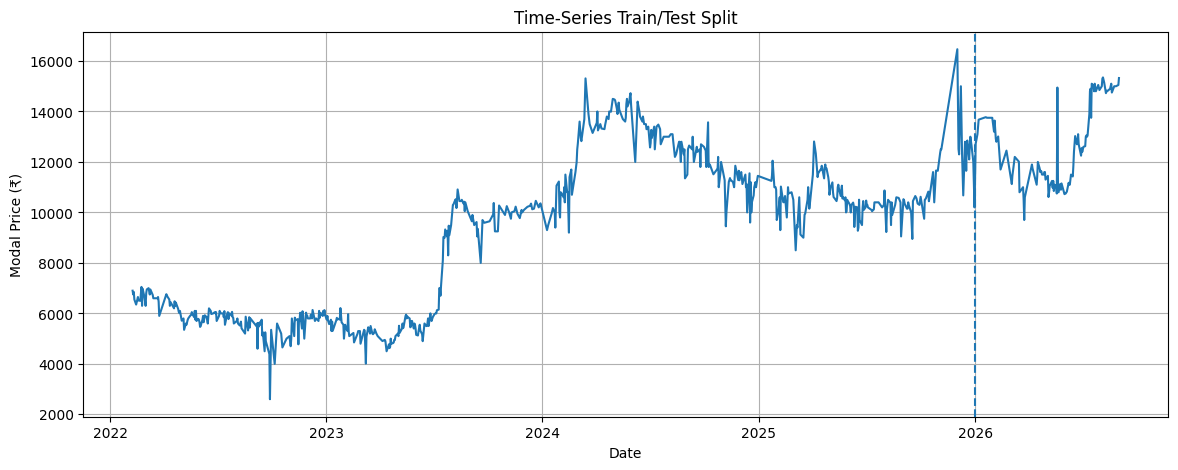

In [119]:
plt.figure(figsize=(14, 5))

plt.plot(
    ml_df["Arrival_Date"],
    ml_df["Modal_Price"]
)

plt.axvline(
    pd.Timestamp("2026-01-01"),
    linestyle="--"
)

plt.title("Time-Series Train/Test Split")
plt.xlabel("Date")
plt.ylabel("Modal Price (₹)")
plt.grid(True)

plt.show()

Step 6 — Build our first baseline model

In [120]:
# Naive baseline prediction
baseline_pred = X_test["Lag_1"]

In [121]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline_mae = mean_absolute_error(y_test, baseline_pred)

baseline_rmse = np.sqrt(
    mean_squared_error(y_test, baseline_pred)
)

baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²:", baseline_r2)

Baseline MAE: 496.61675257943926
Baseline RMSE: 839.399094503062
Baseline R²: 0.718872639416586


In [122]:
print(f"Baseline MAE:  ₹{baseline_mae:,.2f}")
print(f"Baseline RMSE: ₹{baseline_rmse:,.2f}")
print(f"Baseline R²:   {baseline_r2:.4f}")

Baseline MAE:  ₹496.62
Baseline RMSE: ₹839.40
Baseline R²:   0.7189


In [123]:
baseline_results = {
    "Model": "Naive Baseline",
    "MAE": baseline_mae,
    "RMSE": baseline_rmse,
    "R2": baseline_r2
}

baseline_results

{'Model': 'Naive Baseline',
 'MAE': 496.61675257943926,
 'RMSE': np.float64(839.399094503062),
 'R2': 0.718872639416586}

Step 7 — First Machine Learning Model: Linear Regression

In [124]:
from sklearn.linear_model import LinearRegression

In [125]:
lr_model = LinearRegression()

In [126]:
lr_model.fit(X_train, y_train)

LinearRegression()

In [127]:
lr_pred = lr_model.predict(X_test)

In [128]:
lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_pred)
)

lr_r2 = r2_score(y_test, lr_pred)

print(f"Linear Regression MAE:  ₹{lr_mae:,.2f}")
print(f"Linear Regression RMSE: ₹{lr_rmse:,.2f}")
print(f"Linear Regression R²:   {lr_r2:.4f}")

Linear Regression MAE:  ₹514.19
Linear Regression RMSE: ₹774.34
Linear Regression R²:   0.7608


In [129]:
results = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Linear Regression"
    ],
    "MAE": [
        baseline_mae,
        lr_mae
    ],
    "RMSE": [
        baseline_rmse,
        lr_rmse
    ],
    "R2": [
        baseline_r2,
        lr_r2
    ]
})

results

,Model,MAE,RMSE,R2
0,Naive Baseline,496.616753,839.399095,0.718873
1,Linear Regression,514.194670,774.341841,0.760761


In [130]:
results.sort_values("MAE")

,Model,MAE,RMSE,R2
0,Naive Baseline,496.616753,839.399095,0.718873
1,Linear Regression,514.194670,774.341841,0.760761


🚀 Step 8 — Decision Tree Regression

In [131]:
from sklearn.tree import DecisionTreeRegressor

In [132]:
dt_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

In [133]:
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [134]:
dt_pred = dt_model.predict(X_test)

In [135]:
dt_mae = mean_absolute_error(y_test, dt_pred)

dt_rmse = np.sqrt(
    mean_squared_error(y_test, dt_pred)
)

dt_r2 = r2_score(y_test, dt_pred)

print(f"Decision Tree MAE:  ₹{dt_mae:,.2f}")
print(f"Decision Tree RMSE: ₹{dt_rmse:,.2f}")
print(f"Decision Tree R²:   {dt_r2:.4f}")

Decision Tree MAE:  ₹962.38
Decision Tree RMSE: ₹1,327.32
Decision Tree R²:   0.2971


In [136]:
results = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Linear Regression",
        "Decision Tree"
    ],
    "MAE": [
        baseline_mae,
        lr_mae,
        dt_mae
    ],
    "RMSE": [
        baseline_rmse,
        lr_rmse,
        dt_rmse
    ],
    "R2": [
        baseline_r2,
        lr_r2,
        dt_r2
    ]
})

results.sort_values("MAE")

,Model,MAE,RMSE,R2
0,Naive Baseline,496.616753,839.399095,0.718873
1,Linear Regression,514.194670,774.341841,0.760761
2,Decision Tree,962.379525,1327.315883,0.297066


🚀 Step 9 — Random Forest

In [137]:
from sklearn.ensemble import RandomForestRegressor

In [138]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

In [139]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, n_jobs=-1,
                      random_state=42)

In [140]:
rf_pred = rf_model.predict(X_test)

In [141]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest MAE:  ₹{rf_mae:,.2f}")
print(f"Random Forest RMSE: ₹{rf_rmse:,.2f}")
print(f"Random Forest R²:   {rf_r2:.4f}")

Random Forest MAE:  ₹873.18
Random Forest RMSE: ₹1,159.94
Random Forest R²:   0.4632


In [142]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,Max_Price_Lag_1,0.585724
0,Lag_1,0.146639
3,Min_Price_Lag_1,0.106344
6,Rolling_Mean_7,0.087134
2,Lag_3,0.036123
1,Lag_2,0.023440
7,Rolling_Mean_14,0.003343
9,Rolling_Std_7,0.003101
8,Rolling_Mean_30,0.002879
5,Price_Range_Lag_1,0.002796


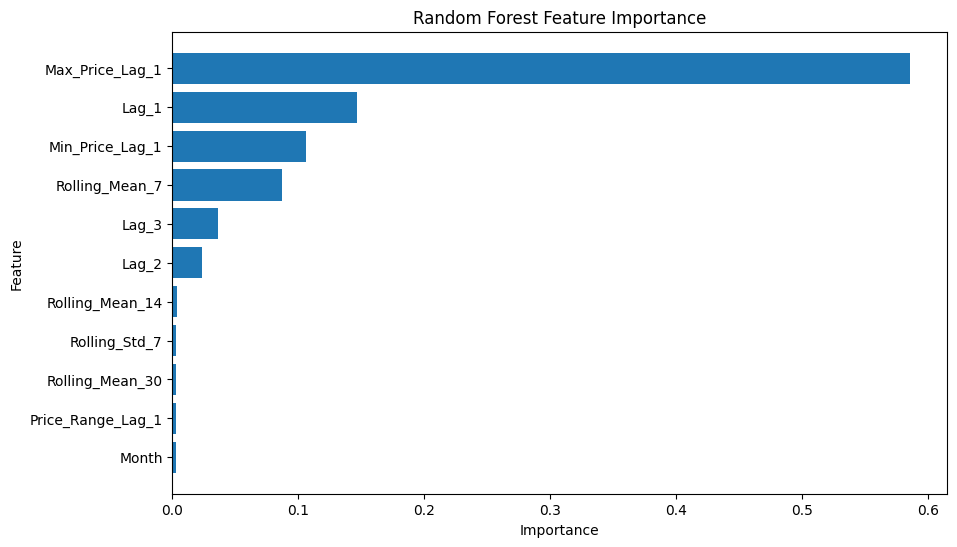

In [143]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.show()

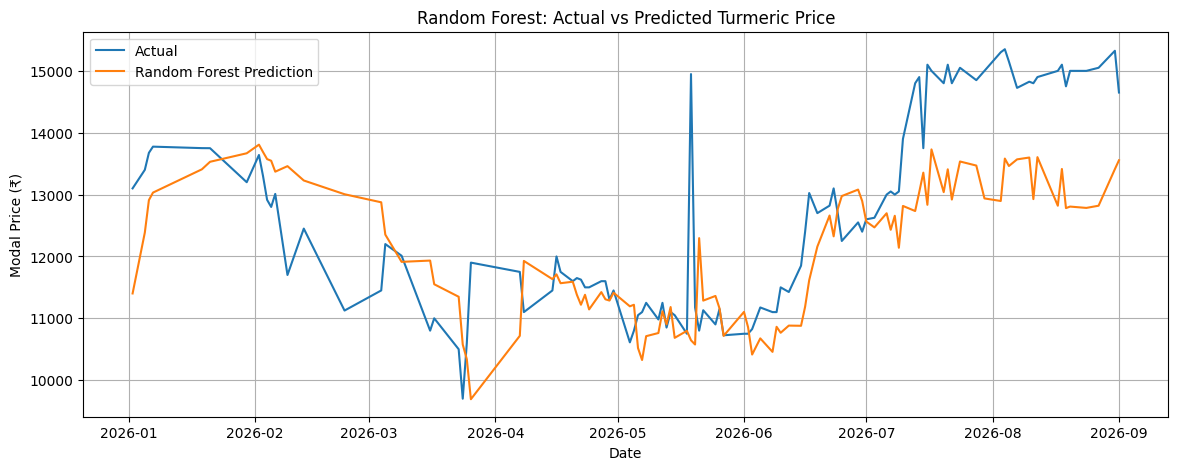

In [144]:
plt.figure(figsize=(14, 5))

plt.plot(
    ml_df.loc[~train_mask, "Arrival_Date"],
    y_test.values,
    label="Actual"
)

plt.plot(
    ml_df.loc[~train_mask, "Arrival_Date"],
    rf_pred,
    label="Random Forest Prediction"
)

plt.title("Random Forest: Actual vs Predicted Turmeric Price")
plt.xlabel("Date")
plt.ylabel("Modal Price (₹)")
plt.legend()
plt.grid(True)

plt.show()

In [145]:
comparison = pd.DataFrame({
    "Date": ml_df.loc[~train_mask, "Arrival_Date"].values,
    "Actual": y_test.values,
    "Baseline": baseline_pred.values,
    "Linear_Regression": lr_pred,
    "Random_Forest": rf_pred
})

comparison.head(15)

,Date,Actual,Baseline,Linear_Regression,Random_Forest
0,2026-01-02,13100.0,10200.0,11525.480403,11401.336010
1,2026-01-05,13400.0,12721.0,11999.342972,12385.366652
2,2026-01-06,13675.0,13100.0,12542.534835,12910.620407
3,2026-01-07,13775.0,13400.0,13365.527414,13032.023775
4,2026-01-19,13751.0,13675.0,13626.847621,13408.440020
5,2026-01-21,13750.0,13775.0,13837.897366,13530.076521
6,2026-01-30,13200.0,13751.0,13918.101017,13667.728655
7,2026-02-02,13640.0,13750.0,13529.788526,13807.094866
8,2026-02-03,13300.0,13200.0,13524.320345,13687.860497
9,2026-02-04,12915.0,13640.0,13293.081266,13573.583644


In [146]:
print("Training target range:")
print("Min:", y_train.min())
print("Max:", y_train.max())

print("\nTesting target range:")
print("Min:", y_test.min())
print("Max:", y_test.max())

print("\nRandom Forest prediction range:")
print("Min:", rf_pred.min())
print("Max:", rf_pred.max())

Training target range:
Min: 2600.0
Max: 16466.66255

Testing target range:
Min: 9700.0
Max: 15350.0

Random Forest prediction range:
Min: 9691.501096700082
Max: 13807.094866442792


In [147]:
rf_train_pred = rf_model.predict(X_train)

rf_train_mae = mean_absolute_error(y_train, rf_train_pred)
rf_train_rmse = np.sqrt(
    mean_squared_error(y_train, rf_train_pred)
)
rf_train_r2 = r2_score(y_train, rf_train_pred)

print(f"Random Forest TRAIN MAE:  ₹{rf_train_mae:,.2f}")
print(f"Random Forest TRAIN RMSE: ₹{rf_train_rmse:,.2f}")
print(f"Random Forest TRAIN R²:   {rf_train_r2:.4f}")

Random Forest TRAIN MAE:  ₹158.89
Random Forest TRAIN RMSE: ₹226.37
Random Forest TRAIN R²:   0.9943


In [148]:
print("Max_Price_Lag_1 - TRAIN")
print(X_train["Max_Price_Lag_1"].describe())

print("\nMax_Price_Lag_1 - TEST")
print(X_test["Max_Price_Lag_1"].describe())

Max_Price_Lag_1 - TRAIN
count      645.000000
mean      9236.658385
std       3019.943723
min       4300.000000
25%       6100.000000
50%      10150.000000
75%      11450.000000
max      16466.662550
Name: Max_Price_Lag_1, dtype: float64

Max_Price_Lag_1 - TEST
count      107.000000
mean     12907.672862
std       1555.077035
min      10200.000000
25%      11475.000000
50%      12825.000000
75%      14055.500000
max      16000.000000
Name: Max_Price_Lag_1, dtype: float64


In [149]:
results = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        lr_mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],
    "R2": [
        baseline_r2,
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

results.sort_values("MAE")

,Model,MAE,RMSE,R2
0,Naive Baseline,496.616753,839.399095,0.718873
1,Linear Regression,514.194670,774.341841,0.760761
3,Random Forest,873.179999,1159.940487,0.463169
2,Decision Tree,962.379525,1327.315883,0.297066


🚀 Step 10 — Gradient Boosting

In [150]:
from sklearn.ensemble import GradientBoostingRegressor

In [151]:
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [152]:
gb_model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=42)

In [153]:
gb_pred = gb_model.predict(X_test)

In [154]:
gb_mae = mean_absolute_error(y_test, gb_pred)

gb_rmse = np.sqrt(
    mean_squared_error(y_test, gb_pred)
)

gb_r2 = r2_score(y_test, gb_pred)

print(f"Gradient Boosting MAE:  ₹{gb_mae:,.2f}")
print(f"Gradient Boosting RMSE: ₹{gb_rmse:,.2f}")
print(f"Gradient Boosting R²:   {gb_r2:.4f}")

Gradient Boosting MAE:  ₹933.56
Gradient Boosting RMSE: ₹1,310.55
Gradient Boosting R²:   0.3147


Step 11 — Model Comparison

In [155]:
results = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        baseline_mae,
        lr_mae,
        dt_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        baseline_rmse,
        lr_rmse,
        dt_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2": [
        baseline_r2,
        lr_r2,
        dt_r2,
        rf_r2,
        gb_r2
    ]
})

results.sort_values("MAE").reset_index(drop=True)

,Model,MAE,RMSE,R2
0,Naive Baseline,496.616753,839.399095,0.718873
1,Linear Regression,514.194670,774.341841,0.760761
2,Random Forest,873.179999,1159.940487,0.463169
3,Gradient Boosting,933.557942,1310.554235,0.314707
4,Decision Tree,962.379525,1327.315883,0.297066


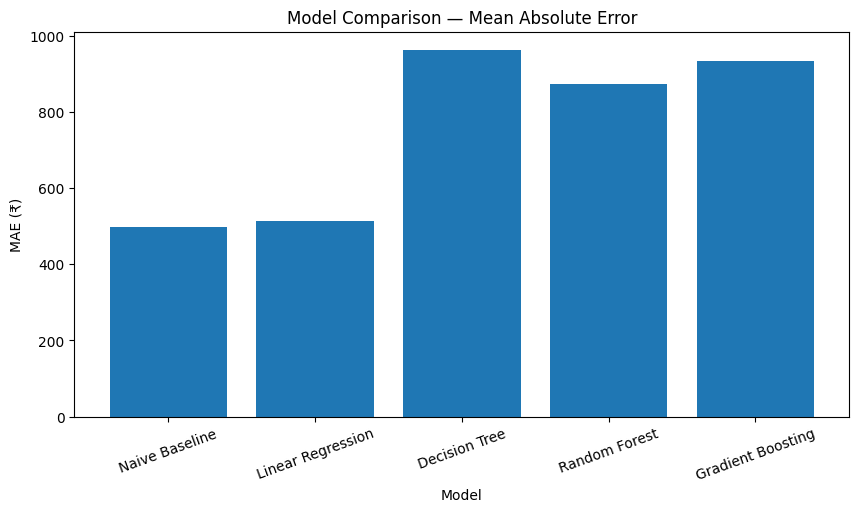

In [156]:
plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["MAE"]
)

plt.ylabel("MAE (₹)")
plt.xlabel("Model")
plt.title("Model Comparison — Mean Absolute Error")
plt.xticks(rotation=20)

plt.show()

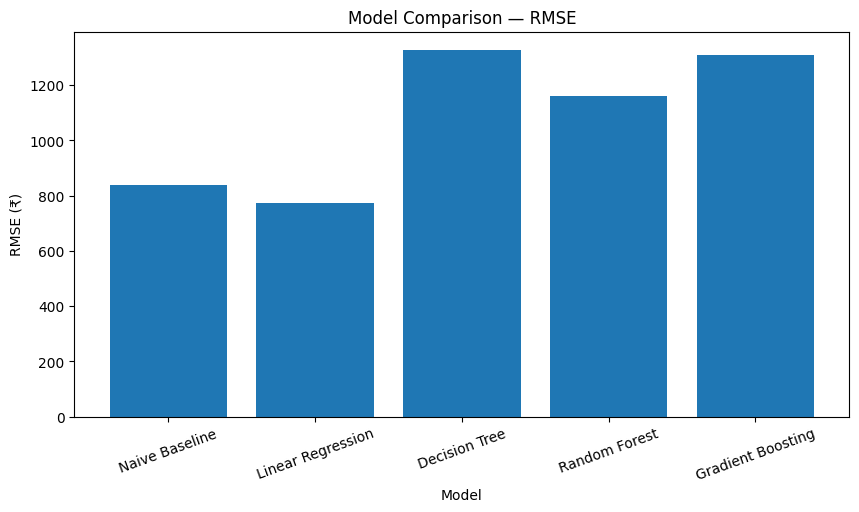

In [157]:
plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.ylabel("RMSE (₹)")
plt.xlabel("Model")
plt.title("Model Comparison — RMSE")
plt.xticks(rotation=20)

plt.show()

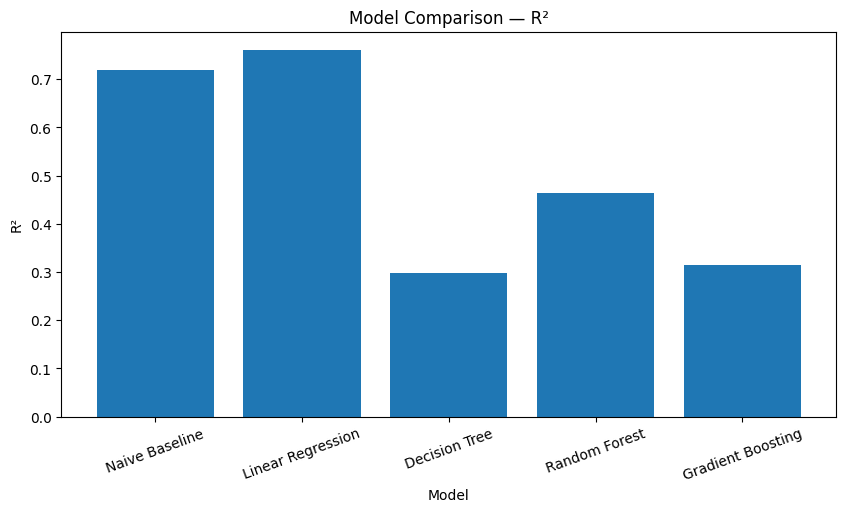

In [158]:
plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["R2"]
)

plt.ylabel("R²")
plt.xlabel("Model")
plt.title("Model Comparison — R²")
plt.xticks(rotation=20)

plt.show()

🚀 Step 12 — Add NCDEX Turmeric Futures Information

In [159]:
finger_df.to_csv(
    "duggirala_turmeric_finger_clean.csv",
    index=False
)

print("Saved successfully.")

Saved successfully.


In [160]:
print(finger_df.shape)
print(finger_df.columns.tolist())

(783, 14)
['Arrival_Date', 'Commodity', 'Commodity_Code', 'District', 'Grade', 'Market', 'Max_Price', 'Min_Price', 'Modal_Price', 'State', 'Variety', 'Price_Range', 'Year', 'Month']


In [161]:
ml_df[
    [
        "Arrival_Date",
        "Modal_Price",
        "Target_Modal_Price",
        "Lag_1",
        "Lag_2",
        "Lag_3"
    ]
].head(10)

,Arrival_Date,Modal_Price,Target_Modal_Price,Lag_1,Lag_2,Lag_3
30,2022-02-08,6900.0,6750.0,7100.0,6775.0,6200.0
31,2022-02-09,6750.0,6850.0,6900.0,7100.0,6775.0
32,2022-02-10,6850.0,6550.0,6750.0,6900.0,7100.0
33,2022-02-11,6550.0,6350.0,6850.0,6750.0,6900.0
34,2022-02-14,6350.0,6650.0,6550.0,6850.0,6750.0
35,2022-02-17,6650.0,6511.0,6350.0,6550.0,6850.0
36,2022-02-18,6511.0,6500.0,6650.0,6350.0,6550.0
37,2022-02-21,6500.0,7050.0,6511.0,6650.0,6350.0
38,2022-02-23,7050.0,6300.0,6500.0,6511.0,6650.0
39,2022-02-24,6300.0,6975.0,7050.0,6500.0,6511.0


In [162]:
date_diff = ml_df["Arrival_Date"].diff().dt.days

date_diff.value_counts().sort_index()

,count
Arrival_Date,
1.0,413
2.0,88
3.0,130
4.0,54
5.0,22
6.0,19
7.0,11
8.0,2
9.0,3


In [163]:
import pandas as pd

ncdex_test = pd.read_csv("Bhavcopy 20_07_2022.csv")

turmeric_test = ncdex_test[
    ncdex_test["Symbol"].eq("TMCFGRNZM")
].copy()

turmeric_test[
    [
        "Symbol",
        "Expiry Date",
        "Closing Price",
        "Quantity Traded Today",
        "Open Interest",
        "LastTradedDate"
    ]
]

,Symbol,Expiry Date,Closing Price,Quantity Traded Today,Open Interest,LastTradedDate
91,TMCFGRNZM,7/20/2022,7512.0,10.0,5.0,7/20/2022
92,TMCFGRNZM,8/17/2022,7818.0,1620.0,16190.0,7/20/2022
93,TMCFGRNZM,9/20/2022,7902.0,50.0,45.0,7/20/2022
94,TMCFGRNZM,10/20/2022,7986.0,0.0,0.0,NOTRADE
95,TMCFGRNZM,11/18/2022,8070.0,0.0,0.0,NOTRADE


In [164]:
turmeric_test[
    (turmeric_test["Quantity Traded Today"] > 0) &
    (turmeric_test["Open Interest"] > 0)
][
    [
        "Expiry Date",
        "Closing Price",
        "Quantity Traded Today",
        "Open Interest"
    ]
]

,Expiry Date,Closing Price,Quantity Traded Today,Open Interest
91,7/20/2022,7512.0,10.0,5.0
92,8/17/2022,7818.0,1620.0,16190.0
93,9/20/2022,7902.0,50.0,45.0


In [165]:
turmeric_test["Expiry Date"] = pd.to_datetime(turmeric_test["Expiry Date"])
turmeric_test["LastTradedDate"] = pd.to_datetime(
    turmeric_test["LastTradedDate"],
    errors="coerce"
)

trade_date = pd.Timestamp("2022-07-20")

selected = turmeric_test[
    (turmeric_test["Expiry Date"] > trade_date) &
    (turmeric_test["Quantity Traded Today"] > 0) &
    (turmeric_test["Open Interest"] > 0)
].sort_values("Expiry Date").iloc[0]

selected

,92
Symbol,TMCFGRNZM
Expiry Date,2022-08-17 00:00:00
Commodity,TURMERIC
Ex-Basis Delivery Centre,NIZAMABAD
Price Unit,RS/QUINTAL
Previous Closing Price,7716.0
Opening Price,7744.0
High Price,7870.0
Low Price,7744.0
Closing Price,7818.0


In [166]:
turmeric_test["Expiry Date"] > trade_date

,Expiry Date
91,False
92,True
93,True
94,True
95,True


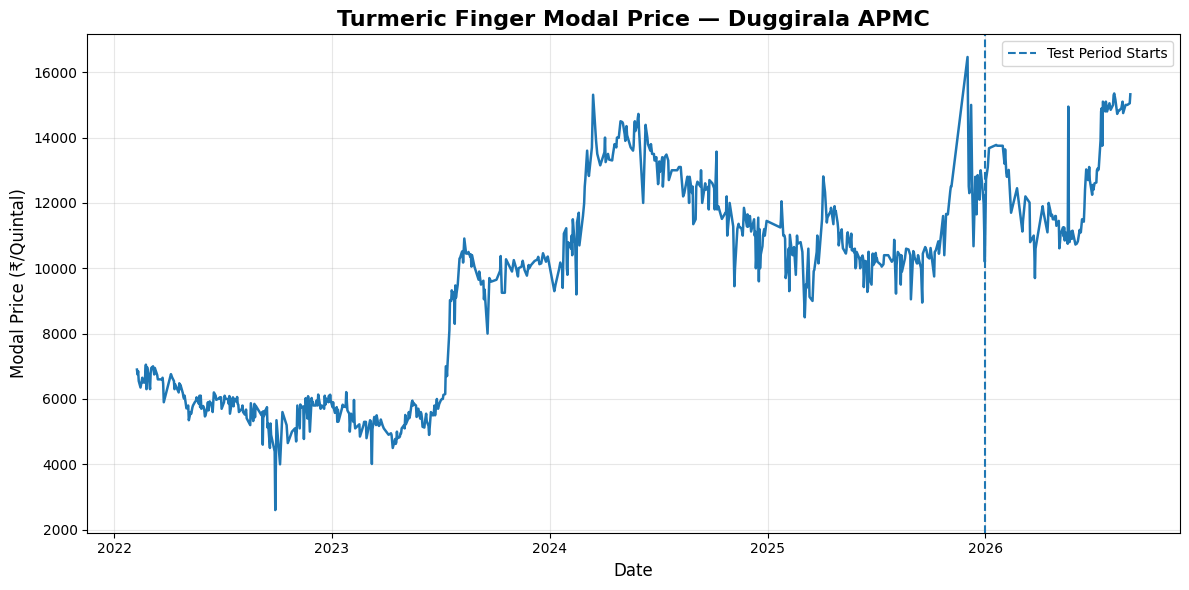

In [167]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    ml_df["Arrival_Date"],
    ml_df["Modal_Price"],
    linewidth=1.8
)

plt.axvline(
    pd.Timestamp("2026-01-01"),
    linestyle="--",
    linewidth=1.5,
    label="Test Period Starts"
)

plt.title(
    "Turmeric Finger Modal Price — Duggirala APMC",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date", fontsize=12)
plt.ylabel("Modal Price (₹/Quintal)", fontsize=12)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    "turmeric_price_trend_linkedin.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

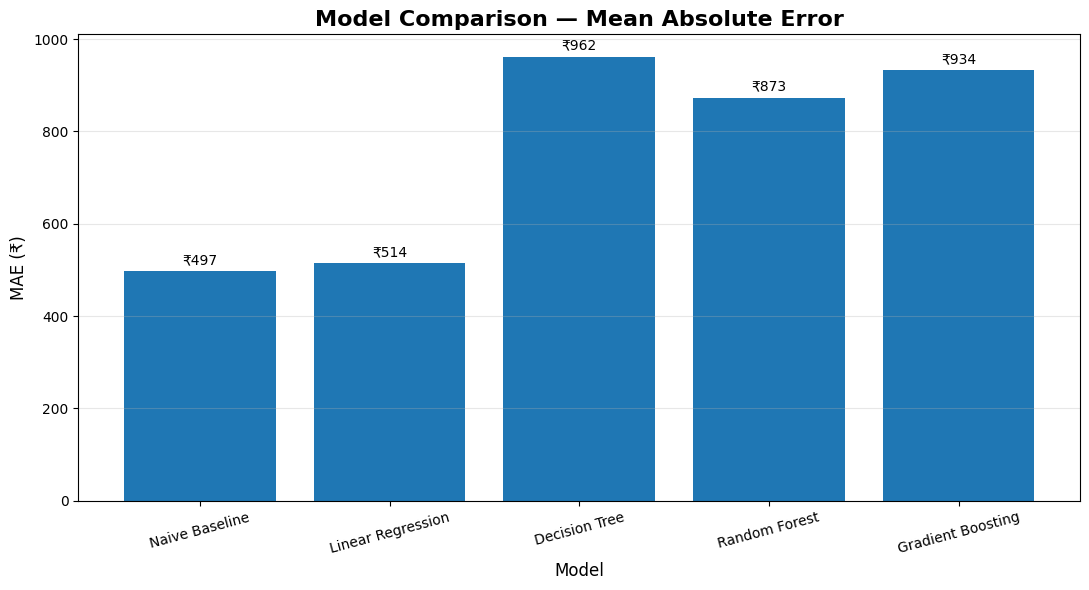

In [168]:
import matplotlib.pyplot as plt

models = [
    "Naive Baseline",
    "Linear Regression",
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting"
]

mae_values = [
    496.62,
    514.19,
    962.38,
    873.18,
    933.56
]

plt.figure(figsize=(11, 6))

bars = plt.bar(models, mae_values)

plt.title(
    "Model Comparison — Mean Absolute Error",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Model", fontsize=12)
plt.ylabel("MAE (₹)", fontsize=12)

plt.xticks(rotation=15)

# Add values above bars
for bar, value in zip(bars, mae_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        f"₹{value:.0f}",
        ha="center",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "model_comparison_mae_linkedin.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

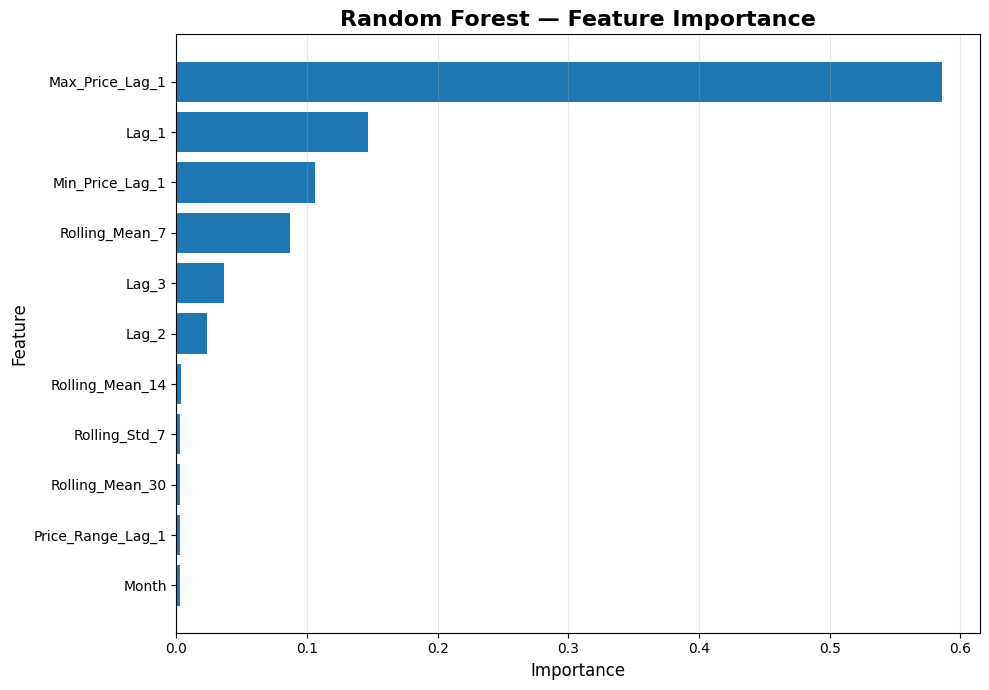

In [169]:
import matplotlib.pyplot as plt
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.title(
    "Random Forest — Feature Importance",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "random_forest_feature_importance_linkedin.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [170]:
import pandas as pd

# Load the 05-Jul-2024 NCDEX file
ncdex_2024 = pd.read_csv("Bhavcopy 05_07_2024.csv")

# Convert date columns
ncdex_2024["Expiry Date"] = pd.to_datetime(
    ncdex_2024["Expiry Date"],
    errors="coerce"
)

ncdex_2024["LastTradedDate"] = pd.to_datetime(
    ncdex_2024["LastTradedDate"],
    errors="coerce"
)

# Keep only Turmeric
turmeric_2024 = ncdex_2024[
    ncdex_2024["Symbol"].eq("TMCFGRNZM")
].copy()

# Display Turmeric contracts
turmeric_2024[
    [
        "Symbol",
        "Expiry Date",
        "Closing Price",
        "Quantity Traded Today",
        "Open Interest",
        "LastTradedDate"
    ]
]

/tmp/ipykernel_3522/2107989318.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ncdex_2024["LastTradedDate"] = pd.to_datetime(


,Symbol,Expiry Date,Closing Price,Quantity Traded Today,Open Interest,LastTradedDate
89,TMCFGRNZM,2024-08-20,15856.0,2625,20155,2024-07-05
90,TMCFGRNZM,2024-10-18,16630.0,775,4470,2024-07-05
91,TMCFGRNZM,2024-12-20,17980.0,5,15,2024-07-05


In [171]:
trade_date = pd.Timestamp("2024-07-05")

eligible_contracts = turmeric_2024[
    (turmeric_2024["Expiry Date"] > trade_date) &
    (turmeric_2024["Quantity Traded Today"] > 0) &
    (turmeric_2024["Open Interest"] > 0)
].sort_values("Expiry Date")

eligible_contracts[
    [
        "Symbol",
        "Expiry Date",
        "Closing Price",
        "Quantity Traded Today",
        "Open Interest"
    ]
]

,Symbol,Expiry Date,Closing Price,Quantity Traded Today,Open Interest
89,TMCFGRNZM,2024-08-20,15856.0,2625,20155
90,TMCFGRNZM,2024-10-18,16630.0,775,4470
91,TMCFGRNZM,2024-12-20,17980.0,5,15


In [172]:
selected_2024 = eligible_contracts.iloc[0]

selected_2024

,89
Symbol,TMCFGRNZM
Expiry Date,2024-08-20 00:00:00
Commodity,TURMERIC
Ex-Basis Delivery Centre,NIZAMABAD
Price Unit,RS/QUINTAL
Previous Closing Price,16158.0
Opening Price,16102.0
High Price,16206.0
Low Price,15756.0
Closing Price,15856.0


In [173]:
import requests

url = "https://www.ncdex.com/markets/bhavcopy"

response = requests.get(url)

print("Status code:", response.status_code)
print("Page size:", len(response.text))

Status code: 200
Page size: 292799


In [174]:
# Look for links related to Bhav Copy downloads
from bs4 import BeautifulSoup

soup = BeautifulSoup(response.text, "html.parser")

links = []

for a in soup.find_all("a", href=True):
    href = a["href"]
    text = a.get_text(" ", strip=True)

    if any(word in (text + " " + href).lower()
           for word in ["bhav", "csv", "download", "historical"]):
        links.append((text, href))

for text, href in links:
    print("TEXT:", text)
    print("URL :", href)
    print("-" * 80)

TEXT: Downloads
URL : https://www.ncdex.com/quick_links/download
--------------------------------------------------------------------------------
TEXT: Bhav Copy
URL : https://www.ncdex.com/markets/bhavcopy
--------------------------------------------------------------------------------
TEXT: Reports on Historical Data
URL : https://www.ncdex.com/market-data/reports_on_historical_data
--------------------------------------------------------------------------------
TEXT: Bhav Copy
URL : https://www.ncdex.com/markets/bhavcopy
--------------------------------------------------------------------------------
TEXT: Addition/Change in Authorised Signatories
URL : https://www.ncdex.com/downloads/Member-area/Auhtorised_signatories/Procedure_for_Authorised_signatory_22082019.pdf
--------------------------------------------------------------------------------
TEXT: Format of UDiFF Report downloads – Exchange
URL : https://www.ncdex.com/member-file/format-of-udiff-report-downloads-exchange
-------

In [175]:
# Find JavaScript files used by the NCDEX Bhav Copy page

from bs4 import BeautifulSoup
from urllib.parse import urljoin

soup = BeautifulSoup(response.text, "html.parser")

js_files = []

for script in soup.find_all("script", src=True):
    js_url = urljoin(url, script["src"])
    js_files.append(js_url)

print("JavaScript files found:", len(js_files))

for js in js_files:
    print(js)

JavaScript files found: 15
https://www.ncdex.com/public/js/material/material-components-web.min.js
https://www.googletagmanager.com/gtag/js?id=UA-13122686-1
https://www.googletagmanager.com/gtag/js?id=G-6BC6S1TGL7
https://www.ncdex.com/public/js/jquery/jquery.min.js
https://www.ncdex.com/public/duet/duet.esm.js
https://www.ncdex.com/public/duet/duet.js
https://www.ncdex.com/public/js/jquery/jquery.slim.min.js
https://www.ncdex.com/public/js/jquery/jquery.min.js
https://www.ncdex.com/public/js/owlcarousel/owl.carousel.js
https://www.ncdex.com/public/js/bootstrap/bootstrap.bundle.min.js
https://www.ncdex.com/public/js/bootstrap/bootstrap-datepicker.js
https://www.ncdex.com/public/js/custom.js
https://www.ncdex.com/public/js/sweetalert.min.js
https://www.ncdex.com/public/js/select2.min.js
https://www.ncdex.com/public/js/datatables/jquery.dataTables.min.js


In [176]:
import re

# Search the NCDEX page source for AJAX/data-related information

keywords = [
    "ajax",
    "bhavcopy",
    "table_tbl",
    "historical",
    "csv",
    "download"
]

for keyword in keywords:
    print("\n" + "=" * 60)
    print("SEARCHING FOR:", keyword)
    print("=" * 60)

    matches = list(re.finditer(keyword, response.text, re.IGNORECASE))

    print("Matches found:", len(matches))

    # Show a few surrounding snippets
    for match in matches[:5]:
        start = max(0, match.start() - 300)
        end = min(len(response.text), match.end() + 500)

        print("\n", response.text[start:end])


SEARCHING FOR: ajax
Matches found: 26

 <!doctype html>
<html lang="en">

<head>
    <meta charset="utf-8"><script type="text/javascript">(window.NREUM||(NREUM={})).init={privacy:{cookies_enabled:true},ajax:{deny_list:["bam.nr-data.net"]},distributed_tracing:{enabled:true}};(window.NREUM||(NREUM={})).loader_config={agentID:"1431873643",accountID:"2946743",trustKey:"2946743",xpid:"Vg8DV1FXCxABV1BTBQQCUlIH",licenseKey:"NRJS-e53297a64fb588e1553",applicationID:"1311255466",browserID:"1431873643"};;/*! For license information please see nr-loader-spa-1.321.0.min.js.LICENSE.txt */
(()=>{var e={8122(e,t,r){"use strict";r.d(t,{a:()=>i});var n=r(944);function i(e,t){try{if(!e||"object"!=typeof e)return(0,n

 oid 0,atts:void 0,transactionName:void 0,tNamePlain:void 0};function a(e){try{return!!e.licenseKey&&!!e.errorBeacon&&!!e.applicationID}catch(e){return!1}}r.d(t,["D",0,e=>(0,i.a)(e,s)])},7699(e,t,r){"use strict";var n=r(860);const i={[n.K7.logging]:!0,[n.K7.genericEvents]:!0,[n.K7.jserrors]

In [177]:
ajax: "some-NCDEX-endpoint"

In [178]:
# Find the exact HTML/JavaScript around the historical CSV download button

import re

patterns = [
    "csvBtn",
    "format_both",
    "BHAVCOPY HISTORICAL",
    "return checkform()"
]

for pattern in patterns:
    print("\n" + "=" * 70)
    print("SEARCH:", pattern)
    print("=" * 70)

    matches = list(re.finditer(pattern, response.text, re.IGNORECASE))

    print("Matches:", len(matches))

    for match in matches[:3]:
        start = max(0, match.start() - 800)
        end = min(len(response.text), match.end() + 1200)

        print(response.text[start:end])


SEARCH: csvBtn
Matches: 6
         </div>
            </div>
          </div>
            
          <div class="row mt-5 mb-5" id="buttonDivBoth"> 
            <p id="downloadHelpBoth" class="sr-only">Please select Bhav Copy type and date to enable download buttons.</p>
            <div class="col-md-12 text-center">
              <button type="submit" id="xlsBtnBoth" name="format_both" value="file" class="cursor-hand refresh button pl-4 pr-4 display-iblock buttonDivBoth disabled-button" style="width:auto;" aria-disabled="true" tabindex="0" aria-describedby="downloadHelpBoth"> 
                <i class="ico-img">
                  <img src="https://www.ncdex.com/public/images/icons/excel.png" alt="Excel">
                  </i> Download .xls format 
              </button>

              <button type="submit" id="csvBtnBoth" name="format_both" value="csv_file" class="cursor-hand achart button pl-3 pr-4 ml-4 display-iblock buttonDivBoth disabled-button" style="width:auto;" aria-disabl

In [179]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(response.text, "html.parser")

for i, form in enumerate(soup.find_all("form")):
    print("\n" + "="*70)
    print("FORM", i)
    print("Action :", form.get("action"))
    print("Method :", form.get("method"))
    print("Name   :", form.get("name"))
    print("="*70)

    for inp in form.find_all(["input", "select", "button"]):
        print(
            inp.name,
            " | id =", inp.get("id"),
            " | name =", inp.get("name"),
            " | value =", inp.get("value"),
            " | type =", inp.get("type")
        )


FORM 0
Action : 
Method : None
Name   : None
input  | id = None  | name = search  | value = None  | type = text

FORM 1
Action : None
Method : None
Name   : validate
input  | id = file_typeBoth  | name = file_type_both  | value = final  | type = radio
input  | id = file_typeBoth2  | name = file_type_both  | value = provisional  | type = radio
input  | id = typeBoth  | name = type_both  | value = bhavcopy  | type = radio
input  | id = bhavcopy_for  | name = bhavcopy_for  | value = both  | type = hidden
input  | id = filedateboth  | name = None  | value = None  | type = hidden
button  | id = xlsBtnBoth  | name = format_both  | value = file  | type = submit
button  | id = csvBtnBoth  | name = format_both  | value = csv_file  | type = submit

FORM 2
Action : None
Method : None
Name   : validate
input  | id = file_type  | name = file_type  | value = final  | type = radio
input  | id = file_type2  | name = file_type  | value = provisional  | type = radio
input  | id = Futures  | name = type

In [180]:
import requests

url = "https://www.ncdex.com/markets/bhavcopy"
response = requests.get(url)

print("Status code:", response.status_code)
print("Page size:", len(response.text))

Status code: 200
Page size: 292799


In [181]:
import requests

url = "https://www.ncdex.com/markets/bhavcopy"
response = requests.get(url)

print("Status code:", response.status_code)
print("Page size:", len(response.text))

Status code: 200
Page size: 292799


In [182]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(response.text, "html.parser")

for i, form in enumerate(soup.find_all("form")):
    print("\n" + "="*70)
    print("FORM", i)
    print("Action :", form.get("action"))
    print("Method :", form.get("method"))
    print("Name   :", form.get("name"))
    print("="*70)

    for inp in form.find_all(["input", "select", "button"]):
        print(
            inp.name,
            " | id =", inp.get("id"),
            " | name =", inp.get("name"),
            " | value =", inp.get("value"),
            " | type =", inp.get("type")
        )


FORM 0
Action : 
Method : None
Name   : None
input  | id = None  | name = search  | value = None  | type = text

FORM 1
Action : None
Method : None
Name   : validate
input  | id = file_typeBoth  | name = file_type_both  | value = final  | type = radio
input  | id = file_typeBoth2  | name = file_type_both  | value = provisional  | type = radio
input  | id = typeBoth  | name = type_both  | value = bhavcopy  | type = radio
input  | id = bhavcopy_for  | name = bhavcopy_for  | value = both  | type = hidden
input  | id = filedateboth  | name = None  | value = None  | type = hidden
button  | id = xlsBtnBoth  | name = format_both  | value = file  | type = submit
button  | id = csvBtnBoth  | name = format_both  | value = csv_file  | type = submit

FORM 2
Action : None
Method : None
Name   : validate
input  | id = file_type  | name = file_type  | value = final  | type = radio
input  | id = file_type2  | name = file_type  | value = provisional  | type = radio
input  | id = Futures  | name = type

In [183]:
import requests

session = requests.Session()

url = "https://www.ncdex.com/markets/bhavcopy"

payload = {
    "file_type": "final",
    "filedate": "05-07-2024",
    "format": "csv_file",
    "type": "bhavcopy",
}

response_download = session.post(
    url,
    data=payload,
    timeout=30
)

print("Status code:", response_download.status_code)
print("Content type:", response_download.headers.get("Content-Type"))
print("Response size:", len(response_download.content))
print("First 200 bytes:")
print(response_download.content[:200])

Status code: 419
Content type: text/html; charset=UTF-8
Response size: 260
First 200 bytes:
b'<html>\n<center>\n    <body><br>\n        <b>Page Not Found</b><br>\n        Sorry, we are unable to serve your request as the page you requested could not be found<br>\n        <p>Request ID:<b>1037629dfd'


In [184]:
# Look for the JavaScript that handles the Bhav Copy form submission

from bs4 import BeautifulSoup

soup = BeautifulSoup(response.text, "html.parser")

scripts = soup.find_all("script", src=True)

print("Searching JavaScript files for Bhav Copy/download logic...\n")

for script in scripts:
    src = script.get("src")

    if src:
        if src.startswith("/"):
            src = "https://www.ncdex.com" + src
        elif src.startswith("//"):
            src = "https:" + src

        try:
            js = requests.get(src, timeout=20).text

            keywords = [
                "filedate",
                "file_type",
                "csv_file",
                "bhavcopy",
                "validate",
                "formData",
                "ajax"
            ]

            matches = [k for k in keywords if k.lower() in js.lower()]

            if matches:
                print("=" * 80)
                print("JS FILE:", src)
                print("MATCHES:", matches)

                # Print lines containing the important keywords
                for line in js.splitlines():
                    if any(k.lower() in line.lower() for k in keywords):
                        print(line[:500])

        except Exception as e:
            print("Could not read:", src, "|", e)

Searching JavaScript files for Bhav Copy/download logic...

Could not read: https://www.ncdex.com/public/js/material/material-components-web.min.js | ('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer'))
JS FILE: https://www.googletagmanager.com/gtag/js?id=UA-13122686-1
MATCHES: ['formData']
IH.R="internal.addFormData";
uT.R="internal.removeFormData";function vT(){}vT.publicName="resetDataLayer";function wT(a,b,c){var d=void 0;return d}wT.R="internal.scrubUrlParams";function xT(a){}xT.R="internal.sendAdsHit";function yT(a,b,c,d){}yT.R="internal.sendGtagEvent";function zT(a,b,c){}zT.publicName="sendPixel";function AT(a,b){}AT.R="internal.setAnchorHref";function BT(a){}BT.R="internal.setContainerConsentDefaults";function CT(a,b,c,d){var e=this;d=d===void 0?!0:d;var f=!1;
JS FILE: https://www.googletagmanager.com/gtag/js?id=G-6BC6S1TGL7
MATCHES: ['validate', 'formData']
IH.R="internal.addFormData";
d.getAttribute("enctype"),d.setAttribute("enctype",g.getAttribute(

In [185]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(response.text, "html.parser")

# 1. Show the exact historical forms
print("HISTORICAL FORMS")
print("=" * 80)

for i, form in enumerate(soup.find_all("form")):
    form_text = form.get_text(" ", strip=True).lower()

    if "bhav" in form_text or "historical" in form_text or form.get("name") == "validate":
        print(f"\nFORM {i}")
        print("-" * 80)
        print(form.prettify()[:12000])


# 2. Search INLINE JavaScript for download/form handling
print("\n\nINLINE JAVASCRIPT REFERENCES")
print("=" * 80)

for i, script in enumerate(soup.find_all("script")):
    if not script.get("src"):
        text = script.get_text()

        keywords = [
            "filedate",
            "file_type",
            "csv_file",
            "bhavcopy",
            "checkform",
            "form.submit",
            "location.href"
        ]

        if any(k.lower() in text.lower() for k in keywords):
            print(f"\nSCRIPT {i}")
            print("-" * 80)

            for line in text.splitlines():
                if any(k.lower() in line.lower() for k in keywords):
                    print(line.strip()[:1000])

HISTORICAL FORMS

FORM 1
--------------------------------------------------------------------------------
<form class="custom-fields mt-4 col-md-12" name="validate" onsubmit="return checkform()">
 <div class="row">
  <div class="col-md-2 pl-0">
  </div>
  <div class="col-md-5 pl-0">
   <fieldset class="border-0 p-0 m-0">
    <legend class="sr-only">
     Bhav Copy (in UDiFF format from July 08, 2024)
    </legend>
    <label class="d-block font-weight-bold">
     Bhav Copy (in UDiFF format from July 08, 2024)
    </label>
    <div class="row">
     <div class="col-md-6">
      <div class="custom-control custom-radio chip-radio full-width text-center">
       <input class="custom-control-input" id="file_typeBoth" name="file_type_both" onclick="checkFilter();" type="radio" value="final"/>
       <label class="custom-control-label pl-2" for="file_typeBoth">
        Bhavcopy Summary
       </label>
      </div>
     </div>
     <div class="col-md-6">
      <div class="custom-control custom

In [186]:
import re

# Search the downloaded NCDEX HTML for the checkform() function
html = response.text

matches = re.findall(
    r'function\s+checkform\s*\([^)]*\)\s*\{.*?\}',
    html,
    flags=re.IGNORECASE | re.DOTALL
)

print("Number of checkform() definitions found:", len(matches))

for i, match in enumerate(matches):
    print("\n" + "=" * 80)
    print("CHECKFORM FUNCTION", i)
    print("=" * 80)
    print(match[:10000])

Number of checkform() definitions found: 0


In [187]:
import requests

url = "https://www.ncdex.com/markets/bhavcopy"
response = requests.get(url)

print("Status code:", response.status_code)
print("Page size:", len(response.text))

Status code: 200
Page size: 292799


In [188]:
import re

# Search the NCDEX page for the checkform() function
html = response.text

matches = re.findall(
    r'function\s+checkform\s*\([^)]*\)\s*\{.*?\}',
    html,
    flags=re.IGNORECASE | re.DOTALL
)

print("Number of checkform() definitions found:", len(matches))

for i, match in enumerate(matches):
    print("\n" + "=" * 80)
    print("CHECKFORM FUNCTION", i)
    print("=" * 80)
    print(match[:10000])

Number of checkform() definitions found: 0


In [189]:
# Find every occurrence of "checkform" in the NCDEX page
html = response.text

keyword = "checkform"
positions = []

start = 0
while True:
    pos = html.lower().find(keyword.lower(), start)
    if pos == -1:
        break
    positions.append(pos)
    start = pos + len(keyword)

print("Number of occurrences:", len(positions))

for i, pos in enumerate(positions):
    print("\n" + "=" * 80)
    print("OCCURRENCE", i + 1)
    print("=" * 80)

    # Show 1000 characters before and after the occurrence
    beginning = max(0, pos - 1000)
    ending = min(len(html), pos + 2000)

    print(html[beginning:ending])

Number of occurrences: 2

OCCURRENCE 1
lass="list-row">
                        <li><a href="https://www.ncdex.com" title="Home">Home</a> <span aria-hidden="true">/</span></li>
                        <li title="Market">Market <span aria-hidden="true">/</span></li>
                        <li title="Market Data">Market Data</li>
                    </ul>
        </div>
        <h1 class="pt-3 m-0" title="Bhav Copy">Bhav Copy</h1>
      </div>
                              <div class="col-7 ">
                <a href="https://www.ncdex.com">
                    <img src="https://www.ncdex.com/public/images/ads/728_90.jpg" width="728" height="90" alt="Advertisement linking to NCDEX homepage">
                </a>
            </div>
                </div>
  </div>
</section>
<!-- Banner END -->

<main>
  <div class="content-bg ">
    <!-- Content Starts -->
    <div class="container-xl pb-5">


      <div class="row static_content pt-5 pb-5 m-0">

        <!--  BHAVCOPY BOTH  -->
        

In [190]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(response.text, "html.parser")

scripts = soup.find_all("script", src=False)

print("Number of inline scripts:", len(scripts))

for i, script in enumerate(scripts):
    text = script.get_text()

    # Script 35 was the one that contained the date/form logic
    if "filedate" in text.lower() or "checkfilter" in text.lower():
        print("\n" + "=" * 100)
        print("INLINE SCRIPT:", i)
        print("=" * 100)
        print(text[:30000])

Number of inline scripts: 22

INLINE SCRIPT: 20

  "use strict";
  $(document).ready(function () {

    $('#filedateboth').datepicker({
      uiLibrary: 'bootstrap4',
      format: 'dd-M-yyyy',
      endDate: new Date(),
      startDate: new Date('2024-07-08'),
      autoclose: true
    });

    $('#filedate').datepicker({
      uiLibrary: 'bootstrap4',
      format: 'dd-M-yyyy',
      endDate: new Date('2024-07-05'),
      autoclose: true
    });

    var uri = window.location.toString();
    if (uri.indexOf("?") > 0) {
      var clean_uri = uri.substring(0, uri.indexOf("?"));
      window.history.replaceState({}, document.title, clean_uri);
    }

    document.querySelector('duet-date-picker[identifier="filedateboth"]').disabled = true;
    document.querySelector('duet-date-picker[identifier="filedate"]').disabled = true;
  });

  function datetOpen(id){
    $("#"+id).focus(); 
  }

  document.querySelector('duet-date-picker[identifier="filedateboth"]').addEventListener('duetChange',

In [191]:
import requests

url = "https://www.ncdex.com/markets/bhavcopy"

params = {
    "file_type": "final",
    "type": "bhavcopy_fo",
    "filedate": "05-07-2024",
    "format": "csv_file",
}

response_download = requests.get(
    url,
    params=params,
    timeout=30
)

print("Status code:", response_download.status_code)
print("Final URL:", response_download.url)
print("Content type:", response_download.headers.get("Content-Type"))
print("Response size:", len(response_download.content))
print("\nFirst 300 bytes:")
print(response_download.content[:300])

Status code: 200
Final URL: https://www.ncdex.com/markets/bhavcopy?file_type=final&type=bhavcopy_fo&filedate=05-07-2024&format=csv_file
Content type: text/csv; charset=UTF-8
Response size: 11897

First 300 bytes:
b'"Symbol","Expiry Date","Commodity","Ex-Basis Delivery Centre","Price Unit","Previous Closing Price","Opening Price","High Price","Low Price","Closing Price","Quantity Traded Today","Measure","No of Trades","Traded Value in Lacs","Open Interest","LastTradedDate",""\n"BAJRA","7/19/2024","BAJRA","JAIPUR'


In [192]:
import pandas as pd
from io import StringIO

# Convert the downloaded CSV response into a DataFrame
ncdex_df = pd.read_csv(StringIO(response_download.text))

print("Shape:", ncdex_df.shape)
print("\nColumns:")
print(ncdex_df.columns.tolist())

# Filter Turmeric futures
turmeric_ncdex = ncdex_df[
    ncdex_df["Symbol"].eq("TMCFGRNZM")
].copy()

# Convert date columns
turmeric_ncdex["Expiry Date"] = pd.to_datetime(
    turmeric_ncdex["Expiry Date"],
    errors="coerce"
)

turmeric_ncdex["LastTradedDate"] = pd.to_datetime(
    turmeric_ncdex["LastTradedDate"],
    errors="coerce"
)

# The Duggirala observation date we are testing
trade_date = pd.Timestamp("2024-07-05")

# Select contracts that:
# 1. Expire after the observation date
# 2. Actually traded
# 3. Have open interest
eligible_contracts = turmeric_ncdex[
    (turmeric_ncdex["Expiry Date"] > trade_date) &
    (turmeric_ncdex["Quantity Traded Today"] > 0) &
    (turmeric_ncdex["Open Interest"] > 0)
].sort_values("Expiry Date")

print("\nTurmeric contracts found:")
print(
    turmeric_ncdex[
        [
            "Symbol",
            "Expiry Date",
            "Closing Price",
            "Quantity Traded Today",
            "Open Interest"
        ]
    ].to_string(index=False)
)

print("\n" + "=" * 70)
print("SELECTED CONTRACT")
print("=" * 70)

if len(eligible_contracts) > 0:
    selected = eligible_contracts.iloc[0]

    print("Trade date       :", trade_date.date())
    print("Selected expiry  :", selected["Expiry Date"].date())
    print("Closing price    :", selected["Closing Price"])
    print("Volume           :", selected["Quantity Traded Today"])
    print("Open interest    :", selected["Open Interest"])
else:
    print("No eligible Turmeric contract found.")

Shape: (92, 17)

Columns:
['Symbol', 'Expiry Date', 'Commodity', 'Ex-Basis Delivery Centre', 'Price Unit', 'Previous Closing Price', 'Opening Price', 'High Price', 'Low Price', 'Closing Price', 'Quantity Traded Today', 'Measure', 'No of Trades', 'Traded Value in Lacs', 'Open Interest', 'LastTradedDate', 'Unnamed: 16']

Turmeric contracts found:
   Symbol Expiry Date  Closing Price  Quantity Traded Today  Open Interest
TMCFGRNZM  2024-08-20        15856.0                   2625          20155
TMCFGRNZM  2024-10-18        16630.0                    775           4470
TMCFGRNZM  2024-12-20        17980.0                      5             15

SELECTED CONTRACT
Trade date       : 2024-07-05
Selected expiry  : 2024-08-20
Closing price    : 15856.0
Volume           : 2625
Open interest    : 20155


In [193]:
# Check that our main project datasets are still available

print("finger_df available:", "finger_df" in globals())
print("ml_df available:", "ml_df" in globals())

if "finger_df" in globals():
    print("\nfinger_df shape:", finger_df.shape)
    print(
        "finger_df date range:",
        finger_df["Arrival_Date"].min().date(),
        "to",
        finger_df["Arrival_Date"].max().date()
    )

if "ml_df" in globals():
    print("\nml_df shape:", ml_df.shape)
    print(
        "ml_df date range:",
        ml_df["Arrival_Date"].min().date(),
        "to",
        ml_df["Arrival_Date"].max().date()
    )

finger_df available: True
ml_df available: True

finger_df shape: (783, 14)
finger_df date range: 2021-04-09 to 2026-09-07

ml_df shape: (752, 25)
ml_df date range: 2022-02-08 to 2026-09-01


In [194]:
# Get the Duggirala observation dates used in our ML dataset

ncdex_dates = (
    ml_df["Arrival_Date"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

# NCDEX old historical format is available through July 05, 2024
old_format_end = pd.Timestamp("2024-07-05")

old_format_dates = ncdex_dates[
    ncdex_dates <= old_format_end
].copy()

new_format_dates = ncdex_dates[
    ncdex_dates >= pd.Timestamp("2024-07-08")
].copy()

print("Total ML observation dates:", len(ncdex_dates))

print("\nOld-format NCDEX dates (through 05-Jul-2024):")
print("Number of dates:", len(old_format_dates))
print(
    "Date range:",
    old_format_dates.min().date(),
    "to",
    old_format_dates.max().date()
)

print("\nNew UDiFF-format NCDEX dates (from 08-Jul-2024):")
print("Number of dates:", len(new_format_dates))
print(
    "Date range:",
    new_format_dates.min().date(),
    "to",
    new_format_dates.max().date()
)

print("\nFirst 10 old-format dates:")
print(old_format_dates.head(10).to_list())

print("\nFirst 10 new-format dates:")
print(new_format_dates.head(10).to_list())

Total ML observation dates: 752

Old-format NCDEX dates (through 05-Jul-2024):
Number of dates: 414
Date range: 2022-02-08 to 2024-07-04

New UDiFF-format NCDEX dates (from 08-Jul-2024):
Number of dates: 338
Date range: 2024-07-08 to 2026-09-01

First 10 old-format dates:
[Timestamp('2022-02-08 00:00:00'), Timestamp('2022-02-09 00:00:00'), Timestamp('2022-02-10 00:00:00'), Timestamp('2022-02-11 00:00:00'), Timestamp('2022-02-14 00:00:00'), Timestamp('2022-02-17 00:00:00'), Timestamp('2022-02-18 00:00:00'), Timestamp('2022-02-21 00:00:00'), Timestamp('2022-02-23 00:00:00'), Timestamp('2022-02-24 00:00:00')]

First 10 new-format dates:
[Timestamp('2024-07-08 00:00:00'), Timestamp('2024-07-09 00:00:00'), Timestamp('2024-07-12 00:00:00'), Timestamp('2024-07-15 00:00:00'), Timestamp('2024-07-18 00:00:00'), Timestamp('2024-07-19 00:00:00'), Timestamp('2024-07-24 00:00:00'), Timestamp('2024-08-01 00:00:00'), Timestamp('2024-08-02 00:00:00'), Timestamp('2024-08-05 00:00:00')]


In [195]:
import pandas as pd
import requests
from io import StringIO
import time

# Test dates from the old NCDEX historical format
test_dates = [
    pd.Timestamp("2022-02-08"),
    pd.Timestamp("2022-07-20"),
    pd.Timestamp("2024-07-04")
]

url = "https://www.ncdex.com/markets/bhavcopy"

session = requests.Session()

for trade_date in test_dates:

    date_string = trade_date.strftime("%d-%m-%Y")

    params = {
        "file_type": "final",
        "type": "bhavcopy_fo",
        "filedate": date_string,
        "format": "csv_file",
    }

    try:
        r = session.get(
            url,
            params=params,
            timeout=30
        )

        print("\n" + "=" * 70)
        print("Requested date:", date_string)
        print("Status code   :", r.status_code)
        print("Content type  :", r.headers.get("Content-Type"))
        print("Response size :", len(r.content))

        if r.status_code == 200 and "text/csv" in r.headers.get("Content-Type", "").lower():

            df_test = pd.read_csv(StringIO(r.text))

            turmeric_test = df_test[
                df_test["Symbol"].eq("TMCFGRNZM")
            ].copy()

            print("Rows downloaded:", len(df_test))
            print("Turmeric rows  :", len(turmeric_test))

            if len(turmeric_test) > 0:
                print(
                    turmeric_test[
                        [
                            "Symbol",
                            "Expiry Date",
                            "Closing Price",
                            "Quantity Traded Today",
                            "Open Interest"
                        ]
                    ].to_string(index=False)
                )
            else:
                print("⚠️ No Turmeric futures row found.")

        else:
            print("⚠️ Response was not a CSV.")

    except Exception as e:
        print("❌ Error:", e)

    time.sleep(1)


Requested date: 08-02-2022
Status code   : 200
Content type  : text/csv; charset=UTF-8
Response size : 14645
Rows downloaded: 116
Turmeric rows  : 4
   Symbol Expiry Date  Closing Price  Quantity Traded Today  Open Interest
TMCFGRNZM   4/20/2022        10120.0                 3035.0        10315.0
TMCFGRNZM   5/20/2022        10122.0                   85.0          745.0
TMCFGRNZM   6/20/2022        10414.0                    0.0           35.0
TMCFGRNZM   7/20/2022        10500.0                    0.0           30.0

Requested date: 20-07-2022
Status code   : 200
Content type  : text/csv; charset=UTF-8
Response size : 12247
Rows downloaded: 96
Turmeric rows  : 5
   Symbol Expiry Date  Closing Price  Quantity Traded Today  Open Interest
TMCFGRNZM   7/20/2022         7512.0                   10.0            5.0
TMCFGRNZM   8/17/2022         7818.0                 1620.0        16190.0
TMCFGRNZM   9/20/2022         7902.0                   50.0           45.0
TMCFGRNZM  10/20/2022     

In [196]:
import pandas as pd
import requests
from io import StringIO
import time

# ---------------------------------------------------------
# Download old-format NCDEX Turmeric futures data
# ---------------------------------------------------------

url = "https://www.ncdex.com/markets/bhavcopy"

session = requests.Session()

results = []
failed_dates = []

total_dates = len(old_format_dates)

for i, trade_date in enumerate(old_format_dates, start=1):

    date_string = trade_date.strftime("%d-%m-%Y")

    params = {
        "file_type": "final",
        "type": "bhavcopy_fo",
        "filedate": date_string,
        "format": "csv_file",
    }

    try:
        r = session.get(
            url,
            params=params,
            timeout=30
        )

        content_type = r.headers.get("Content-Type", "").lower()

        if r.status_code != 200 or "text/csv" not in content_type:
            failed_dates.append({
                "Arrival_Date": trade_date,
                "Reason": f"HTTP {r.status_code} / {content_type}"
            })
            continue

        df = pd.read_csv(StringIO(r.text))

        # Keep Turmeric futures only
        turmeric = df[
            df["Symbol"].eq("TMCFGRNZM")
        ].copy()

        if turmeric.empty:
            failed_dates.append({
                "Arrival_Date": trade_date,
                "Reason": "No Turmeric futures found"
            })
            continue

        # Convert relevant columns
        turmeric["Expiry Date"] = pd.to_datetime(
            turmeric["Expiry Date"],
            errors="coerce"
        )

        # Convert numeric columns safely
        numeric_cols = [
            "Closing Price",
            "Quantity Traded Today",
            "Open Interest"
        ]

        for col in numeric_cols:
            turmeric[col] = pd.to_numeric(
                turmeric[col],
                errors="coerce"
            )

        # -------------------------------------------------
        # Contract selection rule
        # -------------------------------------------------
        eligible = turmeric[
            (turmeric["Expiry Date"] > trade_date) &
            (turmeric["Quantity Traded Today"] > 0) &
            (turmeric["Open Interest"] > 0)
        ].sort_values("Expiry Date")

        if eligible.empty:
            failed_dates.append({
                "Arrival_Date": trade_date,
                "Reason": "No eligible active contract"
            })
            continue

        selected = eligible.iloc[0]

        results.append({
            "Arrival_Date": trade_date,
            "NCDEX_Expiry": selected["Expiry Date"],
            "NCDEX_Close": selected["Closing Price"],
            "NCDEX_Volume": selected["Quantity Traded Today"],
            "NCDEX_Open_Interest": selected["Open Interest"]
        })

    except Exception as e:

        failed_dates.append({
            "Arrival_Date": trade_date,
            "Reason": str(e)
        })

    # Small delay to avoid hammering the website
    time.sleep(0.5)

    # Progress update
    if i % 25 == 0 or i == total_dates:
        print(
            f"Progress: {i}/{total_dates} | "
            f"Successful: {len(results)} | "
            f"Failed: {len(failed_dates)}"
        )


# Convert results to DataFrame
ncdex_old_df = pd.DataFrame(results)

if not ncdex_old_df.empty:
    ncdex_old_df = ncdex_old_df.sort_values(
        "Arrival_Date"
    ).reset_index(drop=True)

failed_old_df = pd.DataFrame(failed_dates)

print("\n" + "=" * 70)
print("OLD-FORMAT NCDEX COLLECTION COMPLETE")
print("=" * 70)

print("Successful dates:", len(ncdex_old_df))
print("Failed dates    :", len(failed_old_df))

if not ncdex_old_df.empty:
    print(
        "Date range      :",
        ncdex_old_df["Arrival_Date"].min().date(),
        "to",
        ncdex_old_df["Arrival_Date"].max().date()
    )

print("\nFirst 10 collected records:")
display(ncdex_old_df.head(10))

if not failed_old_df.empty:
    print("\nFailed dates:")
    display(failed_old_df.head(20))

Progress: 25/414 | Successful: 24 | Failed: 1
Progress: 50/414 | Successful: 49 | Failed: 1
Progress: 75/414 | Successful: 74 | Failed: 1
Progress: 100/414 | Successful: 98 | Failed: 2
Progress: 125/414 | Successful: 123 | Failed: 2
Progress: 150/414 | Successful: 144 | Failed: 6
Progress: 175/414 | Successful: 169 | Failed: 6
Progress: 200/414 | Successful: 193 | Failed: 7
Progress: 225/414 | Successful: 218 | Failed: 7
Progress: 250/414 | Successful: 243 | Failed: 7
Progress: 275/414 | Successful: 268 | Failed: 7
Progress: 300/414 | Successful: 293 | Failed: 7
Progress: 325/414 | Successful: 316 | Failed: 9
Progress: 350/414 | Successful: 340 | Failed: 10
Progress: 375/414 | Successful: 365 | Failed: 10
Progress: 400/414 | Successful: 389 | Failed: 11
Progress: 414/414 | Successful: 403 | Failed: 11

OLD-FORMAT NCDEX COLLECTION COMPLETE
Successful dates: 403
Failed dates    : 11
Date range      : 2022-02-08 to 2024-07-04

First 10 collected records:


,Arrival_Date,NCDEX_Expiry,NCDEX_Close,NCDEX_Volume,NCDEX_Open_Interest
0,2022-02-08,2022-04-20,10120.0,3035.0,10315.0
1,2022-02-09,2022-04-20,9996.0,2665.0,10565.0
2,2022-02-10,2022-04-20,10074.0,1540.0,10680.0
3,2022-02-11,2022-04-20,9912.0,3005.0,11025.0
4,2022-02-14,2022-04-20,9886.0,4085.0,11565.0
5,2022-02-17,2022-04-20,9798.0,2025.0,11875.0
6,2022-02-18,2022-04-20,10218.0,6575.0,11710.0
7,2022-02-21,2022-04-20,10006.0,6250.0,11810.0
8,2022-02-23,2022-04-20,9878.0,2515.0,12295.0
9,2022-02-24,2022-04-20,9330.0,6585.0,11175.0



Failed dates:


,Arrival_Date,Reason
0,2022-03-22,HTTP 200 / application/zip
1,2022-08-10,HTTP 200 / application/zip
2,2022-10-26,HTTP 200 / text/html; charset=utf-8
3,2022-11-08,HTTP 200 / text/html; charset=utf-8
4,2022-11-17,HTTP 200 / application/zip
5,2022-11-22,HTTP 200 / application/zip
6,2023-03-07,HTTP 200 / text/html; charset=utf-8
7,2023-09-19,HTTP 200 / text/html; charset=utf-8
8,2023-11-27,HTTP 200 / text/html; charset=utf-8
9,2024-01-22,HTTP 200 / text/html; charset=utf-8


In [197]:
import requests
import pandas as pd

url = "https://www.ncdex.com/markets/bhavcopy"

print("Inspecting the 11 failed dates...\n")

for _, row in failed_old_df.iterrows():

    trade_date = pd.Timestamp(row["Arrival_Date"])
    date_string = trade_date.strftime("%d-%m-%Y")

    params = {
        "file_type": "final",
        "type": "bhavcopy_fo",
        "filedate": date_string,
        "format": "csv_file",
    }

    r = requests.get(
        url,
        params=params,
        timeout=30
    )

    print("=" * 80)
    print("Date        :", date_string)
    print("Status      :", r.status_code)
    print("Content type:", r.headers.get("Content-Type"))
    print("Size        :", len(r.content))
    print("First bytes :", r.content[:100])

Inspecting the 11 failed dates...

Date        : 22-03-2022
Status      : 200
Content type: application/zip
Size        : 2453
First bytes : b'PK\x03\x04\x14\x00\x02\x00\x08\x00Z\x9cwT\xd45_\xf0\x05\t\x00\x00</\x00\x00\x17\x00\x00\x00Bhavcopy 22_03_2022.csv\xbd\x9a[S\xe38\x16\xc7\xdf\xf7S\xa4x\x9e5\xba\x1d]\x1eEl \x90\xc4\xb4\x93l\x0f\xfdBe\xa7\xb3\xb3\xa9\xea\x86).\xb3\xdb\xdf~\xa5#;\xb1'
Date        : 10-08-2022
Status      : 200
Content type: application/zip
Size        : 2375
First bytes : b"PK\x03\x04\x14\x00\x02\x00\x08\x003\x02\x0bU\xbfq\x84Q\xb7\x08\x00\x00\x0c.\x00\x00\x17\x00\x00\x00Bhavcopy 10_08_2022.csv\xc5\x9aIw\xe3\xb8\x11\xc7\xef\xf9\x14z>'4\xf6\xe5HI\xb4,[\x8b[K2\xdd\x97~\xca\xb42\xd1{\xdd\xf6<\xcb\x9eI\x7f\xfb\x00\x05n h"
Date        : 26-10-2022
Status      : 200
Content type: text/html; charset=UTF-8
Size        : 292646
First bytes : b'<!doctype html>\n<html lang="en">\n\n<head>\n    <meta charset="utf-8"><script type="text/javascript">(w'
Date        : 08-11-2022


In [198]:
import pandas as pd
import requests
import zipfile
from io import BytesIO, StringIO

url = "https://www.ncdex.com/markets/bhavcopy"

zip_dates = [
    pd.Timestamp("2022-03-22"),
    pd.Timestamp("2022-08-10"),
    pd.Timestamp("2022-11-17"),
    pd.Timestamp("2022-11-22"),
]

zip_results = []

for trade_date in zip_dates:

    date_string = trade_date.strftime("%d-%m-%Y")

    params = {
        "file_type": "final",
        "type": "bhavcopy_fo",
        "filedate": date_string,
        "format": "csv_file",
    }

    r = requests.get(
        url,
        params=params,
        timeout=30
    )

    print("\n" + "=" * 70)
    print("Date:", date_string)
    print("Status:", r.status_code)
    print("Content type:", r.headers.get("Content-Type"))

    if r.status_code == 200 and "zip" in r.headers.get("Content-Type", "").lower():

        # Open ZIP directly from the downloaded response
        with zipfile.ZipFile(BytesIO(r.content)) as z:

            files_inside = z.namelist()

            print("Files inside ZIP:", files_inside)

            # Read the first CSV file
            csv_files = [
                f for f in files_inside
                if f.lower().endswith(".csv")
            ]

            if csv_files:

                with z.open(csv_files[0]) as f:
                    df = pd.read_csv(f)

                turmeric = df[
                    df["Symbol"].eq("TMCFGRNZM")
                ].copy()

                print("Total rows:", len(df))
                print("Turmeric rows:", len(turmeric))

                if not turmeric.empty:

                    turmeric["Expiry Date"] = pd.to_datetime(
                        turmeric["Expiry Date"],
                        errors="coerce"
                    )

                    turmeric["Closing Price"] = pd.to_numeric(
                        turmeric["Closing Price"],
                        errors="coerce"
                    )

                    turmeric["Quantity Traded Today"] = pd.to_numeric(
                        turmeric["Quantity Traded Today"],
                        errors="coerce"
                    )

                    turmeric["Open Interest"] = pd.to_numeric(
                        turmeric["Open Interest"],
                        errors="coerce"
                    )

                    # Apply our active-contract rule
                    eligible = turmeric[
                        (turmeric["Expiry Date"] > trade_date) &
                        (turmeric["Quantity Traded Today"] > 0) &
                        (turmeric["Open Interest"] > 0)
                    ].sort_values("Expiry Date")

                    if not eligible.empty:

                        selected = eligible.iloc[0]

                        zip_results.append({
                            "Arrival_Date": trade_date,
                            "NCDEX_Expiry": selected["Expiry Date"],
                            "NCDEX_Close": selected["Closing Price"],
                            "NCDEX_Volume": selected["Quantity Traded Today"],
                            "NCDEX_Open_Interest": selected["Open Interest"]
                        })

                        print(
                            "Selected expiry:",
                            selected["Expiry Date"].date()
                        )
                        print(
                            "Selected close:",
                            selected["Closing Price"]
                        )

                    else:
                        print("⚠️ No eligible active Turmeric contract.")

            else:
                print("⚠️ No CSV found inside ZIP.")

    else:
        print("⚠️ Not a ZIP response.")

# Convert recovered records to DataFrame
ncdex_zip_df = pd.DataFrame(zip_results)

print("\n" + "=" * 70)
print("ZIP RECOVERY COMPLETE")
print("=" * 70)

print("Recovered:", len(ncdex_zip_df), "dates")

display(ncdex_zip_df)


Date: 22-03-2022
Status: 200
Content type: application/zip
Files inside ZIP: ['Bhavcopy 22_03_2022.csv']
Total rows: 95
Turmeric rows: 4
Selected expiry: 2022-04-20
Selected close: 8582.0

Date: 10-08-2022
Status: 200
Content type: application/zip
Files inside ZIP: ['Bhavcopy 10_08_2022.csv']
Total rows: 92
Turmeric rows: 5
Selected expiry: 2022-08-17
Selected close: 7022.0

Date: 17-11-2022
Status: 200
Content type: application/zip
Files inside ZIP: ['Bhavcopy 17_11_2022.csv']
Total rows: 95
Turmeric rows: 4
Selected expiry: 2022-11-18
Selected close: 7636.0

Date: 22-11-2022
Status: 200
Content type: application/zip
Files inside ZIP: ['Bhavcopy 22_11_2022.csv']
Total rows: 80
Turmeric rows: 3
Selected expiry: 2022-12-20
Selected close: 7232.0

ZIP RECOVERY COMPLETE
Recovered: 4 dates


,Arrival_Date,NCDEX_Expiry,NCDEX_Close,NCDEX_Volume,NCDEX_Open_Interest
0,2022-03-22,2022-04-20,8582.0,1740.0,13070.0
1,2022-08-10,2022-08-17,7022.0,9250.0,760.0
2,2022-11-17,2022-11-18,7636.0,25.0,340.0
3,2022-11-22,2022-12-20,7232.0,3890.0,9475.0


In [199]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://www.ncdex.com/markets/bhavcopy"

html_dates = [
    pd.Timestamp("2022-10-26"),
    pd.Timestamp("2022-11-08"),
    pd.Timestamp("2023-03-07"),
    pd.Timestamp("2023-09-19"),
    pd.Timestamp("2023-11-27"),
    pd.Timestamp("2024-01-22"),
    pd.Timestamp("2024-05-20"),
]

for trade_date in html_dates:

    date_string = trade_date.strftime("%d-%m-%Y")

    params = {
        "file_type": "final",
        "type": "bhavcopy_fo",
        "filedate": date_string,
        "format": "csv_file",
    }

    r = requests.get(
        url,
        params=params,
        timeout=30
    )

    soup = BeautifulSoup(r.text, "html.parser")

    print("\n" + "=" * 80)
    print("DATE:", date_string)
    print("=" * 80)

    # Look for visible error/alert messages
    alerts = soup.find_all(
        ["div", "p", "span"],
        class_=lambda x: x and (
            "alert" in str(x).lower() or
            "error" in str(x).lower()
        )
    )

    if alerts:
        print("Possible messages:")
        for a in alerts:
            text = a.get_text(" ", strip=True)
            if text:
                print("-", text[:500])

    # Look for important words in visible page text
    page_text = soup.get_text(" ", strip=True)

    keywords = [
        "not available",
        "no data",
        "invalid",
        "error",
        "download",
        "bhavcopy"
    ]

    found = []
    lower_text = page_text.lower()

    for keyword in keywords:
        if keyword in lower_text:
            found.append(keyword)

    print("Relevant keywords found:", found)

    # Show title
    print("Page title:", soup.title.get_text(strip=True) if soup.title else "None")


DATE: 26-10-2022
Possible messages:
- × Bhav Copy file does not exist...
Relevant keywords found: ['download', 'bhavcopy']
Page title: Bhav Copy | National Commodity & Derivatives Exchange Limited

DATE: 08-11-2022
Possible messages:
- × Bhav Copy file does not exist...
Relevant keywords found: ['download', 'bhavcopy']
Page title: Bhav Copy | National Commodity & Derivatives Exchange Limited

DATE: 07-03-2023
Possible messages:
- × Bhav Copy file does not exist...
Relevant keywords found: ['download', 'bhavcopy']
Page title: Bhav Copy | National Commodity & Derivatives Exchange Limited

DATE: 19-09-2023
Possible messages:
- × Bhav Copy file does not exist...
Relevant keywords found: ['download', 'bhavcopy']
Page title: Bhav Copy | National Commodity & Derivatives Exchange Limited

DATE: 27-11-2023
Possible messages:
- × Bhav Copy file does not exist...
Relevant keywords found: ['download', 'bhavcopy']
Page title: Bhav Copy | National Commodity & Derivatives Exchange Limited

DATE: 22-

In [200]:
# Combine direct CSV results and ZIP-recovered results

ncdex_old_all = pd.concat(
    [
        ncdex_old_df,
        ncdex_zip_df
    ],
    ignore_index=True
)

# Remove any accidental duplicate observation dates
ncdex_old_all = (
    ncdex_old_all
    .drop_duplicates(subset="Arrival_Date")
    .sort_values("Arrival_Date")
    .reset_index(drop=True)
)

print("=" * 70)
print("OLD-FORMAT NCDEX DATASET")
print("=" * 70)

print("Total records:", len(ncdex_old_all))
print("Unique dates :", ncdex_old_all["Arrival_Date"].nunique())
print(
    "Date range   :",
    ncdex_old_all["Arrival_Date"].min().date(),
    "to",
    ncdex_old_all["Arrival_Date"].max().date()
)

print(
    "\nDuplicate dates:",
    ncdex_old_all["Arrival_Date"].duplicated().sum()
)

print("\nMissing requested dates:", 414 - len(ncdex_old_all))

print("\nData types:")
print(ncdex_old_all.dtypes)

print("\nFirst 5 records:")
display(ncdex_old_all.head())

print("\nLast 5 records:")
display(ncdex_old_all.tail())

OLD-FORMAT NCDEX DATASET
Total records: 407
Unique dates : 407
Date range   : 2022-02-08 to 2024-07-04

Duplicate dates: 0

Missing requested dates: 7

Data types:
Arrival_Date           datetime64[ns]
NCDEX_Expiry           datetime64[ns]
NCDEX_Close                   float64
NCDEX_Volume                  float64
NCDEX_Open_Interest           float64
dtype: object

First 5 records:


,Arrival_Date,NCDEX_Expiry,NCDEX_Close,NCDEX_Volume,NCDEX_Open_Interest
0,2022-02-08,2022-04-20,10120.0,3035.0,10315.0
1,2022-02-09,2022-04-20,9996.0,2665.0,10565.0
2,2022-02-10,2022-04-20,10074.0,1540.0,10680.0
3,2022-02-11,2022-04-20,9912.0,3005.0,11025.0
4,2022-02-14,2022-04-20,9886.0,4085.0,11565.0



Last 5 records:


,Arrival_Date,NCDEX_Expiry,NCDEX_Close,NCDEX_Volume,NCDEX_Open_Interest
402,2024-06-28,2024-08-20,16924.0,3025.0,20275.0
403,2024-07-01,2024-08-20,16138.0,6750.0,19775.0
404,2024-07-02,2024-08-20,16444.0,3295.0,20165.0
405,2024-07-03,2024-08-20,16168.0,2910.0,20255.0
406,2024-07-04,2024-08-20,16158.0,3880.0,20235.0


In [201]:
import requests

url = "https://www.ncdex.com/markets/bhavcopy"

params = {
    "file_type_both": "final",
    "type_both": "bhavcopy",
    "filedate_both": "08-07-2024",
    "format_both": "csv_file",
    "bhavcopy_for": "both"
}

response_udiff = requests.get(
    url,
    params=params,
    timeout=30
)

print("Status code :", response_udiff.status_code)
print("Final URL   :", response_udiff.url)
print("Content type:", response_udiff.headers.get("Content-Type"))
print("Response size:", len(response_udiff.content))

print("\nFirst 300 bytes:")
print(response_udiff.content[:300])

Status code : 200
Final URL   : https://www.ncdex.com/markets/bhavcopy?file_type_both=final&type_both=bhavcopy&filedate_both=08-07-2024&format_both=csv_file&bhavcopy_for=both
Content type: application/zip
Response size: 11030

First 300 bytes:
b'PK\x03\x04\x14\x00\x02\x00\x08\x00}\x9d\xe8X\x01\r\xb3\xf2\x05\x1c\x00\x00\xf7\xd1\x00\x00)\x00\x00\x00BhavCopy_NCD_CO_0_0_0_20240708_F_0000.csv\xbd\x9d[\x93\xdd\xb6\x91\x80\xdf\xf7\xb7\x1c\xa9p\xeb\x06\xf08\x1a\x8dd)\xd6\xcc\xacf\xc6\x95\xe4\xcd\x916\x8e\xcb\x92\xe2\x1aM%\xf1\xfe\xfa\x05\t\x80l\x90h\x888X;\x17\x1d\xf24-\x7f\xc0\x01\xfa\n\x80\xf7\x8f?~|\xf9tz\xf1\xf3\xff\x86?\xef~\xfa\x1c\xfex\xfcpz\xf5\xf3\x977_\xbe>=~\xbe\xffu\xbd~\xf3\xf1\xf4\xe6\xee\xcd\xf5\xe9\xfe\xc3/\x8fw\xbf}\xfe\xdb\xe9\xee\xc3\xd3ow\x8f_O\x7f\xfe\xf5\xf1\xb7\xf0O\x87\x07\x7f\x9e\x1f\xbc\xf8\xf0\xf4)}w\xf7\xf4\xf8\xcb\xed\xe3\xcf\x1fN7\xbf>}\xa1\x7f\xd9\xf5\xe7\xf0\xd5\x97Y\xf4\xddO\xff\x98?\xbf\xff\xf7\xfcq\xf9\xe9k\xbc\xfd\xf1\xeb\xd3|q\xfb\xf8\xaf\xaf\xe1\xcb\x9f\xe

In [202]:
import zipfile
from io import BytesIO
import pandas as pd

# Open the downloaded UDiFF ZIP
with zipfile.ZipFile(BytesIO(response_udiff.content)) as z:

    files_inside = z.namelist()

    print("Files inside ZIP:")
    for f in files_inside:
        print("-", f)

    # Find the CSV file
    csv_files = [
        f for f in files_inside
        if f.lower().endswith(".csv")
    ]

    if not csv_files:
        raise ValueError("No CSV file found inside the ZIP.")

    csv_file = csv_files[0]

    # Read CSV
    with z.open(csv_file) as f:
        udiff_df = pd.read_csv(f)

print("\n" + "=" * 70)
print("UDiFF FILE INSPECTION")
print("=" * 70)

print("Shape:", udiff_df.shape)

print("\nColumns:")
for i, col in enumerate(udiff_df.columns):
    print(i, "->", col)

print("\nFirst 5 rows:")
display(udiff_df.head())

print("\nData types:")
print(udiff_df.dtypes)

Files inside ZIP:
- BhavCopy_NCD_CO_0_0_0_20240708_F_0000.csv
- FO_080724_FINAL.csv

UDiFF FILE INSPECTION
Shape: (292, 34)

Columns:
0 -> TradDt
1 -> BizDt
2 -> Sgmt
3 -> Src
4 -> FinInstrmTp
5 -> FinInstrmId
6 -> ISIN
7 -> TckrSymb
8 -> SctySrs
9 -> XpryDt
10 -> FininstrmActlXpryDt
11 -> StrkPric
12 -> OptnTp
13 -> FinInstrmNm
14 -> OpnPric
15 -> HghPric
16 -> LwPric
17 -> ClsPric
18 -> LastPric
19 -> PrvsClsgPric
20 -> UndrlygPric
21 -> SttlmPric
22 -> OpnIntrst
23 -> ChngInOpnIntrst
24 -> TtlTradgVol
25 -> TtlTrfVal
26 -> TtlNbOfTxsExctd
27 -> SsnId
28 -> NewBrdLotQty
29 -> Rmks
30 -> Rsvd1
31 -> Rsvd2
32 -> Rsvd3
33 -> Rsvd4

First 5 rows:


,TradDt,BizDt,Sgmt,Src,FinInstrmTp,FinInstrmId,ISIN,TckrSymb,SctySrs,XpryDt,...,TtlTradgVol,TtlTrfVal,TtlNbOfTxsExctd,SsnId,NewBrdLotQty,Rmks,Rsvd1,Rsvd2,Rsvd3,Rsvd4
0,2024-07-08,2024-07-08,CO,NCD,COF,71993,NaN,BAJRA,NaN,2024-07-19,...,0,0.0,0,F1,10,NaN,NaN,NaN,NaN,NaN
1,2024-07-08,2024-07-08,CO,NCD,COF,72202,NaN,BAJRA,NaN,2024-08-20,...,0,0.0,0,F1,10,NaN,NaN,NaN,NaN,NaN
2,2024-07-08,2024-07-08,CO,NCD,COF,72296,NaN,BAJRA,NaN,2024-09-20,...,0,0.0,0,F1,10,NaN,NaN,NaN,NaN,NaN
3,2024-07-08,2024-07-08,CO,NCD,COF,72366,NaN,BAJRA,NaN,2024-10-18,...,0,0.0,0,F1,10,NaN,NaN,NaN,NaN,NaN
4,2024-07-08,2024-07-08,CO,NCD,COF,72771,NaN,BAJRA,NaN,2024-11-20,...,0,0.0,0,F1,10,NaN,NaN,NaN,NaN,NaN



Data types:
TradDt                  object
BizDt                   object
Sgmt                    object
Src                     object
FinInstrmTp             object
FinInstrmId              int64
ISIN                   float64
TckrSymb                object
SctySrs                float64
XpryDt                  object
FininstrmActlXpryDt     object
StrkPric               float64
OptnTp                  object
FinInstrmNm             object
OpnPric                float64
HghPric                float64
LwPric                 float64
ClsPric                float64
LastPric               float64
PrvsClsgPric           float64
UndrlygPric            float64
SttlmPric              float64
OpnIntrst                int64
ChngInOpnIntrst          int64
TtlTradgVol              int64
TtlTrfVal              float64
TtlNbOfTxsExctd          int64
SsnId                   object
NewBrdLotQty             int64
Rmks                   float64
Rsvd1                  float64
Rsvd2                  flo

In [203]:
# Convert date columns
udiff_df["TradDt"] = pd.to_datetime(
    udiff_df["TradDt"],
    errors="coerce"
)

udiff_df["XpryDt"] = pd.to_datetime(
    udiff_df["XpryDt"],
    errors="coerce"
)

# Filter Turmeric futures
turmeric_udiff = udiff_df[
    udiff_df["TckrSymb"].eq("TMCFGRNZM")
].copy()

trade_date = pd.Timestamp("2024-07-08")

print("=" * 70)
print("TURMERIC UDiFF CONTRACTS — 08-JUL-2024")
print("=" * 70)

print(
    turmeric_udiff[
        [
            "TradDt",
            "TckrSymb",
            "XpryDt",
            "OpnPric",
            "HghPric",
            "LwPric",
            "ClsPric",
            "TtlTradgVol",
            "OpnIntrst"
        ]
    ].to_string(index=False)
)

# Apply the same contract-selection rule
eligible_udiff = turmeric_udiff[
    (turmeric_udiff["XpryDt"] > trade_date) &
    (turmeric_udiff["TtlTradgVol"] > 0) &
    (turmeric_udiff["OpnIntrst"] > 0)
].sort_values("XpryDt")

print("\n" + "=" * 70)
print("SELECTED CONTRACT")
print("=" * 70)

if not eligible_udiff.empty:

    selected_udiff = eligible_udiff.iloc[0]

    print("Trade date      :", trade_date.date())
    print("Selected expiry :", selected_udiff["XpryDt"].date())
    print("Opening price   :", selected_udiff["OpnPric"])
    print("Closing price   :", selected_udiff["ClsPric"])
    print("Volume          :", selected_udiff["TtlTradgVol"])
    print("Open interest   :", selected_udiff["OpnIntrst"])

else:
    print("⚠️ No eligible Turmeric contract found.")

TURMERIC UDiFF CONTRACTS — 08-JUL-2024
    TradDt  TckrSymb     XpryDt  OpnPric  HghPric  LwPric  ClsPric  TtlTradgVol  OpnIntrst
2024-07-08 TMCFGRNZM 2024-08-20  15770.0  15832.0 14950.0  15246.0         5820      19460
2024-07-08 TMCFGRNZM 2024-10-18  16450.0  16476.0 15722.0  15992.0         2015       5410
2024-07-08 TMCFGRNZM 2024-12-20      0.0      0.0     0.0  17262.0            0         15

SELECTED CONTRACT
Trade date      : 2024-07-08
Selected expiry : 2024-08-20
Opening price   : 15770.0
Closing price   : 15246.0
Volume          : 5820
Open interest   : 19460


In [204]:
import pandas as pd
import requests
import zipfile
from io import BytesIO

# ---------------------------------------------------------
# Download UDiFF NCDEX Turmeric futures data
# ---------------------------------------------------------

url = "https://www.ncdex.com/markets/bhavcopy"

session = requests.Session()

udiff_results = []
udiff_failed_dates = []

total_dates = len(new_format_dates)

for i, trade_date in enumerate(new_format_dates, start=1):

    date_string = trade_date.strftime("%d-%m-%Y")

    params = {
        "file_type_both": "final",
        "type_both": "bhavcopy",
        "filedate_both": date_string,
        "format_both": "csv_file",
        "bhavcopy_for": "both"
    }

    try:

        r = session.get(
            url,
            params=params,
            timeout=30
        )

        content_type = r.headers.get(
            "Content-Type",
            ""
        ).lower()

        # -------------------------------------------------
        # Check that NCDEX returned a ZIP
        # -------------------------------------------------

        if r.status_code != 200 or "zip" not in content_type:

            udiff_failed_dates.append({
                "Arrival_Date": trade_date,
                "Reason": (
                    f"HTTP {r.status_code} / "
                    f"{content_type}"
                )
            })

            continue

        # -------------------------------------------------
        # Open ZIP
        # -------------------------------------------------

        with zipfile.ZipFile(
            BytesIO(r.content)
        ) as z:

            csv_files = [
                f for f in z.namelist()
                if f.lower().endswith(".csv")
            ]

            # Prefer the UDiFF BhavCopy file
            udiff_files = [
                f for f in csv_files
                if "BhavCopy_NCD_CO" in f
            ]

            if udiff_files:
                csv_file = udiff_files[0]
            elif csv_files:
                csv_file = csv_files[0]
            else:
                udiff_failed_dates.append({
                    "Arrival_Date": trade_date,
                    "Reason": "No CSV inside ZIP"
                })
                continue

            # Read UDiFF CSV
            with z.open(csv_file) as f:
                df = pd.read_csv(f)

        # -------------------------------------------------
        # Convert dates
        # -------------------------------------------------

        df["TradDt"] = pd.to_datetime(
            df["TradDt"],
            errors="coerce"
        )

        df["XpryDt"] = pd.to_datetime(
            df["XpryDt"],
            errors="coerce"
        )

        # -------------------------------------------------
        # Filter Turmeric futures
        # -------------------------------------------------

        turmeric = df[
            df["TckrSymb"].eq("TMCFGRNZM")
        ].copy()

        if turmeric.empty:

            udiff_failed_dates.append({
                "Arrival_Date": trade_date,
                "Reason": "No Turmeric futures found"
            })

            continue

        # -------------------------------------------------
        # Numeric conversion
        # -------------------------------------------------

        numeric_cols = [
            "ClsPric",
            "TtlTradgVol",
            "OpnIntrst"
        ]

        for col in numeric_cols:
            turmeric[col] = pd.to_numeric(
                turmeric[col],
                errors="coerce"
            )

        # -------------------------------------------------
        # Select nearest active contract
        # -------------------------------------------------

        eligible = turmeric[
            (turmeric["XpryDt"] > trade_date) &
            (turmeric["TtlTradgVol"] > 0) &
            (turmeric["OpnIntrst"] > 0)
        ].sort_values("XpryDt")

        if eligible.empty:

            udiff_failed_dates.append({
                "Arrival_Date": trade_date,
                "Reason": "No eligible active contract"
            })

            continue

        selected = eligible.iloc[0]

        # -------------------------------------------------
        # Save only required information
        # -------------------------------------------------

        udiff_results.append({
            "Arrival_Date": trade_date,
            "NCDEX_Expiry": selected["XpryDt"],
            "NCDEX_Close": selected["ClsPric"],
            "NCDEX_Volume": selected["TtlTradgVol"],
            "NCDEX_Open_Interest": selected["OpnIntrst"]
        })

    except Exception as e:

        udiff_failed_dates.append({
            "Arrival_Date": trade_date,
            "Reason": str(e)
        })

    # -----------------------------------------------------
    # Progress
    # -----------------------------------------------------

    if i % 25 == 0 or i == total_dates:

        print(
            f"Progress: {i}/{total_dates} | "
            f"Successful: {len(udiff_results)} | "
            f"Failed: {len(udiff_failed_dates)}"
        )


# ---------------------------------------------------------
# Create final DataFrames
# ---------------------------------------------------------

ncdex_udiff_df = pd.DataFrame(udiff_results)

if not ncdex_udiff_df.empty:

    ncdex_udiff_df = (
        ncdex_udiff_df
        .drop_duplicates(subset="Arrival_Date")
        .sort_values("Arrival_Date")
        .reset_index(drop=True)
    )

udiff_failed_df = pd.DataFrame(
    udiff_failed_dates
)

# ---------------------------------------------------------
# Summary
# ---------------------------------------------------------

print("\n" + "=" * 70)
print("UDiFF NCDEX COLLECTION COMPLETE")
print("=" * 70)

print("Successful dates:", len(ncdex_udiff_df))
print("Failed dates    :", len(udiff_failed_df))

if not ncdex_udiff_df.empty:

    print(
        "Date range      :",
        ncdex_udiff_df["Arrival_Date"].min().date(),
        "to",
        ncdex_udiff_df["Arrival_Date"].max().date()
    )

print("\nFirst 5 records:")
display(ncdex_udiff_df.head())

print("\nLast 5 records:")
display(ncdex_udiff_df.tail())

if not udiff_failed_df.empty:

    print("\nFailed dates:")
    display(udiff_failed_df.head(20))

Progress: 25/338 | Successful: 25 | Failed: 0
Progress: 50/338 | Successful: 50 | Failed: 0
Progress: 75/338 | Successful: 72 | Failed: 3
Progress: 100/338 | Successful: 97 | Failed: 3
Progress: 125/338 | Successful: 121 | Failed: 4
Progress: 150/338 | Successful: 146 | Failed: 4
Progress: 175/338 | Successful: 171 | Failed: 4
Progress: 200/338 | Successful: 196 | Failed: 4
Progress: 225/338 | Successful: 219 | Failed: 6
Progress: 250/338 | Successful: 244 | Failed: 6
Progress: 275/338 | Successful: 268 | Failed: 7
Progress: 300/338 | Successful: 293 | Failed: 7
Progress: 325/338 | Successful: 318 | Failed: 7
Progress: 338/338 | Successful: 331 | Failed: 7

UDiFF NCDEX COLLECTION COMPLETE
Successful dates: 331
Failed dates    : 7
Date range      : 2024-07-08 to 2026-09-01

First 5 records:


,Arrival_Date,NCDEX_Expiry,NCDEX_Close,NCDEX_Volume,NCDEX_Open_Interest
0,2024-07-08,2024-08-20,15246.0,5820,19460
1,2024-07-09,2024-08-20,15450.0,2845,19680
2,2024-07-12,2024-08-20,15926.0,1790,19800
3,2024-07-15,2024-08-20,15490.0,3950,20160
4,2024-07-18,2024-08-20,16218.0,4875,19615



Last 5 records:


,Arrival_Date,NCDEX_Expiry,NCDEX_Close,NCDEX_Volume,NCDEX_Open_Interest
326,2026-08-20,2026-10-16,21684.0,4350,35945
327,2026-08-24,2026-10-16,21740.0,3160,36775
328,2026-08-27,2026-10-16,20158.0,6415,36505
329,2026-08-31,2026-10-16,20744.0,2215,36660
330,2026-09-01,2026-10-16,20018.0,4715,36225



Failed dates:


,Arrival_Date,Reason
0,2024-11-15,HTTP 200 / text/html; charset=utf-8
1,2024-11-20,HTTP 200 / text/html; charset=utf-8
2,2024-12-02,HTTP 500 / text/html; charset=utf-8
3,2025-04-10,HTTP 200 / text/html; charset=utf-8
4,2025-10-22,HTTP 200 / text/html; charset=utf-8
5,2025-11-05,HTTP 200 / text/html; charset=utf-8
6,2026-03-26,HTTP 200 / text/html; charset=utf-8


In [205]:
# ============================================================
# STEP 18 — COMBINE OLD + UDiFF NCDEX DATA
# ============================================================

# Combine the two NCDEX datasets
ncdex_df = pd.concat(
    [ncdex_old_all, ncdex_udiff_df],
    ignore_index=True
)

# Make sure dates are datetime
ncdex_df["Arrival_Date"] = pd.to_datetime(ncdex_df["Arrival_Date"])
ncdex_df["NCDEX_Expiry"] = pd.to_datetime(ncdex_df["NCDEX_Expiry"])

# Sort chronologically
ncdex_df = ncdex_df.sort_values("Arrival_Date").reset_index(drop=True)

# Check duplicates
duplicate_dates = ncdex_df["Arrival_Date"].duplicated().sum()

print("=" * 70)
print("COMBINED NCDEX DATA")
print("=" * 70)

print(f"Total NCDEX records : {len(ncdex_df)}")
print(f"Unique dates        : {ncdex_df['Arrival_Date'].nunique()}")
print(f"Duplicate dates     : {duplicate_dates}")
print(f"Date range          : {ncdex_df['Arrival_Date'].min().date()} "
      f"to {ncdex_df['Arrival_Date'].max().date()}")

print("\nFirst 5 records:")
display(ncdex_df.head())

print("\nLast 5 records:")
display(ncdex_df.tail())

COMBINED NCDEX DATA
Total NCDEX records : 738
Unique dates        : 738
Duplicate dates     : 0
Date range          : 2022-02-08 to 2026-09-01

First 5 records:


,Arrival_Date,NCDEX_Expiry,NCDEX_Close,NCDEX_Volume,NCDEX_Open_Interest
0,2022-02-08,2022-04-20,10120.0,3035.0,10315.0
1,2022-02-09,2022-04-20,9996.0,2665.0,10565.0
2,2022-02-10,2022-04-20,10074.0,1540.0,10680.0
3,2022-02-11,2022-04-20,9912.0,3005.0,11025.0
4,2022-02-14,2022-04-20,9886.0,4085.0,11565.0



Last 5 records:


,Arrival_Date,NCDEX_Expiry,NCDEX_Close,NCDEX_Volume,NCDEX_Open_Interest
733,2026-08-20,2026-10-16,21684.0,4350.0,35945.0
734,2026-08-24,2026-10-16,21740.0,3160.0,36775.0
735,2026-08-27,2026-10-16,20158.0,6415.0,36505.0
736,2026-08-31,2026-10-16,20744.0,2215.0,36660.0
737,2026-09-01,2026-10-16,20018.0,4715.0,36225.0


In [206]:
# ============================================================
# STEP 19 — CHECK NCDEX COVERAGE
# ============================================================

# Get the Duggirala ML observation dates
duggirala_dates = ml_df[["Arrival_Date"]].copy()

# Make sure the dates are datetime
duggirala_dates["Arrival_Date"] = pd.to_datetime(
    duggirala_dates["Arrival_Date"]
)

# Find which Duggirala dates have NCDEX data
coverage_check = duggirala_dates.merge(
    ncdex_df[["Arrival_Date"]],
    on="Arrival_Date",
    how="left",
    indicator=True
)

# Count matches and missing dates
matched = (coverage_check["_merge"] == "both").sum()
missing = (coverage_check["_merge"] == "left_only").sum()
total = len(coverage_check)

print("=" * 70)
print("NCDEX COVERAGE FOR DUGGIRALA OBSERVATIONS")
print("=" * 70)

print(f"Total Duggirala observations : {total}")
print(f"NCDEX matched observations   : {matched}")
print(f"NCDEX missing observations   : {missing}")
print(f"NCDEX coverage               : {matched / total * 100:.2f}%")

# Show missing dates
missing_dates = coverage_check.loc[
    coverage_check["_merge"] == "left_only",
    "Arrival_Date"
]

print("\nMissing NCDEX dates:")
print(missing_dates.to_list())

NCDEX COVERAGE FOR DUGGIRALA OBSERVATIONS
Total Duggirala observations : 752
NCDEX matched observations   : 738
NCDEX missing observations   : 14
NCDEX coverage               : 98.14%

Missing NCDEX dates:
[Timestamp('2022-10-26 00:00:00'), Timestamp('2022-11-08 00:00:00'), Timestamp('2023-03-07 00:00:00'), Timestamp('2023-09-19 00:00:00'), Timestamp('2023-11-27 00:00:00'), Timestamp('2024-01-22 00:00:00'), Timestamp('2024-05-20 00:00:00'), Timestamp('2024-11-15 00:00:00'), Timestamp('2024-11-20 00:00:00'), Timestamp('2024-12-02 00:00:00'), Timestamp('2025-04-10 00:00:00'), Timestamp('2025-10-22 00:00:00'), Timestamp('2025-11-05 00:00:00'), Timestamp('2026-03-26 00:00:00')]


In [207]:
# ============================================================
# STEP 20 — CREATE LEAKAGE-SAFE NCDEX FEATURES
# ============================================================

# Work on a copy
ncdex_features = ncdex_df.copy()

# Sort by date
ncdex_features = ncdex_features.sort_values(
    "Arrival_Date"
).reset_index(drop=True)

# Previous available NCDEX trading-day values
ncdex_features["NCDEX_Close_Lag_1"] = (
    ncdex_features["NCDEX_Close"].shift(1)
)

ncdex_features["NCDEX_Volume_Lag_1"] = (
    ncdex_features["NCDEX_Volume"].shift(1)
)

ncdex_features["NCDEX_OI_Lag_1"] = (
    ncdex_features["NCDEX_Open_Interest"].shift(1)
)

# NCDEX percentage return from previous available trading day
ncdex_features["NCDEX_Return_1"] = (
    ncdex_features["NCDEX_Close"].pct_change() * 100
)

# Keep only the columns needed for modeling
ncdex_features = ncdex_features[
    [
        "Arrival_Date",
        "NCDEX_Expiry",
        "NCDEX_Close",
        "NCDEX_Volume",
        "NCDEX_Open_Interest",
        "NCDEX_Close_Lag_1",
        "NCDEX_Volume_Lag_1",
        "NCDEX_OI_Lag_1",
        "NCDEX_Return_1"
    ]
]

print("=" * 70)
print("NCDEX FEATURES CREATED")
print("=" * 70)

print(f"Rows: {len(ncdex_features)}")
print(f"Columns: {len(ncdex_features.columns)}")

display(ncdex_features.head(10))

NCDEX FEATURES CREATED
Rows: 738
Columns: 9


,Arrival_Date,NCDEX_Expiry,NCDEX_Close,NCDEX_Volume,NCDEX_Open_Interest,NCDEX_Close_Lag_1,NCDEX_Volume_Lag_1,NCDEX_OI_Lag_1,NCDEX_Return_1
0,2022-02-08,2022-04-20,10120.0,3035.0,10315.0,NaN,NaN,NaN,NaN
1,2022-02-09,2022-04-20,9996.0,2665.0,10565.0,10120.0,3035.0,10315.0,-1.225296
2,2022-02-10,2022-04-20,10074.0,1540.0,10680.0,9996.0,2665.0,10565.0,0.780312
3,2022-02-11,2022-04-20,9912.0,3005.0,11025.0,10074.0,1540.0,10680.0,-1.608100
4,2022-02-14,2022-04-20,9886.0,4085.0,11565.0,9912.0,3005.0,11025.0,-0.262308
5,2022-02-17,2022-04-20,9798.0,2025.0,11875.0,9886.0,4085.0,11565.0,-0.890148
6,2022-02-18,2022-04-20,10218.0,6575.0,11710.0,9798.0,2025.0,11875.0,4.286589
7,2022-02-21,2022-04-20,10006.0,6250.0,11810.0,10218.0,6575.0,11710.0,-2.074770
8,2022-02-23,2022-04-20,9878.0,2515.0,12295.0,10006.0,6250.0,11810.0,-1.279232
9,2022-02-24,2022-04-20,9330.0,6585.0,11175.0,9878.0,2515.0,12295.0,-5.547682


In [208]:
# ============================================================
# STEP 21 — MERGE NCDEX FEATURES WITH DUGGIRALA ML DATA
# ============================================================

# Make a copy of our existing ML dataset
ml_ncdex_df = ml_df.copy()

# Make sure dates are datetime
ml_ncdex_df["Arrival_Date"] = pd.to_datetime(
    ml_ncdex_df["Arrival_Date"]
)

# Merge using the Duggirala observation date
ml_ncdex_df = ml_ncdex_df.merge(
    ncdex_features[
        [
            "Arrival_Date",
            "NCDEX_Expiry",
            "NCDEX_Close_Lag_1",
            "NCDEX_Volume_Lag_1",
            "NCDEX_OI_Lag_1",
            "NCDEX_Return_1"
        ]
    ],
    on="Arrival_Date",
    how="left"
)

print("=" * 70)
print("DUGGIRALA + NCDEX MERGE")
print("=" * 70)

print(f"Rows: {len(ml_ncdex_df)}")
print(f"Columns: {len(ml_ncdex_df.columns)}")

# Check NCDEX availability
ncdex_missing = ml_ncdex_df["NCDEX_Close_Lag_1"].isna().sum()
ncdex_available = len(ml_ncdex_df) - ncdex_missing

print(f"\nNCDEX feature available : {ncdex_available}")
print(f"NCDEX feature missing   : {ncdex_missing}")
print(f"Coverage                : "
      f"{ncdex_available / len(ml_ncdex_df) * 100:.2f}%")

print("\nSample merged data:")
display(
    ml_ncdex_df[
        [
            "Arrival_Date",
            "Lag_1",
            "Target_Modal_Price",
            "NCDEX_Close_Lag_1",
            "NCDEX_Volume_Lag_1",
            "NCDEX_OI_Lag_1",
            "NCDEX_Return_1"
        ]
    ].head(10)
)

DUGGIRALA + NCDEX MERGE
Rows: 752
Columns: 30

NCDEX feature available : 737
NCDEX feature missing   : 15
Coverage                : 98.01%

Sample merged data:


,Arrival_Date,Lag_1,Target_Modal_Price,NCDEX_Close_Lag_1,NCDEX_Volume_Lag_1,NCDEX_OI_Lag_1,NCDEX_Return_1
0,2022-02-08,7100.0,6750.0,NaN,NaN,NaN,NaN
1,2022-02-09,6900.0,6850.0,10120.0,3035.0,10315.0,-1.225296
2,2022-02-10,6750.0,6550.0,9996.0,2665.0,10565.0,0.780312
3,2022-02-11,6850.0,6350.0,10074.0,1540.0,10680.0,-1.608100
4,2022-02-14,6550.0,6650.0,9912.0,3005.0,11025.0,-0.262308
5,2022-02-17,6350.0,6511.0,9886.0,4085.0,11565.0,-0.890148
6,2022-02-18,6650.0,6500.0,9798.0,2025.0,11875.0,4.286589
7,2022-02-21,6511.0,7050.0,10218.0,6575.0,11710.0,-2.074770
8,2022-02-23,6500.0,6300.0,10006.0,6250.0,11810.0,-1.279232
9,2022-02-24,7050.0,6975.0,9878.0,2515.0,12295.0,-5.547682


In [209]:
# ============================================================
# STEP 22 — ANALYZE NCDEX RELATIONSHIPS
# ============================================================

# Select the variables we want to compare
corr_columns = [
    "Target_Modal_Price",
    "Lag_1",
    "Rolling_Mean_7",
    "Rolling_Mean_14",
    "NCDEX_Close_Lag_1",
    "NCDEX_Volume_Lag_1",
    "NCDEX_OI_Lag_1",
    "NCDEX_Return_1"
]

# Calculate correlations using only rows with available values
correlation_matrix = ml_ncdex_df[corr_columns].corr()

print("=" * 70)
print("CORRELATION WITH NEXT DUGGIRALA MODAL PRICE")
print("=" * 70)

target_correlations = (
    correlation_matrix["Target_Modal_Price"]
    .drop("Target_Modal_Price")
    .sort_values(ascending=False)
)

display(
    target_correlations.to_frame(
        name="Correlation with Target"
    )
)

CORRELATION WITH NEXT DUGGIRALA MODAL PRICE


,Correlation with Target
Rolling_Mean_7,0.976779
Lag_1,0.975020
Rolling_Mean_14,0.968341
NCDEX_Close_Lag_1,0.689919
NCDEX_OI_Lag_1,0.270341
NCDEX_Volume_Lag_1,0.140802
NCDEX_Return_1,0.032868


In [210]:
# ============================================================
# STEP 23 — PREPARE NCDEX-ENHANCED MODEL DATA
# ============================================================

# NCDEX features we will add to our existing Duggirala features
ncdex_model_features = [
    "NCDEX_Close_Lag_1",
    "NCDEX_Volume_Lag_1",
    "NCDEX_OI_Lag_1",
    "NCDEX_Return_1"
]

# Existing Duggirala features
duggirala_features = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Min_Price_Lag_1",
    "Max_Price_Lag_1",
    "Price_Range_Lag_1",
    "Rolling_Mean_7",
    "Rolling_Mean_14",
    "Rolling_Mean_30",
    "Rolling_Std_7",
    "Month"
]

# Combine both feature groups
enhanced_features = duggirala_features + ncdex_model_features

# Create modeling dataset
enhanced_ml_df = ml_ncdex_df[
    ["Arrival_Date", "Target_Modal_Price"] + enhanced_features
].copy()

# Remove rows where NCDEX features are unavailable
enhanced_ml_df = enhanced_ml_df.dropna().reset_index(drop=True)

print("=" * 70)
print("NCDEX-ENHANCED MODEL DATA")
print("=" * 70)

print(f"Rows available : {len(enhanced_ml_df)}")
print(f"Features       : {len(enhanced_features)}")
print(f"Train/Test     : chronological split at 2026-01-01")

print("\nFeature list:")
for i, feature in enumerate(enhanced_features, 1):
    print(f"{i:2}. {feature}")

print("\nDate range:")
print(
    enhanced_ml_df["Arrival_Date"].min().date(),
    "to",
    enhanced_ml_df["Arrival_Date"].max().date()
)

NCDEX-ENHANCED MODEL DATA
Rows available : 737
Features       : 15
Train/Test     : chronological split at 2026-01-01

Feature list:
 1. Lag_1
 2. Lag_2
 3. Lag_3
 4. Min_Price_Lag_1
 5. Max_Price_Lag_1
 6. Price_Range_Lag_1
 7. Rolling_Mean_7
 8. Rolling_Mean_14
 9. Rolling_Mean_30
10. Rolling_Std_7
11. Month
12. NCDEX_Close_Lag_1
13. NCDEX_Volume_Lag_1
14. NCDEX_OI_Lag_1
15. NCDEX_Return_1

Date range:
2022-02-09 to 2026-09-01


In [211]:
# ============================================================
# STEP 24 — CHRONOLOGICAL TRAIN / TEST SPLIT
# ============================================================

# Features and target
X_enhanced = enhanced_ml_df[enhanced_features]
y_enhanced = enhanced_ml_df["Target_Modal_Price"]

# Same time-based split as our previous models
train_mask_enhanced = (
    enhanced_ml_df["Arrival_Date"] < "2026-01-01"
)

X_train_enhanced = X_enhanced[train_mask_enhanced]
X_test_enhanced = X_enhanced[~train_mask_enhanced]

y_train_enhanced = y_enhanced[train_mask_enhanced]
y_test_enhanced = y_enhanced[~train_mask_enhanced]

print("=" * 70)
print("NCDEX-ENHANCED TRAIN / TEST SPLIT")
print("=" * 70)

print(f"Training observations : {len(X_train_enhanced)}")
print(f"Testing observations  : {len(X_test_enhanced)}")

print("\nTraining period:")
print(
    enhanced_ml_df.loc[
        train_mask_enhanced, "Arrival_Date"
    ].min().date(),
    "to",
    enhanced_ml_df.loc[
        train_mask_enhanced, "Arrival_Date"
    ].max().date()
)

print("\nTesting period:")
print(
    enhanced_ml_df.loc[
        ~train_mask_enhanced, "Arrival_Date"
    ].min().date(),
    "to",
    enhanced_ml_df.loc[
        ~train_mask_enhanced, "Arrival_Date"
    ].max().date()
)

NCDEX-ENHANCED TRAIN / TEST SPLIT
Training observations : 631
Testing observations  : 106

Training period:
2022-02-09 to 2025-12-31

Testing period:
2026-01-02 to 2026-09-01


In [212]:
# ============================================================
# STEP 25 — NCDEX-ENHANCED LINEAR REGRESSION
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create and train the model
enhanced_lr = LinearRegression()

enhanced_lr.fit(
    X_train_enhanced,
    y_train_enhanced
)

# Predict on the untouched 2026 test set
enhanced_lr_pred = enhanced_lr.predict(
    X_test_enhanced
)

# Evaluate
enhanced_lr_mae = mean_absolute_error(
    y_test_enhanced,
    enhanced_lr_pred
)

enhanced_lr_rmse = np.sqrt(
    mean_squared_error(
        y_test_enhanced,
        enhanced_lr_pred
    )
)

enhanced_lr_r2 = r2_score(
    y_test_enhanced,
    enhanced_lr_pred
)

print("=" * 70)
print("NCDEX-ENHANCED LINEAR REGRESSION RESULTS")
print("=" * 70)

print(f"MAE  : ₹{enhanced_lr_mae:,.2f}")
print(f"RMSE : ₹{enhanced_lr_rmse:,.2f}")
print(f"R²   : {enhanced_lr_r2:.4f}")

print("\nPrevious Linear Regression:")
print("MAE  : ₹514.19")
print("RMSE : ₹774.34")
print("R²   : 0.7608")

print("\nNaive Baseline:")
print("MAE  : ₹496.62")
print("RMSE : ₹839.40")
print("R²   : 0.7189")

NCDEX-ENHANCED LINEAR REGRESSION RESULTS
MAE  : ₹505.20
RMSE : ₹745.93
R²   : 0.7796

Previous Linear Regression:
MAE  : ₹514.19
RMSE : ₹774.34
R²   : 0.7608

Naive Baseline:
MAE  : ₹496.62
RMSE : ₹839.40
R²   : 0.7189


In [213]:
# ============================================================
# STEP 26 — INSPECT NCDEX-ENHANCED MODEL COEFFICIENTS
# ============================================================

# Create a table of feature coefficients
coefficient_df = pd.DataFrame({
    "Feature": enhanced_features,
    "Coefficient": enhanced_lr.coef_
})

# Add absolute coefficient for easier ranking
coefficient_df["Absolute_Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

# Sort by absolute coefficient
coefficient_df = coefficient_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("NCDEX-ENHANCED LINEAR REGRESSION COEFFICIENTS")
print("=" * 70)

display(coefficient_df)

NCDEX-ENHANCED LINEAR REGRESSION COEFFICIENTS


,Feature,Coefficient,Absolute_Coefficient
0,Month,-8.735505,8.735505
1,Rolling_Std_7,0.370901,0.370901
2,Lag_2,0.288638,0.288638
3,Lag_3,0.213675,0.213675
4,Max_Price_Lag_1,0.163395,0.163395
5,Lag_1,0.110694,0.110694
6,Min_Price_Lag_1,0.104924,0.104924
7,Rolling_Mean_14,0.068732,0.068732
8,Rolling_Mean_30,0.059798,0.059798
9,Price_Range_Lag_1,0.058471,0.058471


In [214]:
# ============================================================
# STEP 27 — NCDEX-ENHANCED RIDGE REGRESSION
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# Build pipeline
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0))
])

# Train
ridge_model.fit(
    X_train_enhanced,
    y_train_enhanced
)

# Predict
ridge_pred = ridge_model.predict(
    X_test_enhanced
)

# Evaluate
ridge_mae = mean_absolute_error(
    y_test_enhanced,
    ridge_pred
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test_enhanced,
        ridge_pred
    )
)

ridge_r2 = r2_score(
    y_test_enhanced,
    ridge_pred
)

print("=" * 70)
print("NCDEX-ENHANCED RIDGE REGRESSION RESULTS")
print("=" * 70)

print(f"MAE  : ₹{ridge_mae:,.2f}")
print(f"RMSE : ₹{ridge_rmse:,.2f}")
print(f"R²   : {ridge_r2:.4f}")

print("\nComparison:")
print(f"Naive Baseline       → MAE ₹496.62 | RMSE ₹839.40 | R² 0.7189")
print(f"Original Linear      → MAE ₹514.19 | RMSE ₹774.34 | R² 0.7608")
print(f"Linear + NCDEX       → MAE ₹{enhanced_lr_mae:,.2f} | "
      f"RMSE ₹{enhanced_lr_rmse:,.2f} | R² {enhanced_lr_r2:.4f}")
print(f"Ridge + NCDEX        → MAE ₹{ridge_mae:,.2f} | "
      f"RMSE ₹{ridge_rmse:,.2f} | R² {ridge_r2:.4f}")

NCDEX-ENHANCED RIDGE REGRESSION RESULTS
MAE  : ₹507.86
RMSE : ₹743.86
R²   : 0.7808

Comparison:
Naive Baseline       → MAE ₹496.62 | RMSE ₹839.40 | R² 0.7189
Original Linear      → MAE ₹514.19 | RMSE ₹774.34 | R² 0.7608
Linear + NCDEX       → MAE ₹505.20 | RMSE ₹745.93 | R² 0.7796
Ridge + NCDEX        → MAE ₹507.86 | RMSE ₹743.86 | R² 0.7808


In [215]:
# ============================================================
# STEP 28 — COMPARE TEST PREDICTIONS
# ============================================================

# Create a comparison table
prediction_comparison = enhanced_ml_df.loc[
    ~train_mask_enhanced,
    ["Arrival_Date", "Target_Modal_Price"]
].copy()

prediction_comparison["Naive_Prediction"] = (
    X_test_enhanced["Lag_1"].values
)

prediction_comparison["Linear_NCDEX"] = (
    enhanced_lr_pred
)

prediction_comparison["Ridge_NCDEX"] = (
    ridge_pred
)

# Calculate absolute errors
prediction_comparison["Naive_Error"] = (
    prediction_comparison["Target_Modal_Price"]
    - prediction_comparison["Naive_Prediction"]
).abs()

prediction_comparison["Linear_NCDEX_Error"] = (
    prediction_comparison["Target_Modal_Price"]
    - prediction_comparison["Linear_NCDEX"]
).abs()

prediction_comparison["Ridge_NCDEX_Error"] = (
    prediction_comparison["Target_Modal_Price"]
    - prediction_comparison["Ridge_NCDEX"]
).abs()

print("=" * 70)
print("PREDICTION COMPARISON — 2026 TEST PERIOD")
print("=" * 70)

display(prediction_comparison.head(15))

PREDICTION COMPARISON — 2026 TEST PERIOD


,Arrival_Date,Target_Modal_Price,Naive_Prediction,Linear_NCDEX,Ridge_NCDEX,Naive_Error,Linear_NCDEX_Error,Ridge_NCDEX_Error
631,2026-01-02,13100.0,10200.0,11721.557357,11754.349933,2900.0,1378.442643,1345.650067
632,2026-01-05,13400.0,12721.0,11696.758532,11841.448558,679.0,1703.241468,1558.551442
633,2026-01-06,13675.0,13100.0,12621.971397,12716.004835,575.0,1053.028603,958.995165
634,2026-01-07,13775.0,13400.0,12982.015555,12875.775282,375.0,792.984445,899.224718
635,2026-01-19,13751.0,13675.0,13757.729308,13659.549927,76.0,6.729308,91.450073
636,2026-01-21,13750.0,13775.0,13938.083800,13828.183755,25.0,188.083800,78.183755
637,2026-01-30,13200.0,13751.0,13924.667542,13822.578338,551.0,724.667542,622.578338
638,2026-02-02,13640.0,13750.0,13110.493733,13026.125253,110.0,529.506267,613.874747
639,2026-02-03,13300.0,13200.0,13068.644199,12992.866445,100.0,231.355801,307.133555
640,2026-02-04,12915.0,13640.0,13275.875611,13291.650186,725.0,360.875611,376.650186


In [216]:
# ============================================================
# STEP 29 — MODEL WIN ANALYSIS
# ============================================================

# Count which model has the smallest absolute error
prediction_comparison["Best_Model"] = (
    prediction_comparison[
        [
            "Naive_Error",
            "Linear_NCDEX_Error",
            "Ridge_NCDEX_Error"
        ]
    ]
    .idxmin(axis=1)
    .map({
        "Naive_Error": "Naive",
        "Linear_NCDEX_Error": "Linear + NCDEX",
        "Ridge_NCDEX_Error": "Ridge + NCDEX"
    })
)

# Count wins
model_wins = (
    prediction_comparison["Best_Model"]
    .value_counts()
    .reindex(
        ["Naive", "Linear + NCDEX", "Ridge + NCDEX"],
        fill_value=0
    )
)

# Percentage of test observations won
model_win_percentage = (
    model_wins / len(prediction_comparison) * 100
)

print("=" * 70)
print("MODEL WIN ANALYSIS — 2026 TEST PERIOD")
print("=" * 70)

for model in model_wins.index:
    print(
        f"{model:<20} : "
        f"{model_wins[model]:3} wins "
        f"({model_win_percentage[model]:.2f}%)"
    )

MODEL WIN ANALYSIS — 2026 TEST PERIOD
Naive                :  57 wins (53.77%)
Linear + NCDEX       :  23 wins (21.70%)
Ridge + NCDEX        :  26 wins (24.53%)


In [217]:
# ============================================================
# STEP 30 — PERFORMANCE BY PRICE MOVEMENT
# ============================================================

# Calculate actual percentage movement from previous Duggirala price
analysis_df = prediction_comparison.copy()

analysis_df["Actual_Price_Change_%"] = (
    (
        analysis_df["Target_Modal_Price"]
        - analysis_df["Naive_Prediction"]
    )
    / analysis_df["Naive_Prediction"].abs()
) * 100

# Absolute movement
analysis_df["Absolute_Price_Change_%"] = (
    analysis_df["Actual_Price_Change_%"].abs()
)

# Create movement categories
analysis_df["Movement_Category"] = pd.cut(
    analysis_df["Absolute_Price_Change_%"],
    bins=[-np.inf, 2, 5, np.inf],
    labels=[
        "Stable (<2%)",
        "Moderate (2–5%)",
        "Large (>5%)"
    ]
)

# Calculate MAE for each model within each category
movement_results = (
    analysis_df
    .groupby("Movement_Category", observed=False)
    .agg(
        Observations=("Target_Modal_Price", "size"),
        Naive_MAE=("Naive_Error", "mean"),
        Linear_NCDEX_MAE=("Linear_NCDEX_Error", "mean"),
        Ridge_NCDEX_MAE=("Ridge_NCDEX_Error", "mean")
    )
    .reset_index()
)

print("=" * 70)
print("MODEL PERFORMANCE BY PRICE MOVEMENT")
print("=" * 70)

display(movement_results)

MODEL PERFORMANCE BY PRICE MOVEMENT


,Movement_Category,Observations,Naive_MAE,Linear_NCDEX_MAE,Ridge_NCDEX_MAE
0,Stable (<2%),50,111.480000,276.110132,278.255419
1,Moderate (2–5%),32,405.906250,457.930248,457.094826
2,Large (>5%),24,1348.958022,1045.510696,1053.896811


In [218]:
# ============================================================
# STEP 31 — NCDEX PERFORMANCE DURING LARGE PRICE MOVEMENTS
# ============================================================

# Select large-movement observations
large_moves = analysis_df[
    analysis_df["Movement_Category"] == "Large (>5%)"
].copy()

# Calculate improvement of Linear + NCDEX over Naive
large_moves["NCDEX_Improvement"] = (
    large_moves["Naive_Error"]
    - large_moves["Linear_NCDEX_Error"]
)

# Calculate percentage improvement
large_moves["NCDEX_Improvement_%"] = (
    large_moves["NCDEX_Improvement"]
    / large_moves["Naive_Error"].replace(0, np.nan)
) * 100

print("=" * 70)
print("NCDEX IMPACT — LARGE PRICE MOVEMENTS (>5%)")
print("=" * 70)

print(f"Large-movement observations : {len(large_moves)}")

print(
    f"\nAverage Naive error         : "
    f"₹{large_moves['Naive_Error'].mean():,.2f}"
)

print(
    f"Average Linear + NCDEX error: "
    f"₹{large_moves['Linear_NCDEX_Error'].mean():,.2f}"
)

print(
    f"Average improvement         : "
    f"₹{large_moves['NCDEX_Improvement'].mean():,.2f}"
)

print(
    f"Average improvement (%)     : "
    f"{large_moves['NCDEX_Improvement_%'].mean():.2f}%"
)

# How often NCDEX improves over naive
improved_count = (
    large_moves["NCDEX_Improvement"] > 0
).sum()

print(
    f"\nNCDEX model beats Naive     : "
    f"{improved_count}/{len(large_moves)} "
    f"({improved_count / len(large_moves) * 100:.2f}%)"
)

print("\nLarge-movement observations:")
display(
    large_moves[
        [
            "Arrival_Date",
            "Target_Modal_Price",
            "Naive_Prediction",
            "Linear_NCDEX",
            "Naive_Error",
            "Linear_NCDEX_Error",
            "NCDEX_Improvement"
        ]
    ]
)

NCDEX IMPACT — LARGE PRICE MOVEMENTS (>5%)
Large-movement observations : 24

Average Naive error         : ₹1,348.96
Average Linear + NCDEX error: ₹1,045.51
Average improvement         : ₹303.45
Average improvement (%)     : 17.75%

NCDEX model beats Naive     : 17/24 (70.83%)

Large-movement observations:


,Arrival_Date,Target_Modal_Price,Naive_Prediction,Linear_NCDEX,Naive_Error,Linear_NCDEX_Error,NCDEX_Improvement
631,2026-01-02,13100.000000,10200.000000,11721.557357,2900.000000,1378.442643,1521.557357
632,2026-01-05,13400.000000,12721.000000,11696.758532,679.000000,1703.241468,-1024.241468
640,2026-02-04,12915.000000,13640.000000,13275.875611,725.000000,360.875611,364.124389
643,2026-02-09,11700.000000,12800.000000,12628.648025,1100.000000,928.648025,171.351975
646,2026-03-04,11450.000000,12450.000000,12579.294888,1000.000000,1129.294888,-129.294888
647,2026-03-05,12200.000000,11125.000000,11862.665748,1075.000000,337.334252,737.665748
649,2026-03-16,10800.000000,12200.000000,11456.854308,1400.000000,656.854308,743.145692
650,2026-03-17,11000.000000,12011.000000,11608.425866,1011.000000,608.425866,402.574134
652,2026-03-24,9700.000000,11000.000000,10956.054372,1300.000000,1256.054372,43.945628
654,2026-04-07,11750.000000,10600.000000,10221.040045,1150.000000,1528.959955,-378.959955


In [219]:
# ============================================================
# STEP 32 — INVESTIGATE SUSPICIOUS TARGET VALUES
# ============================================================

# Check the suspicious date and nearby observations
suspicious_dates = [
    "2026-05-19",
    "2026-05-21"
]

print("=" * 70)
print("INVESTIGATING SUSPICIOUS DUGGIRALA PRICES")
print("=" * 70)

for date in suspicious_dates:
    print(f"\nRecords around {date}:")

    target_date = pd.Timestamp(date)

    nearby = ml_df[
        (ml_df["Arrival_Date"] >= target_date - pd.Timedelta(days=7)) &
        (ml_df["Arrival_Date"] <= target_date + pd.Timedelta(days=7))
    ]

    display(
        nearby[
            [
                "Arrival_Date",
                "Modal_Price",
                "Min_Price",
                "Max_Price",
                "Grade",
                "Market",
                "Variety"
            ]
        ]
    )

INVESTIGATING SUSPICIOUS DUGGIRALA PRICES

Records around 2026-05-19:


,Arrival_Date,Modal_Price,Min_Price,Max_Price,Grade,Market,Variety
719,2026-05-12,10981.000000,10100.0000,11250.0000,Local,Duggirala APMC,Finger
720,2026-05-13,11250.000000,10950.0000,11550.0000,Local,Duggirala APMC,Finger
721,2026-05-14,10850.000000,10311.0000,11200.0000,Local,Duggirala APMC,Finger
722,2026-05-15,11100.000000,10500.0000,11200.0000,Local,Duggirala APMC,Finger
723,2026-05-18,11050.000000,10311.0000,11500.0000,Local,Duggirala APMC,Finger
724,2026-05-19,10750.000000,10525.0000,10750.0000,Local,Duggirala APMC,Finger
725,2026-05-20,14947.996263,14133.3298,15199.9962,Local,Duggirala APMC,Finger
726,2026-05-21,11175.000000,10300.0000,11250.0000,Local,Duggirala APMC,Finger
727,2026-05-22,10800.000000,10400.0000,11250.0000,Local,Duggirala APMC,Finger
728,2026-05-25,11130.000000,10300.0000,11300.0000,Local,Duggirala APMC,Finger



Records around 2026-05-21:


,Arrival_Date,Modal_Price,Min_Price,Max_Price,Grade,Market,Variety
721,2026-05-14,10850.000000,10311.0000,11200.0000,Local,Duggirala APMC,Finger
722,2026-05-15,11100.000000,10500.0000,11200.0000,Local,Duggirala APMC,Finger
723,2026-05-18,11050.000000,10311.0000,11500.0000,Local,Duggirala APMC,Finger
724,2026-05-19,10750.000000,10525.0000,10750.0000,Local,Duggirala APMC,Finger
725,2026-05-20,14947.996263,14133.3298,15199.9962,Local,Duggirala APMC,Finger
726,2026-05-21,11175.000000,10300.0000,11250.0000,Local,Duggirala APMC,Finger
727,2026-05-22,10800.000000,10400.0000,11250.0000,Local,Duggirala APMC,Finger
728,2026-05-25,11130.000000,10300.0000,11300.0000,Local,Duggirala APMC,Finger
729,2026-05-26,10901.000000,9950.0000,11200.0000,Local,Duggirala APMC,Finger
730,2026-05-27,11150.000000,10300.0000,11400.0000,Local,Duggirala APMC,Finger


In [220]:
# ============================================================
# STEP 33B — SAFELY CHECK AVAILABLE DATAFRAMES
# ============================================================

print("DataFrames currently available in Colab:\n")

current_globals = dict(globals())

for name, value in current_globals.items():
    if isinstance(value, pd.DataFrame):
        print(f"{name:25s} → {value.shape}")

DataFrames currently available in Colab:

__                        → (3, 5)
___                       → (3, 6)
df                        → (1337, 34)
_3                        → (5, 11)
_18                       → (8, 3)
_20                       → (10, 11)
_22                       → (1, 11)
invalid_price_rows        → (0, 11)
_28                       → (3, 2)
_29                       → (3, 2)
_30                       → (1, 11)
finger_df                 → (783, 14)
_40                       → (5, 11)
_41                       → (5, 11)
_44                       → (5, 11)
_45                       → (5, 11)
_53                       → (10, 11)
_54                       → (10, 11)
_55                       → (8, 3)
_58                       → (2, 8)
_60                       → (3, 3)
grade_year                → (6, 2)
_69                       → (6, 2)
_74                       → (6, 7)
model_df                  → (783, 25)
_83                       → (10, 2)
_85                    

In [221]:
# ============================================================
# STEP 33C — TRACE 2026-05-20 IN DUGGIRALA DATA
# ============================================================

suspicious_date = pd.Timestamp("2026-05-20")

print("=" * 70)
print("CHECKING 2026-05-20 IN AVAILABLE DUGGIRALA DATA")
print("=" * 70)

# 1. Cleaned Finger dataset
print("\n1. finger_df")
match = finger_df[finger_df["Arrival_Date"] == suspicious_date]

display(
    match[
        [
            "Arrival_Date",
            "Commodity",
            "Market",
            "Variety",
            "Grade",
            "Min_Price",
            "Max_Price",
            "Modal_Price"
        ]
    ]
)

# 2. model_df
print("\n2. model_df")
match = model_df[model_df["Arrival_Date"] == suspicious_date]

display(
    match[
        [
            "Arrival_Date",
            "Commodity",
            "Market",
            "Variety",
            "Grade",
            "Min_Price",
            "Max_Price",
            "Modal_Price"
        ]
    ]
)

# 3. ml_df
print("\n3. ml_df")
match = ml_df[ml_df["Arrival_Date"] == suspicious_date]

display(
    match[
        [
            "Arrival_Date",
            "Target_Modal_Price",
            "Lag_1",
            "Lag_2",
            "Lag_3"
        ]
    ]
)

CHECKING 2026-05-20 IN AVAILABLE DUGGIRALA DATA

1. finger_df


,Arrival_Date,Commodity,Market,Variety,Grade,Min_Price,Max_Price,Modal_Price
728,2026-05-20,Turmeric,Duggirala APMC,Finger,Local,14133.3298,15199.9962,14947.996263



2. model_df


,Arrival_Date,Commodity,Market,Variety,Grade,Min_Price,Max_Price,Modal_Price
725,2026-05-20,Turmeric,Duggirala APMC,Finger,Local,14133.3298,15199.9962,14947.996263



3. ml_df


,Arrival_Date,Target_Modal_Price,Lag_1,Lag_2,Lag_3
725,2026-05-20,11175.0,10750.0,11050.0,11100.0


In [222]:
# ============================================================
# STEP 33D — FIND WHERE THE SUSPICIOUS VALUE FIRST APPEARS
# ============================================================

suspicious_value = 14947.996263

print("=" * 70)
print("SEARCHING ALL DATAFRAMES FOR THE SUSPICIOUS VALUE")
print("=" * 70)

current_globals = dict(globals())

for name, value in current_globals.items():
    if isinstance(value, pd.DataFrame):

        # Check whether any numeric cell is approximately equal
        # to the suspicious value
        found = False

        for column in value.columns:
            try:
                numeric_column = pd.to_numeric(value[column], errors="coerce")

                if numeric_column.sub(suspicious_value).abs().lt(0.000001).any():
                    found = True
                    break

            except Exception:
                pass

        if found:
            print(f"\nFOUND IN DATAFRAME: {name}")
            print(f"Shape: {value.shape}")
            print(f"Matching column: {column}")

            display(value[
                value[column].apply(
                    lambda x: pd.notna(x) and abs(float(x) - suspicious_value) < 0.000001
                    if isinstance(x, (int, float, np.number))
                    else False
                )
            ])

SEARCHING ALL DATAFRAMES FOR THE SUSPICIOUS VALUE

FOUND IN DATAFRAME: finger_df
Shape: (783, 14)
Matching column: Modal_Price


,Arrival_Date,Commodity,Commodity_Code,District,Grade,Market,Max_Price,Min_Price,Modal_Price,State,Variety,Price_Range,Year,Month
728,2026-05-20,Turmeric,39,Guntur,Local,Duggirala APMC,15199.9962,14133.3298,14947.996263,Andhra Pradesh,Finger,1066.6664,2026,5



FOUND IN DATAFRAME: model_df
Shape: (783, 25)
Matching column: Modal_Price


,Arrival_Date,Commodity,Commodity_Code,District,Grade,Market,Max_Price,Min_Price,Modal_Price,State,...,Lag_1,Lag_2,Lag_3,Min_Price_Lag_1,Max_Price_Lag_1,Price_Range_Lag_1,Rolling_Mean_7,Rolling_Mean_14,Rolling_Mean_30,Rolling_Std_7
725,2026-05-20,Turmeric,39,Guntur,Local,Duggirala APMC,15199.9962,14133.3298,14947.996263,Andhra Pradesh,...,10750.0,11050.0,11100.0,10525.0,10750.0,225.0,11033.0,11081.571429,11212.233333,189.40169



FOUND IN DATAFRAME: ml_df
Shape: (752, 25)
Matching column: Modal_Price


...

,Arrival_Date,Target_Modal_Price,Naive_Prediction,Linear_NCDEX,Ridge_NCDEX,Naive_Error,Linear_NCDEX_Error,Ridge_NCDEX_Error,Best_Model,Actual_Price_Change_%,Absolute_Price_Change_%,Movement_Category
679,2026-05-19,14947.996263,11050.0,11032.236007,11035.234793,3897.996263,3915.760256,3912.76147,Naive,35.275984,35.275984,Large (>5%)



FOUND IN DATAFRAME: large_moves
Shape: (24, 14)
Matching column: Target_Modal_Price


,Arrival_Date,Target_Modal_Price,Naive_Prediction,Linear_NCDEX,Ridge_NCDEX,Naive_Error,Linear_NCDEX_Error,Ridge_NCDEX_Error,Best_Model,Actual_Price_Change_%,Absolute_Price_Change_%,Movement_Category,NCDEX_Improvement,NCDEX_Improvement_%
679,2026-05-19,14947.996263,11050.0,11032.236007,11035.234793,3897.996263,3915.760256,3912.76147,Naive,35.275984,35.275984,Large (>5%),-17.763993,-0.455721



FOUND IN DATAFRAME: nearby
Shape: (10, 25)
Matching column: Modal_Price


,Arrival_Date,Commodity,Commodity_Code,District,Grade,Market,Max_Price,Min_Price,Modal_Price,State,...,Lag_1,Lag_2,Lag_3,Min_Price_Lag_1,Max_Price_Lag_1,Price_Range_Lag_1,Rolling_Mean_7,Rolling_Mean_14,Rolling_Mean_30,Rolling_Std_7
725,2026-05-20,Turmeric,39,Guntur,Local,Duggirala APMC,15199.9962,14133.3298,14947.996263,Andhra Pradesh,...,10750.0,11050.0,11100.0,10525.0,10750.0,225.0,11033.0,11081.571429,11212.233333,189.40169


In [223]:
# ============================================================
# STEP 34 — FIND THE ORIGINAL DOWNLOADED CSV
# ============================================================

import os

print("=" * 70)
print("SEARCHING COLAB FILES FOR CSV DATA")
print("=" * 70)

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.lower().endswith(".csv"):
            path = os.path.join(root, file)
            print(path)

SEARCHING COLAB FILES FOR CSV DATA
/content/Bhavcopy 05_07_2024.csv
/content/duggirala_turmeric_finger_clean.csv
/content/raw_turmeric_mandi_data.csv.csv
/content/Bhavcopy 20_07_2022.csv
/content/sample_data/mnist_test.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_test.csv


In [224]:
# ============================================================
# STEP 35 — VERIFY SUSPICIOUS VALUE IN ORIGINAL CSV
# ============================================================

raw_file = "/content/raw_turmeric_mandi_data.csv.csv"

# Load the original downloaded dataset
raw_original = pd.read_csv(raw_file)

print("=" * 70)
print("ORIGINAL RAW CSV")
print("=" * 70)

print("Shape:", raw_original.shape)
print("Columns:", list(raw_original.columns))

# Convert date safely
raw_original["Arrival_Date"] = pd.to_datetime(
    raw_original["Arrival_Date"],
    errors="coerce"
)

# Check 2026-05-20
suspicious_date = pd.Timestamp("2026-05-20")

raw_match = raw_original[
    raw_original["Arrival_Date"] == suspicious_date
].copy()

print("\nRecords on 2026-05-20 in ORIGINAL CSV:")
display(
    raw_match[
        [
            "Arrival_Date",
            "Commodity",
            "Commodity_Code",
            "District",
            "Grade",
            "Market",
            "Min_Price",
            "Max_Price",
            "Modal_Price",
            "State",
            "Variety"
        ]
    ]
)

ORIGINAL RAW CSV
Shape: (1563, 11)
Columns: ['Arrival_Date', 'Commodity', 'Commodity_Code', 'District', 'Grade', 'Market', 'Max_Price', 'Min_Price', 'Modal_Price', 'State', 'Variety']

Records on 2026-05-20 in ORIGINAL CSV:


,Arrival_Date,Commodity,Commodity_Code,District,Grade,Market,Min_Price,Max_Price,Modal_Price,State,Variety


In [225]:
# ============================================================
# STEP 36 — CHECK CLEANED CSV
# ============================================================

clean_file = "/content/duggirala_turmeric_finger_clean.csv"

clean_csv = pd.read_csv(clean_file)

print("=" * 70)
print("CLEANED CSV")
print("=" * 70)

print("Shape:", clean_csv.shape)
print("Columns:", list(clean_csv.columns))

clean_csv["Arrival_Date"] = pd.to_datetime(
    clean_csv["Arrival_Date"],
    errors="coerce"
)

suspicious_date = pd.Timestamp("2026-05-20")

clean_match = clean_csv[
    clean_csv["Arrival_Date"] == suspicious_date
].copy()

print("\nRecords on 2026-05-20 in CLEANED CSV:")
display(
    clean_match[
        [
            "Arrival_Date",
            "Commodity",
            "Commodity_Code",
            "District",
            "Grade",
            "Market",
            "Min_Price",
            "Max_Price",
            "Modal_Price",
            "State",
            "Variety"
        ]
    ]
)

CLEANED CSV
Shape: (783, 14)
Columns: ['Arrival_Date', 'Commodity', 'Commodity_Code', 'District', 'Grade', 'Market', 'Max_Price', 'Min_Price', 'Modal_Price', 'State', 'Variety', 'Price_Range', 'Year', 'Month']

Records on 2026-05-20 in CLEANED CSV:


,Arrival_Date,Commodity,Commodity_Code,District,Grade,Market,Min_Price,Max_Price,Modal_Price,State,Variety
725,2026-05-20,Turmeric,39,Guntur,Local,Duggirala APMC,14133.3298,15199.9962,14947.996263,Andhra Pradesh,Finger


In [226]:
# ============================================================
# STEP 37 — FIND CLEANED ROWS NOT PRESENT IN ORIGINAL CSV
# ============================================================

# Make copies so we don't modify our main datasets
raw_check = raw_original.copy()
clean_check = clean_csv.copy()

# Normalize dates
raw_check["Arrival_Date"] = pd.to_datetime(
    raw_check["Arrival_Date"],
    errors="coerce"
)

clean_check["Arrival_Date"] = pd.to_datetime(
    clean_check["Arrival_Date"],
    errors="coerce"
)

# Keep only the original Duggirala + Turmeric + Finger records
raw_finger = raw_check[
    (raw_check["Commodity"] == "Turmeric") &
    (raw_check["District"] == "Guntur") &
    (raw_check["Market"].isin(["Duggirala", "Duggirala APMC"])) &
    (raw_check["Variety"] == "Finger")
].copy()

# Dates in cleaned dataset
raw_dates = set(raw_finger["Arrival_Date"].dt.date)
clean_dates = set(clean_check["Arrival_Date"].dt.date)

# Dates that exist in cleaned data but NOT in original source
invented_dates = sorted(clean_dates - raw_dates)

print("=" * 70)
print("DATES PRESENT IN CLEANED DATA BUT ABSENT FROM ORIGINAL SOURCE")
print("=" * 70)

print("Original Finger observations:", len(raw_finger))
print("Cleaned observations:", len(clean_check))
print("Dates in cleaned but absent from original:", len(invented_dates))

print("\nSuspicious/invented dates:")
for d in invented_dates:
    print(d)

DATES PRESENT IN CLEANED DATA BUT ABSENT FROM ORIGINAL SOURCE
Original Finger observations: 787
Cleaned observations: 783
Dates in cleaned but absent from original: 643

Suspicious/invented dates:
2021-04-09
2021-04-12
2021-11-18
2021-11-19
2021-11-22
2021-11-23
2021-11-25
2021-11-26
2021-11-30
2022-01-03
2022-01-04
2022-01-05
2022-01-07
2022-01-10
2022-01-11
2022-01-18
2022-01-19
2022-01-20
2022-01-21
2022-01-24
2022-01-25
2022-01-27
2022-01-28
2022-01-31
2022-02-01
2022-02-07
2022-02-08
2022-02-09
2022-02-10
2022-02-14
2022-02-17
2022-02-18
2022-02-21
2022-02-23
2022-02-24
2022-02-25
2022-02-28
2022-03-04
2022-03-07
2022-03-09
2022-03-10
2022-03-14
2022-03-15
2022-03-22
2022-03-23
2022-03-24
2022-03-25
2022-04-06
2022-04-12
2022-04-13
2022-04-19
2022-04-20
2022-04-21
2022-04-22
2022-04-25
2022-04-26
2022-04-27
2022-04-28
2022-04-29
2022-05-02
2022-05-06
2022-05-10
2022-05-13
2022-05-16
2022-05-17
2022-05-18
2022-05-19
2022-05-20
2022-05-23
2022-05-24
2022-05-25
2022-05-26
2022-05-27


In [227]:
# ============================================================
# STEP 37A — CHECK RAW DATE FORMAT
# ============================================================

print("=" * 70)
print("CHECKING DATE FORMAT IN ORIGINAL RAW CSV")
print("=" * 70)

# Reload the original CSV exactly as it was stored
raw_date_check = pd.read_csv("/content/raw_turmeric_mandi_data.csv.csv")

print("\nFirst 10 raw Arrival_Date values:")
print(raw_date_check["Arrival_Date"].head(10).to_string(index=False))

print("\nLast 10 raw Arrival_Date values:")
print(raw_date_check["Arrival_Date"].tail(10).to_string(index=False))

print("\nData type before conversion:")
print(raw_date_check["Arrival_Date"].dtype)

# Show rows containing 2026 in the original text
print("\nRaw records whose date text contains '2026':")

raw_2026 = raw_date_check[
    raw_date_check["Arrival_Date"].astype(str).str.contains("2026", na=False)
].copy()

display(raw_2026.tail(20))

CHECKING DATE FORMAT IN ORIGINAL RAW CSV

First 10 raw Arrival_Date values:
02/07/2024
24/07/2024
01/07/2024
12/07/2024
15/07/2024
22/08/2024
01/08/2024
05/08/2024
19/08/2024
10/06/2024

Last 10 raw Arrival_Date values:
01/06/2026
05/06/2026
09/06/2026
09/07/2026
24/07/2026
15/07/2026
05/08/2026
31/08/2026
18/08/2026
20/08/2026

Data type before conversion:
object

Raw records whose date text contains '2026':


,Arrival_Date,Commodity,Commodity_Code,District,Grade,Market,Max_Price,Min_Price,Modal_Price,State,Variety
1543,24/04/2026,Turmeric,39,Guntur,Local,Duggirala APMC,11750.0,10300.0,11350.0,Andhra Pradesh,Bulb
1544,27/04/2026,Turmeric,39,Guntur,Local,Duggirala APMC,11800.0,10300.0,11500.0,Andhra Pradesh,Bulb
1545,28/04/2026,Turmeric,39,Guntur,Local,Duggirala APMC,11650.0,10300.0,11475.0,Andhra Pradesh,Bulb
1546,08/04/2026,Turmeric,39,Guntur,Local,Duggirala APMC,12250.0,9800.0,11750.0,Andhra Pradesh,Finger
1547,09/06/2026,Turmeric,39,Guntur,Local,Duggirala APMC,11275.0,10600.0,11100.0,Andhra Pradesh,Bulb
1548,17/06/2026,Turmeric,39,Guntur,Local,Duggirala APMC,13000.0,11400.0,12400.0,Andhra Pradesh,Bulb
1549,19/06/2026,Turmeric,39,Guntur,Local,Duggirala APMC,13200.0,11200.0,12900.0,Andhra Pradesh,Bulb
1550,23/06/2026,Turmeric,39,Guntur,Local,Duggirala APMC,13000.0,10500.0,12821.0,Andhra Pradesh,Bulb
1551,30/06/2026,Turmeric,39,Guntur,Local,Duggirala APMC,13000.0,11500.0,12550.0,Andhra Pradesh,Bulb
1552,29/06/2026,Turmeric,39,Guntur,Local,Duggirala APMC,13250.0,11600.0,12250.0,Andhra Pradesh,Bulb


In [228]:
# ============================================================
# STEP 38B — CORRECTED RAW vs CLEANED COMPARISON
# ============================================================

# Reload original raw CSV
raw_verify = pd.read_csv("/content/raw_turmeric_mandi_data.csv.csv")

# Original CSV uses DD/MM/YYYY
raw_verify["Arrival_Date"] = pd.to_datetime(
    raw_verify["Arrival_Date"],
    dayfirst=True,
    errors="coerce"
)

# Filter original source to Turmeric + Guntur + Finger
raw_finger_verify = raw_verify[
    (raw_verify["Commodity"] == "Turmeric") &
    (raw_verify["District"] == "Guntur") &
    (raw_verify["Market"].isin(["Duggirala", "Duggirala APMC"])) &
    (raw_verify["Variety"] == "Finger")
].copy()

# Load cleaned CSV
clean_verify = pd.read_csv(
    "/content/duggirala_turmeric_finger_clean.csv"
)

# Cleaned CSV uses YYYY-MM-DD
clean_verify["Arrival_Date"] = pd.to_datetime(
    clean_verify["Arrival_Date"],
    errors="coerce"
)

# Remove invalid/unparseable dates
raw_valid = raw_finger_verify.dropna(subset=["Arrival_Date"]).copy()
clean_valid = clean_verify.dropna(subset=["Arrival_Date"]).copy()

# Compare dates
raw_dates = set(raw_valid["Arrival_Date"].dt.date)
clean_dates = set(clean_valid["Arrival_Date"].dt.date)

clean_only_dates = sorted(clean_dates - raw_dates)
raw_only_dates = sorted(raw_dates - clean_dates)

print("=" * 70)
print("CORRECTED RAW vs CLEANED COMPARISON")
print("=" * 70)

print("\nRaw Finger rows:", len(raw_valid))
print("Cleaned Finger rows:", len(clean_valid))

print("\nRaw unique dates:", len(raw_dates))
print("Cleaned unique dates:", len(clean_dates))

print("\nDates in cleaned but NOT in raw:", len(clean_only_dates))
print("Dates in raw but NOT in cleaned:", len(raw_only_dates))

print("\nFirst 20 cleaned-only dates:")
for d in clean_only_dates[:20]:
    print(d)

print("\nLast 20 cleaned-only dates:")
for d in clean_only_dates[-20:]:
    print(d)

print("\n" + "-" * 70)

print(
    "Is 2026-05-20 in raw?",
    pd.Timestamp("2026-05-20").date() in raw_dates
)

print(
    "Is 2026-05-20 in cleaned?",
    pd.Timestamp("2026-05-20").date() in clean_dates
)

CORRECTED RAW vs CLEANED COMPARISON

Raw Finger rows: 787
Cleaned Finger rows: 783

Raw unique dates: 784
Cleaned unique dates: 783

Dates in cleaned but NOT in raw: 0
Dates in raw but NOT in cleaned: 1

First 20 cleaned-only dates:

Last 20 cleaned-only dates:

----------------------------------------------------------------------
Is 2026-05-20 in raw? True
Is 2026-05-20 in cleaned? True


In [229]:
# ============================================================
# STEP 38A — CORRECTED RAW vs CLEANED DATE COMPARISON
# ============================================================

# Remove invalid dates before comparison
raw_valid = raw_finger_verify.dropna(subset=["Arrival_Date"]).copy()
clean_valid = clean_verify.dropna(subset=["Arrival_Date"]).copy()

raw_dates = set(raw_valid["Arrival_Date"].dt.date)
clean_dates = set(clean_valid["Arrival_Date"].dt.date)

clean_only_dates = sorted(clean_dates - raw_dates)
raw_only_dates = sorted(raw_dates - clean_dates)

print("=" * 70)
print("CORRECTED RAW vs CLEANED COMPARISON")
print("=" * 70)

print("\nRaw Finger rows:", len(raw_valid))
print("Cleaned Finger rows:", len(clean_valid))

print("\nRaw unique dates:", len(raw_dates))
print("Cleaned unique dates:", len(clean_dates))

print("\nDates in cleaned but NOT in raw:", len(clean_only_dates))
print("Dates in raw but NOT in cleaned:", len(raw_only_dates))

print("\nFirst 20 cleaned-only dates:")
for d in clean_only_dates[:20]:
    print(d)

print("\nLast 20 cleaned-only dates:")
for d in clean_only_dates[-20:]:
    print(d)

print("\n" + "-" * 70)

print(
    "Is 2026-05-20 in raw?",
    pd.Timestamp("2026-05-20").date() in raw_dates
)

print(
    "Is 2026-05-20 in cleaned?",
    pd.Timestamp("2026-05-20").date() in clean_dates
)

CORRECTED RAW vs CLEANED COMPARISON

Raw Finger rows: 787
Cleaned Finger rows: 783

Raw unique dates: 784
Cleaned unique dates: 783

Dates in cleaned but NOT in raw: 0
Dates in raw but NOT in cleaned: 1

First 20 cleaned-only dates:

Last 20 cleaned-only dates:

----------------------------------------------------------------------
Is 2026-05-20 in raw? True
Is 2026-05-20 in cleaned? True


In [230]:
# ============================================================
# STEP 38B — INSPECT ORIGINAL DATE STRINGS
# ============================================================

raw_literal = pd.read_csv("/content/raw_turmeric_mandi_data.csv.csv")
clean_literal = pd.read_csv("/content/duggirala_turmeric_finger_clean.csv")

print("=" * 70)
print("RAW CSV DATE STRINGS")
print("=" * 70)

print("\nRaw dates around the suspicious period:")
raw_2026 = raw_literal[
    (raw_literal["Variety"] == "Finger") &
    (raw_literal["Arrival_Date"].astype(str).str.contains("2026"))
].copy()

display(
    raw_2026[
        [
            "Arrival_Date",
            "Market",
            "Variety",
            "Grade",
            "Min_Price",
            "Max_Price",
            "Modal_Price"
        ]
    ].sort_values("Arrival_Date").tail(30)
)

print("\n" + "=" * 70)
print("CLEANED CSV DATE STRINGS")
print("=" * 70)

clean_2026 = clean_literal[
    (clean_literal["Variety"] == "Finger") &
    (clean_literal["Arrival_Date"].astype(str).str.contains("2026"))
].copy()

display(
    clean_2026[
        [
            "Arrival_Date",
            "Market",
            "Variety",
            "Grade",
            "Min_Price",
            "Max_Price",
            "Modal_Price"
        ]
    ].sort_values("Arrival_Date").tail(30)
)

RAW CSV DATE STRINGS

Raw dates around the suspicious period:


,Arrival_Date,Market,Variety,Grade,Min_Price,Max_Price,Modal_Price
1489,22/04/2026,Duggirala APMC,Finger,Local,10500.0,11850.0,11650.0
1346,22/05/2026,Duggirala APMC,Finger,Local,10400.0,11250.0,10800.0
1455,22/06/2026,Duggirala APMC,Finger,Local,11000.0,13200.0,12700.0
1463,22/07/2026,Duggirala APMC,Finger,Local,12911.0,15350.0,15100.0
1529,23/02/2026,Duggirala APMC,Finger,Local,11500.0,12850.0,12450.0
1425,23/03/2026,Duggirala APMC,Finger,Local,8611.0,11049.0,11000.0
1438,23/04/2026,Duggirala APMC,Finger,Local,10000.0,11900.0,11625.0
1454,23/06/2026,Duggirala APMC,Finger,Local,10500.0,13000.0,12821.0
1424,24/03/2026,Duggirala APMC,Finger,Local,8500.0,10700.0,10500.0
1392,24/04/2026,Duggirala APMC,Finger,Local,10300.0,12200.0,11500.0



CLEANED CSV DATE STRINGS


,Arrival_Date,Market,Variety,Grade,Min_Price,Max_Price,Modal_Price
753,2026-07-08,Duggirala APMC,Finger,Local,11900.0,13250.0,13050.0
754,2026-07-09,Duggirala APMC,Finger,Local,12300.0,13480.0,13000.0
755,2026-07-10,Duggirala APMC,Finger,Local,12011.0,13350.0,13050.0
756,2026-07-13,Duggirala APMC,Finger,Local,12000.0,14175.0,13900.0
757,2026-07-14,Duggirala APMC,Finger,Local,12000.0,15200.0,14800.0
758,2026-07-15,Duggirala APMC,Finger,Local,14700.0,15000.0,14900.0
759,2026-07-16,Duggirala APMC,Finger,Local,12000.0,14900.0,13750.0
760,2026-07-17,Duggirala APMC,Finger,Local,14200.0,15300.0,15100.0
761,2026-07-20,Duggirala APMC,Finger,Local,13000.0,15125.0,15000.0
762,2026-07-21,Duggirala APMC,Finger,Local,14400.0,15500.0,14800.0


In [231]:
# ============================================================
# STEP 38C — DIRECT RAW-SOURCE CHECK FOR 20/05/2026
# ============================================================

raw_exact = pd.read_csv(
    "/content/raw_turmeric_mandi_data.csv.csv",
    dtype={"Arrival_Date": str}
)

# Search using the ORIGINAL date representation
match_20_may = raw_exact[
    raw_exact["Arrival_Date"].str.strip() == "20/05/2026"
].copy()

print("=" * 70)
print("DIRECT CHECK: 20/05/2026 IN ORIGINAL RAW CSV")
print("=" * 70)

print("\nNumber of matching records:", len(match_20_may))

display(
    match_20_may[
        [
            "Arrival_Date",
            "Commodity",
            "Commodity_Code",
            "District",
            "Grade",
            "Market",
            "Min_Price",
            "Max_Price",
            "Modal_Price",
            "State",
            "Variety"
        ]
    ]
)

DIRECT CHECK: 20/05/2026 IN ORIGINAL RAW CSV

Number of matching records: 2


,Arrival_Date,Commodity,Commodity_Code,District,Grade,Market,Min_Price,Max_Price,Modal_Price,State,Variety
1341,20/05/2026,Turmeric,39,Guntur,Local,Duggirala APMC,13733.3299,15199.9962,14533.329700,Andhra Pradesh,Bulb
1538,20/05/2026,Turmeric,39,Guntur,Local,Duggirala APMC,14133.3298,15199.9962,14947.996263,Andhra Pradesh,Finger


In [232]:
# ============================================================
# STEP 39 — CHECK DECIMAL PRECISION IN ORIGINAL FINGER DATA
# ============================================================

raw_precision = pd.read_csv(
    "/content/raw_turmeric_mandi_data.csv.csv",
    dtype={"Arrival_Date": str}
)

# Filter original source to our exact modeling population
raw_finger_precision = raw_precision[
    (raw_precision["Commodity"] == "Turmeric") &
    (raw_precision["District"] == "Guntur") &
    (raw_precision["Market"].isin(["Duggirala", "Duggirala APMC"])) &
    (raw_precision["Variety"] == "Finger")
].copy()

price_columns = ["Min_Price", "Max_Price", "Modal_Price"]

print("=" * 70)
print("DECIMAL PRECISION CHECK — ORIGINAL FINGER DATA")
print("=" * 70)

for col in price_columns:

    values = pd.to_numeric(
        raw_finger_precision[col],
        errors="coerce"
    )

    # Values that are not mathematically close to an integer
    decimal_values = values[
        (values.notna()) &
        ((values - values.round()).abs() > 1e-6)
    ]

    print(f"\n{col}")
    print("-" * 40)
    print("Total values:", values.notna().sum())
    print("Non-integer values:", len(decimal_values))

    if len(decimal_values) > 0:
        print("Examples:")
        print(decimal_values.head(10).to_string(index=False))

DECIMAL PRECISION CHECK — ORIGINAL FINGER DATA

Min_Price
----------------------------------------
Total values: 787
Non-integer values: 3
Examples:
14266.66310
14466.66305
14133.32980

Max_Price
----------------------------------------
Total values: 787
Non-integer values: 3
Examples:
16466.66255
15999.99600
15199.99620

Modal_Price
----------------------------------------
Total values: 787
Non-integer values: 3
Examples:
16466.662550
14999.996250
14947.996263


In [233]:
# ============================================================
# STEP 40 — IDENTIFY ALL NON-INTEGER MODAL PRICE OBSERVATIONS
# ============================================================

raw_finger_check = raw_precision[
    (raw_precision["Commodity"] == "Turmeric") &
    (raw_precision["District"] == "Guntur") &
    (raw_precision["Market"].isin(["Duggirala", "Duggirala APMC"])) &
    (raw_precision["Variety"] == "Finger")
].copy()

modal_numeric = pd.to_numeric(
    raw_finger_check["Modal_Price"],
    errors="coerce"
)

non_integer_modal = raw_finger_check[
    modal_numeric.notna() &
    ((modal_numeric - modal_numeric.round()).abs() > 1e-6)
].copy()

print("=" * 70)
print("NON-INTEGER MODAL PRICE OBSERVATIONS")
print("=" * 70)

print("Number of observations:", len(non_integer_modal))

display(
    non_integer_modal[
        [
            "Arrival_Date",
            "Market",
            "Variety",
            "Grade",
            "Min_Price",
            "Max_Price",
            "Modal_Price"
        ]
    ]
)

NON-INTEGER MODAL PRICE OBSERVATIONS
Number of observations: 3


,Arrival_Date,Market,Variety,Grade,Min_Price,Max_Price,Modal_Price
1321,02/12/2025,Duggirala APMC,Finger,Local,14266.66310,16466.66255,16466.662550
1518,08/12/2025,Duggirala APMC,Finger,Local,14466.66305,15999.99600,14999.996250
1538,20/05/2026,Duggirala APMC,Finger,Local,14133.32980,15199.99620,14947.996263


In [234]:
# ============================================================
# STEP 41 - FINAL RAW vs CLEANED DATA QUALITY CHECK
# ============================================================

# Load original raw data
raw_check = pd.read_csv("/content/raw_turmeric_mandi_data.csv.csv")

# Parse RAW dates correctly (DD/MM/YYYY)
raw_check["Arrival_Date"] = pd.to_datetime(
    raw_check["Arrival_Date"],
    dayfirst=True,
    errors="coerce"
)

# Filter original Finger observations from Duggirala
raw_finger_check = raw_check[
    (raw_check["Commodity"] == "Turmeric") &
    (raw_check["District"] == "Guntur") &
    (raw_check["Market"].isin(["Duggirala", "Duggirala APMC"])) &
    (raw_check["Variety"] == "Finger")
].copy()

# Load cleaned data
clean_check = pd.read_csv(
    "/content/duggirala_turmeric_finger_clean.csv"
)

# Parse CLEANED dates correctly (YYYY-MM-DD)
clean_check["Arrival_Date"] = pd.to_datetime(
    clean_check["Arrival_Date"],
    errors="coerce"
)

# Remove invalid dates if any
raw_finger_check = raw_finger_check.dropna(
    subset=["Arrival_Date"]
)

clean_check = clean_check.dropna(
    subset=["Arrival_Date"]
)

print("=" * 70)
print("RAW vs CLEANED DATA QUALITY CHECK")
print("=" * 70)

print("\nRaw Finger observations :", len(raw_finger_check))
print("Cleaned observations    :", len(clean_check))

print("\nRaw unique dates        :", raw_finger_check["Arrival_Date"].dt.date.nunique())
print("Cleaned unique dates    :", clean_check["Arrival_Date"].dt.date.nunique())

# Compare dates
raw_dates = set(raw_finger_check["Arrival_Date"].dt.date)
clean_dates = set(clean_check["Arrival_Date"].dt.date)

print("\nDates only in RAW       :", len(raw_dates - clean_dates))
print("Dates only in CLEANED  :", len(clean_dates - raw_dates))

if len(raw_dates - clean_dates) > 0:
    print("\nDates only in RAW:")
    print(sorted(raw_dates - clean_dates))

if len(clean_dates - raw_dates) > 0:
    print("\nDates only in CLEANED:")
    print(sorted(clean_dates - raw_dates))

# Specifically verify the suspicious May 20, 2026 observation
target_date = pd.Timestamp("2026-05-20").date()

print("\n" + "=" * 70)
print("CHECKING 20-MAY-2026")
print("=" * 70)

print(
    "Present in RAW     :",
    target_date in raw_dates
)

print(
    "Present in CLEANED :",
    target_date in clean_dates
)

print("\nRaw record:")
display(
    raw_finger_check[
        raw_finger_check["Arrival_Date"].dt.date == target_date
    ][[
        "Arrival_Date",
        "Market",
        "Grade",
        "Min_Price",
        "Max_Price",
        "Modal_Price"
    ]]
)

print("\nCleaned record:")
display(
    clean_check[
        clean_check["Arrival_Date"].dt.date == target_date
    ][[
        "Arrival_Date",
        "Market",
        "Grade",
        "Min_Price",
        "Max_Price",
        "Modal_Price"
    ]]
)

RAW vs CLEANED DATA QUALITY CHECK

Raw Finger observations : 787
Cleaned observations    : 783

Raw unique dates        : 784
Cleaned unique dates    : 783

Dates only in RAW       : 1
Dates only in CLEANED  : 0

Dates only in RAW:
[datetime.date(2023, 8, 2)]

CHECKING 20-MAY-2026
Present in RAW     : True
Present in CLEANED : True

Raw record:


,Arrival_Date,Market,Grade,Min_Price,Max_Price,Modal_Price
1538,2026-05-20,Duggirala APMC,Local,14133.3298,15199.9962,14947.996263



Cleaned record:


,Arrival_Date,Market,Grade,Min_Price,Max_Price,Modal_Price
725,2026-05-20,Duggirala APMC,Local,14133.3298,15199.9962,14947.996263


In [235]:
# ============================================================
# STEP 42 - ROBUSTNESS CHECK FOR DECIMAL PRICE VALUES
# ============================================================

# Work on a copy so our original dataset is NOT modified
robust_df = ml_ncdex_df.copy()

# Create rounded versions of the relevant price columns
price_columns = [
    "Target_Modal_Price",
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Min_Price_Lag_1",
    "Max_Price_Lag_1",
    "Price_Range_Lag_1",
    "Rolling_Mean_7",
    "Rolling_Mean_14",
    "Rolling_Mean_30",
    "Rolling_Std_7",
    "NCDEX_Close_Lag_1",
    "NCDEX_Volume_Lag_1",
    "NCDEX_OI_Lag_1"
]

for col in price_columns:
    if col in robust_df.columns:
        robust_df[col] = robust_df[col].round(0)

print("=" * 70)
print("DECIMAL PRICE ROBUSTNESS CHECK")
print("=" * 70)

# Compare original and rounded target values
original_target = ml_ncdex_df["Target_Modal_Price"]
rounded_target = robust_df["Target_Modal_Price"]

target_difference = (original_target - rounded_target).abs()

print("\nMaximum target difference after rounding :",
      target_difference.max())

print("Average target difference               :",
      target_difference.mean())

print("Observations affected by rounding       :",
      (target_difference > 0).sum())

print("\nDecimal observations in target:")
display(
    pd.DataFrame({
        "Original": original_target[target_difference > 0],
        "Rounded": rounded_target[target_difference > 0],
        "Difference": target_difference[target_difference > 0]
    })
)

DECIMAL PRICE ROBUSTNESS CHECK

Maximum target difference after rounding : 0.3374499999990803
Average target difference               : 0.00045869281914631156
Observations affected by rounding       : 3

Decimal observations in target:


,Original,Rounded,Difference
627,16466.662550,16467.0,0.337450
630,14999.996250,15000.0,0.003750
694,14947.996263,14948.0,0.003737


In [236]:
# ============================================================
# STEP 43 - INVESTIGATE MISSING NCDEX OBSERVATIONS
# ============================================================

# Find rows where NCDEX features are missing
missing_ncdex = ml_ncdex_df[
    ml_ncdex_df[
        [
            "NCDEX_Close_Lag_1",
            "NCDEX_Volume_Lag_1",
            "NCDEX_OI_Lag_1",
            "NCDEX_Return_1"
        ]
    ].isna().any(axis=1)
].copy()

print("=" * 70)
print("MISSING NCDEX OBSERVATIONS")
print("=" * 70)

print("\nNumber of Duggirala observations :", len(ml_ncdex_df))
print("Missing NCDEX observations       :", len(missing_ncdex))
print("Available NCDEX observations     :", len(ml_ncdex_df) - len(missing_ncdex))

print(
    "\nNCDEX coverage :",
    round(
        (1 - len(missing_ncdex) / len(ml_ncdex_df)) * 100,
        2
    ),
    "%"
)

print("\nDates with missing NCDEX features:")

display(
    missing_ncdex[
        [
            "Arrival_Date",
            "Target_Modal_Price",
            "Lag_1",
            "Lag_2",
            "Lag_3"
        ]
    ].sort_values("Arrival_Date")
)

# Check whether missing observations are spread across the years
print("\nMissing NCDEX observations by year:")

display(
    missing_ncdex
    .assign(Year=missing_ncdex["Arrival_Date"].dt.year)
    .groupby("Year")
    .size()
    .reset_index(name="Missing_Count")
)

MISSING NCDEX OBSERVATIONS

Number of Duggirala observations : 752
Missing NCDEX observations       : 15
Available NCDEX observations     : 737

NCDEX coverage : 98.01 %

Dates with missing NCDEX features:


,Arrival_Date,Target_Modal_Price,Lag_1,Lag_2,Lag_3
0,2022-02-08,6750.00000,7100.0,6775.0,6200.0
126,2022-10-26,5100.00000,4651.0,5200.0,5600.0
131,2022-11-08,5831.00000,5800.0,5000.0,4700.0
193,2023-03-07,4011.00000,5350.0,4800.0,5300.0
301,2023-09-19,9700.00000,9350.0,9050.0,9620.0
319,2023-11-27,10000.00000,9775.0,9950.0,10230.0
336,2024-01-22,9400.00000,10175.0,9975.0,9500.0
388,2024-05-20,13750.00000,13700.0,14075.0,14351.0
465,2024-11-15,11209.00000,11265.0,11361.0,11209.0
467,2024-11-20,11850.00000,11209.0,11265.0,11265.0



Missing NCDEX observations by year:


,Year,Missing_Count
0,2022,3
1,2023,3
2,2024,5
3,2025,3
4,2026,1


In [237]:
# ============================================================
# STEP 44 - VERIFY NEWER MISSING NCDEX DATES
# ============================================================

import requests
from bs4 import BeautifulSoup

missing_new_dates = [
    "2024-11-15",
    "2024-11-20",
    "2025-04-10",
    "2025-10-22",
    "2025-11-05",
    "2026-03-26"
]

url = "https://www.ncdex.com/markets/bhavcopy"

print("=" * 70)
print("VERIFYING MISSING NCDEX DATES")
print("=" * 70)

for date_str in missing_new_dates:

    date_obj = pd.Timestamp(date_str)

    # NCDEX form expects DD-MM-YYYY
    date_formatted = date_obj.strftime("%d-%m-%Y")

    params = {
        "file_type_both": "final",
        "type_both": "bhavcopy",
        "filedate_both": date_formatted,
        "format_both": "csv_file",
        "bhavcopy_for": "both"
    }

    response = requests.get(
        url,
        params=params,
        timeout=30
    )

    content_type = response.headers.get(
        "Content-Type",
        ""
    )

    print("\nDate:", date_str)
    print("HTTP Status:", response.status_code)
    print("Content-Type:", content_type)
    print("Response Size:", len(response.content), "bytes")

    # Look for a useful message in HTML response
    if "text/html" in content_type.lower():

        soup = BeautifulSoup(
            response.text,
            "html.parser"
        )

        text = soup.get_text(
            " ",
            strip=True
        )

        # Search for likely NCDEX messages
        keywords = [
            "does not exist",
            "not exist",
            "file does not",
            "No file",
            "Bhav Copy"
        ]

        found_messages = []

        for keyword in keywords:
            if keyword.lower() in text.lower():
                found_messages.append(keyword)

        if found_messages:
            print(
                "NCDEX message indicator:",
                ", ".join(found_messages)
            )
        else:
            print(
                "No obvious file-availability message found."
            )

    elif "zip" in content_type.lower():
        print("A ZIP file was returned.")

    elif "csv" in content_type.lower():
        print("A CSV file was returned.")

    else:
        print("Unexpected response type.")

VERIFYING MISSING NCDEX DATES

Date: 2024-11-15
HTTP Status: 200
Content-Type: text/html; charset=UTF-8
Response Size: 292646 bytes
NCDEX message indicator: does not exist, not exist, file does not, Bhav Copy

Date: 2024-11-20
HTTP Status: 200
Content-Type: text/html; charset=UTF-8
Response Size: 292646 bytes
NCDEX message indicator: does not exist, not exist, file does not, Bhav Copy

Date: 2025-04-10
HTTP Status: 200
Content-Type: text/html; charset=UTF-8
Response Size: 292646 bytes
NCDEX message indicator: does not exist, not exist, file does not, Bhav Copy

Date: 2025-10-22
HTTP Status: 200
Content-Type: text/html; charset=UTF-8
Response Size: 292646 bytes
NCDEX message indicator: does not exist, not exist, file does not, Bhav Copy

Date: 2025-11-05
HTTP Status: 200
Content-Type: text/html; charset=UTF-8
Response Size: 292646 bytes
NCDEX message indicator: does not exist, not exist, file does not, Bhav Copy

Date: 2026-03-26
HTTP Status: 200
Content-Type: text/html; charset=UTF-8
R

In [238]:
# ============================================================
# STEP 45 - NCDEX ABLATION EXPERIMENT
# ============================================================

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------------------------
# 1. Use the same 738 observations for a fair comparison
# ------------------------------------------------------------

ablation_df = enhanced_ml_df.copy()

# Local Duggirala features
local_features = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Min_Price_Lag_1",
    "Max_Price_Lag_1",
    "Price_Range_Lag_1",
    "Rolling_Mean_7",
    "Rolling_Mean_14",
    "Rolling_Mean_30",
    "Rolling_Std_7",
    "Month"
]

# NCDEX features
ncdex_features_model = [
    "NCDEX_Close_Lag_1",
    "NCDEX_Volume_Lag_1",
    "NCDEX_OI_Lag_1",
    "NCDEX_Return_1"
]

# ------------------------------------------------------------
# 2. Chronological train/test split
# ------------------------------------------------------------

train_mask = ablation_df["Arrival_Date"] < "2026-01-01"

train_ablation = ablation_df[train_mask].copy()
test_ablation = ablation_df[~train_mask].copy()

print("=" * 70)
print("NCDEX ABLATION EXPERIMENT")
print("=" * 70)

print("\nTraining observations :", len(train_ablation))
print("Testing observations  :", len(test_ablation))

print(
    "\nTraining period:",
    train_ablation["Arrival_Date"].min().date(),
    "to",
    train_ablation["Arrival_Date"].max().date()
)

print(
    "Testing period :",
    test_ablation["Arrival_Date"].min().date(),
    "to",
    test_ablation["Arrival_Date"].max().date()
)

# ------------------------------------------------------------
# 3. Prepare local-only data
# ------------------------------------------------------------

X_train_local = train_ablation[local_features]
X_test_local = test_ablation[local_features]

y_train_local = train_ablation["Target_Modal_Price"]
y_test_local = test_ablation["Target_Modal_Price"]

# ------------------------------------------------------------
# 4. Prepare local + NCDEX data
# ------------------------------------------------------------

enhanced_features_ablation = (
    local_features + ncdex_features_model
)

X_train_ncdex = train_ablation[
    enhanced_features_ablation
]

X_test_ncdex = test_ablation[
    enhanced_features_ablation
]

y_train_ncdex = train_ablation["Target_Modal_Price"]
y_test_ncdex = test_ablation["Target_Modal_Price"]

# ------------------------------------------------------------
# 5. Local-only Linear Regression
# ------------------------------------------------------------

local_lr = LinearRegression()

local_lr.fit(
    X_train_local,
    y_train_local
)

local_lr_pred = local_lr.predict(
    X_test_local
)

# ------------------------------------------------------------
# 6. Local + NCDEX Linear Regression
# ------------------------------------------------------------

ncdex_lr = LinearRegression()

ncdex_lr.fit(
    X_train_ncdex,
    y_train_ncdex
)

ncdex_lr_pred = ncdex_lr.predict(
    X_test_ncdex
)

# ------------------------------------------------------------
# 7. Local-only Ridge Regression
# ------------------------------------------------------------

local_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0))
])

local_ridge.fit(
    X_train_local,
    y_train_local
)

local_ridge_pred = local_ridge.predict(
    X_test_local
)

# ------------------------------------------------------------
# 8. Local + NCDEX Ridge Regression
# ------------------------------------------------------------

ncdex_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0))
])

ncdex_ridge.fit(
    X_train_ncdex,
    y_train_ncdex
)

ncdex_ridge_pred = ncdex_ridge.predict(
    X_test_ncdex
)

# ------------------------------------------------------------
# 9. Naive baseline on the SAME test observations
# ------------------------------------------------------------

naive_ablation_pred = X_test_local["Lag_1"]

# ------------------------------------------------------------
# 10. Evaluation function
# ------------------------------------------------------------

def evaluate(name, actual, predicted):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = mean_squared_error(
        actual,
        predicted
    ) ** 0.5

    r2 = r2_score(
        actual,
        predicted
    )

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

# ------------------------------------------------------------
# 11. Compare all models
# ------------------------------------------------------------

ablation_results = pd.DataFrame([

    evaluate(
        "Naive Previous Price",
        y_test_local,
        naive_ablation_pred
    ),

    evaluate(
        "Local Linear",
        y_test_local,
        local_lr_pred
    ),

    evaluate(
        "Local + NCDEX Linear",
        y_test_ncdex,
        ncdex_lr_pred
    ),

    evaluate(
        "Local Ridge",
        y_test_local,
        local_ridge_pred
    ),

    evaluate(
        "Local + NCDEX Ridge",
        y_test_ncdex,
        ncdex_ridge_pred
    )

])

# Round for easier reading
ablation_results = ablation_results.round({
    "MAE": 2,
    "RMSE": 2,
    "R2": 4
})

display(ablation_results)

NCDEX ABLATION EXPERIMENT

Training observations : 631
Testing observations  : 106

Training period: 2022-02-09 to 2025-12-31
Testing period : 2026-01-02 to 2026-09-01


,Model,MAE,RMSE,R2
0,Naive Previous Price,480.55,815.83,0.7364
1,Local Linear,508.99,769.46,0.7655
2,Local + NCDEX Linear,505.20,745.93,0.7796
3,Local Ridge,520.05,774.53,0.7624
4,Local + NCDEX Ridge,507.86,743.86,0.7808


In [239]:
# ============================================================
# STEP 46 - DETAILED ERROR COMPARISON
# ============================================================

# Create a comparison dataframe using the SAME 106 test rows

error_comparison = pd.DataFrame({
    "Arrival_Date": test_ablation["Arrival_Date"].values,
    "Actual": y_test_local.values,

    "Naive": naive_ablation_pred.values,

    "Local_Linear": local_lr_pred,

    "NCDEX_Linear": ncdex_lr_pred,

    "Local_Ridge": local_ridge_pred,

    "NCDEX_Ridge": ncdex_ridge_pred
})

# ------------------------------------------------------------
# Calculate absolute errors
# ------------------------------------------------------------

models = [
    "Naive",
    "Local_Linear",
    "NCDEX_Linear",
    "Local_Ridge",
    "NCDEX_Ridge"
]

for model in models:
    error_comparison[model + "_Abs_Error"] = (
        error_comparison["Actual"] -
        error_comparison[model]
    ).abs()

# ------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------

summary = []

for model in models:

    errors = error_comparison[model + "_Abs_Error"]

    summary.append({
        "Model": model,
        "MAE": errors.mean(),
        "Median_Absolute_Error": errors.median(),
        "Maximum_Error": errors.max(),
        "Errors_Above_1000": (errors > 1000).sum()
    })

error_summary = pd.DataFrame(summary)

print("=" * 80)
print("DETAILED ERROR COMPARISON")
print("=" * 80)

display(
    error_summary.round(2)
)

# ------------------------------------------------------------
# Count model wins
# ------------------------------------------------------------

error_columns = [
    model + "_Abs_Error"
    for model in models
]

error_comparison["Best_Model"] = (
    error_comparison[error_columns]
    .idxmin(axis=1)
    .str.replace("_Abs_Error", "", regex=False)
)

print("\n" + "=" * 80)
print("MODEL WINS")
print("=" * 80)

display(
    error_comparison["Best_Model"]
    .value_counts()
    .rename_axis("Model")
    .reset_index(name="Wins")
)

# ------------------------------------------------------------
# Show the largest actual movements
# ------------------------------------------------------------

error_comparison["Actual_Movement"] = (
    error_comparison["Actual"] -
    error_comparison["Naive"]
).abs()

print("\n" + "=" * 80)
print("10 LARGEST PRICE MOVEMENTS")
print("=" * 80)

display(
    error_comparison
    .sort_values("Actual_Movement", ascending=False)
    [
        [
            "Arrival_Date",
            "Actual",
            "Naive",
            "NCDEX_Linear",
            "NCDEX_Ridge",
            "Actual_Movement"
        ]
    ]
    .head(10)
    .round(2)
)

DETAILED ERROR COMPARISON


,Model,MAE,Median_Absolute_Error,Maximum_Error,Errors_Above_1000
0,Naive,480.55,300.00,4148.00,13
1,Local_Linear,508.99,347.09,3956.52,17
2,NCDEX_Linear,505.20,347.47,3915.76,15
3,Local_Ridge,520.05,354.31,3954.89,18
4,NCDEX_Ridge,507.86,362.64,3912.76,13



MODEL WINS


,Model,Wins
0,Naive,51
1,NCDEX_Linear,16
2,NCDEX_Ridge,14
3,Local_Ridge,13
4,Local_Linear,12



10 LARGEST PRICE MOVEMENTS


,Arrival_Date,Actual,Naive,NCDEX_Linear,NCDEX_Ridge,Actual_Movement
50,2026-05-21,10800.0,14948.0,12859.77,12937.12,4148.0
48,2026-05-19,14948.0,11050.0,11032.24,11035.23,3898.0
0,2026-01-02,13100.0,10200.0,11721.56,11754.35,2900.0
80,2026-07-13,14800.0,13050.0,13081.85,13059.77,1750.0
18,2026-03-16,10800.0,12200.0,11456.85,11545.85,1400.0
21,2026-03-24,9700.0,11000.0,10956.05,10982.51,1300.0
84,2026-07-17,15000.0,13750.0,14574.67,14428.52,1250.0
65,2026-06-17,13025.0,11850.0,11652.94,11622.05,1175.0
23,2026-04-07,11750.0,10600.0,10221.04,10342.72,1150.0
12,2026-02-09,11700.0,12800.0,12628.65,12627.67,1100.0


In [240]:
# ============================================================
# STEP 47 - WALK-FORWARD TIME-SERIES VALIDATION
# ============================================================

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ------------------------------------------------------------
# Use the complete enhanced dataset
# ------------------------------------------------------------

cv_df = enhanced_ml_df.copy().sort_values(
    "Arrival_Date"
).reset_index(drop=True)

# Features
local_features_cv = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Min_Price_Lag_1",
    "Max_Price_Lag_1",
    "Price_Range_Lag_1",
    "Rolling_Mean_7",
    "Rolling_Mean_14",
    "Rolling_Mean_30",
    "Rolling_Std_7",
    "Month"
]

ncdex_features_cv = [
    "NCDEX_Close_Lag_1",
    "NCDEX_Volume_Lag_1",
    "NCDEX_OI_Lag_1",
    "NCDEX_Return_1"
]

enhanced_features_cv = (
    local_features_cv +
    ncdex_features_cv
)

X_cv = cv_df[enhanced_features_cv]
y_cv = cv_df["Target_Modal_Price"]

# ------------------------------------------------------------
# TimeSeriesSplit
# ------------------------------------------------------------

tscv = TimeSeriesSplit(n_splits=5)

results_cv = []

for fold, (train_idx, val_idx) in enumerate(
    tscv.split(X_cv),
    start=1
):

    X_train_fold = X_cv.iloc[train_idx]
    X_val_fold = X_cv.iloc[val_idx]

    y_train_fold = y_cv.iloc[train_idx]
    y_val_fold = y_cv.iloc[val_idx]

    # --------------------------------------------------------
    # Naive
    # --------------------------------------------------------

    naive_pred = X_val_fold["Lag_1"].values

    # --------------------------------------------------------
    # Linear + NCDEX
    # --------------------------------------------------------

    linear_model = LinearRegression()

    linear_model.fit(
        X_train_fold,
        y_train_fold
    )

    linear_pred = linear_model.predict(
        X_val_fold
    )

    # --------------------------------------------------------
    # Ridge + NCDEX
    # --------------------------------------------------------

    ridge_model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=10.0))
    ])

    ridge_model.fit(
        X_train_fold,
        y_train_fold
    )

    ridge_pred = ridge_model.predict(
        X_val_fold
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    results_cv.append({

        "Fold": fold,

        "Validation_Start":
            cv_df.iloc[val_idx]["Arrival_Date"].min().date(),

        "Validation_End":
            cv_df.iloc[val_idx]["Arrival_Date"].max().date(),

        "Naive_MAE":
            mean_absolute_error(
                y_val_fold,
                naive_pred
            ),

        "Linear_NCDEX_MAE":
            mean_absolute_error(
                y_val_fold,
                linear_pred
            ),

        "Ridge_NCDEX_MAE":
            mean_absolute_error(
                y_val_fold,
                ridge_pred
            ),

        "Naive_RMSE":
            mean_squared_error(
                y_val_fold,
                naive_pred
            ) ** 0.5,

        "Linear_NCDEX_RMSE":
            mean_squared_error(
                y_val_fold,
                linear_pred
            ) ** 0.5,

        "Ridge_NCDEX_RMSE":
            mean_squared_error(
                y_val_fold,
                ridge_pred
            ) ** 0.5
    })


cv_results = pd.DataFrame(results_cv)

print("=" * 80)
print("WALK-FORWARD TIME-SERIES VALIDATION")
print("=" * 80)

display(
    cv_results.round(2)
)

# ------------------------------------------------------------
# Average performance across folds
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("AVERAGE PERFORMANCE ACROSS FOLDS")
print("=" * 80)

average_cv = pd.DataFrame({

    "Model": [
        "Naive",
        "Linear + NCDEX",
        "Ridge + NCDEX"
    ],

    "Average_MAE": [
        cv_results["Naive_MAE"].mean(),
        cv_results["Linear_NCDEX_MAE"].mean(),
        cv_results["Ridge_NCDEX_MAE"].mean()
    ],

    "Average_RMSE": [
        cv_results["Naive_RMSE"].mean(),
        cv_results["Linear_NCDEX_RMSE"].mean(),
        cv_results["Ridge_NCDEX_RMSE"].mean()
    ]
})

display(
    average_cv.round(2)
)

WALK-FORWARD TIME-SERIES VALIDATION


,Fold,Validation_Start,Validation_End,Naive_MAE,Linear_NCDEX_MAE,Ridge_NCDEX_MAE,Naive_RMSE,Linear_NCDEX_RMSE,Ridge_NCDEX_RMSE
0,1,2022-11-03,2023-06-16,247.54,369.84,253.30,358.61,424.91,317.53
1,2,2023-06-19,2024-04-23,494.66,515.79,537.21,707.68,669.23,694.57
2,3,2024-04-26,2025-02-17,515.91,2169.19,2137.66,708.28,9312.36,9201.72
3,4,2025-02-19,2025-12-02,500.98,846.33,863.66,674.62,4401.18,4519.04
4,5,2025-12-04,2026-09-01,597.84,598.58,590.19,1026.11,924.53,905.95



AVERAGE PERFORMANCE ACROSS FOLDS


,Model,Average_MAE,Average_RMSE
0,Naive,471.39,695.06
1,Linear + NCDEX,899.95,3146.44
2,Ridge + NCDEX,876.40,3127.76


In [241]:
# ============================================================
# STEP 48 - INVESTIGATE LARGE CROSS-VALIDATION ERRORS
# ============================================================

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

tscv = TimeSeriesSplit(n_splits=5)

fold_predictions = []

for fold, (train_idx, val_idx) in enumerate(
    tscv.split(X_cv),
    start=1
):

    X_train_fold = X_cv.iloc[train_idx]
    X_val_fold = X_cv.iloc[val_idx]

    y_train_fold = y_cv.iloc[train_idx]
    y_val_fold = y_cv.iloc[val_idx]

    # Linear + NCDEX
    linear_model = LinearRegression()
    linear_model.fit(
        X_train_fold,
        y_train_fold
    )

    linear_pred = linear_model.predict(
        X_val_fold
    )

    # Ridge + NCDEX
    ridge_model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=10.0))
    ])

    ridge_model.fit(
        X_train_fold,
        y_train_fold
    )

    ridge_pred = ridge_model.predict(
        X_val_fold
    )

    # Store predictions
    fold_result = pd.DataFrame({
        "Fold": fold,
        "Arrival_Date":
            cv_df.iloc[val_idx]["Arrival_Date"].values,
        "Actual":
            y_val_fold.values,
        "Linear_NCDEX":
            linear_pred,
        "Ridge_NCDEX":
            ridge_pred
    })

    fold_result["Linear_Error"] = (
        fold_result["Actual"] -
        fold_result["Linear_NCDEX"]
    ).abs()

    fold_result["Ridge_Error"] = (
        fold_result["Actual"] -
        fold_result["Ridge_NCDEX"]
    ).abs()

    fold_predictions.append(fold_result)


fold_predictions_df = pd.concat(
    fold_predictions,
    ignore_index=True
)

# ------------------------------------------------------------
# Show worst errors from Fold 3
# ------------------------------------------------------------

fold_3 = fold_predictions_df[
    fold_predictions_df["Fold"] == 3
].copy()

print("=" * 80)
print("FOLD 3 - LARGEST LINEAR + NCDEX ERRORS")
print("=" * 80)

display(
    fold_3
    .sort_values("Linear_Error", ascending=False)
    [
        [
            "Arrival_Date",
            "Actual",
            "Linear_NCDEX",
            "Ridge_NCDEX",
            "Linear_Error",
            "Ridge_Error"
        ]
    ]
    .head(15)
    .round(2)
)

# ------------------------------------------------------------
# Worst overall errors
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("LARGEST ERRORS ACROSS ALL FOLDS")
print("=" * 80)

display(
    fold_predictions_df
    .sort_values("Linear_Error", ascending=False)
    [
        [
            "Fold",
            "Arrival_Date",
            "Actual",
            "Linear_NCDEX",
            "Ridge_NCDEX",
            "Linear_Error",
            "Ridge_Error"
        ]
    ]
    .head(15)
    .round(2)
)

FOLD 3 - LARGEST LINEAR + NCDEX ERRORS


,Arrival_Date,Actual,Linear_NCDEX,Ridge_NCDEX,Linear_Error,Ridge_Error
359,2025-02-05,9300.0,73972.56,73186.95,64672.56,63886.95
353,2025-01-24,11000.0,63573.53,62862.63,52573.53,51862.63
365,2025-02-17,11000.0,55260.15,54802.00,44260.15,43802.00
361,2025-02-07,10411.0,50197.05,49894.04,39786.05,39483.04
360,2025-02-06,11025.0,7463.90,7656.29,3561.10,3368.71
358,2025-02-03,10600.0,7169.35,7729.37,3430.65,2870.63
351,2025-01-22,11475.0,8370.14,8406.48,3104.86,3068.52
355,2025-01-29,10900.0,8135.64,8605.22,2764.36,2294.78
352,2025-01-23,12050.0,9413.60,9871.71,2636.40,2178.29
354,2025-01-27,11000.0,8508.78,8518.52,2491.22,2481.48



LARGEST ERRORS ACROSS ALL FOLDS


,Fold,Arrival_Date,Actual,Linear_NCDEX,Ridge_NCDEX,Linear_Error,Ridge_Error
359,3,2025-02-05,9300.0,73972.56,73186.95,64672.56,63886.95
353,3,2025-01-24,11000.0,63573.53,62862.63,52573.53,51862.63
386,4,2025-04-07,12000.0,60065.00,61359.25,48065.00,49359.25
365,3,2025-02-17,11000.0,55260.15,54802.00,44260.15,43802.00
361,3,2025-02-07,10411.0,50197.05,49894.04,39786.05,39483.04
491,5,2025-12-10,10675.0,14788.74,14617.11,4113.74,3942.11
552,5,2026-05-19,14948.0,10935.86,10946.86,4012.13,4001.13
360,3,2025-02-06,11025.0,7463.90,7656.29,3561.10,3368.71
358,3,2025-02-03,10600.0,7169.35,7729.37,3430.65,2870.63
351,3,2025-01-22,11475.0,8370.14,8406.48,3104.86,3068.52


In [242]:
# ============================================================
# STEP 49 - INSPECT FEATURES BEHIND EXTREME PREDICTIONS
# ============================================================

# Dates where the model produced extremely high predictions
problem_dates = [
    "2025-01-24",
    "2025-02-05",
    "2025-02-07"
]

problem_rows = cv_df[
    cv_df["Arrival_Date"].isin(
        pd.to_datetime(problem_dates)
    )
].copy()

print("=" * 80)
print("FEATURE VALUES FOR EXTREME PREDICTIONS")
print("=" * 80)

# Display the local price features
display(
    problem_rows[
        [
            "Arrival_Date",
            "Target_Modal_Price",
            "Lag_1",
            "Lag_2",
            "Lag_3",
            "Min_Price_Lag_1",
            "Max_Price_Lag_1",
            "Price_Range_Lag_1",
            "Rolling_Mean_7",
            "Rolling_Mean_14",
            "Rolling_Mean_30",
            "Rolling_Std_7"
        ]
    ].round(2)
)

print("\n" + "=" * 80)
print("NCDEX FEATURES FOR THE SAME DATES")
print("=" * 80)

display(
    problem_rows[
        [
            "Arrival_Date",
            "NCDEX_Close_Lag_1",
            "NCDEX_Volume_Lag_1",
            "NCDEX_OI_Lag_1",
            "NCDEX_Return_1"
        ]
    ].round(2)
)

FEATURE VALUES FOR EXTREME PREDICTIONS


,Arrival_Date,Target_Modal_Price,Lag_1,Lag_2,Lag_3,Min_Price_Lag_1,Max_Price_Lag_1,Price_Range_Lag_1,Rolling_Mean_7,Rolling_Mean_14,Rolling_Mean_30,Rolling_Std_7
480,2025-01-24,11000.0,11475.0,11250.0,11450.0,10600.0,11475.0,875.0,11150.00,10851.79,11063.80,282.47
486,2025-02-05,9300.0,10072.0,9700.0,10900.0,8000.0,10072.0,2072.0,10885.29,10940.86,11010.90,795.53
488,2025-02-07,10411.0,9300.0,10600.0,10072.0,9300.0,9300.0,0.0,10367.43,10856.93,10912.57,684.37



NCDEX FEATURES FOR THE SAME DATES


,Arrival_Date,NCDEX_Close_Lag_1,NCDEX_Volume_Lag_1,NCDEX_OI_Lag_1,NCDEX_Return_1
480,2025-01-24,746.0,45.0,520.0,1748.53
486,2025-02-05,602.0,50.0,50.0,2108.64
488,2025-02-07,928.0,250.0,480.0,1354.31


In [243]:
# ============================================================
# STEP 50 - INVESTIGATE SUSPICIOUS NCDEX VALUES
# ============================================================

problem_dates = [
    "2025-01-24",
    "2025-02-05",
    "2025-02-07"
]

for date_str in problem_dates:

    target_date = pd.Timestamp(date_str)

    print("\n" + "=" * 80)
    print("NCDEX DATA AROUND:", date_str)
    print("=" * 80)

    # Show approximately 5 observations before and after
    nearby_ncdex = ncdex_features[
        (ncdex_features["Arrival_Date"] >= target_date - pd.Timedelta(days=10)) &
        (ncdex_features["Arrival_Date"] <= target_date + pd.Timedelta(days=2))
    ].copy()

    display(
        nearby_ncdex[
            [
                "Arrival_Date",
                "NCDEX_Expiry",
                "NCDEX_Close",
                "NCDEX_Volume",
                "NCDEX_Open_Interest",
                "NCDEX_Close_Lag_1",
                "NCDEX_Return_1"
            ]
        ].sort_values("Arrival_Date").round(4)
    )


NCDEX DATA AROUND: 2025-01-24


,Arrival_Date,NCDEX_Expiry,NCDEX_Close,NCDEX_Volume,NCDEX_Open_Interest,NCDEX_Close_Lag_1,NCDEX_Return_1
479,2025-01-22,2025-04-07,624.0,30.0,495.0,14600.0,-95.7260
480,2025-01-23,2025-04-07,746.0,45.0,520.0,624.0,19.5513
481,2025-01-24,2025-04-17,13790.0,1455.0,11460.0,746.0,1748.5255



NCDEX DATA AROUND: 2025-02-05


,Arrival_Date,NCDEX_Expiry,NCDEX_Close,NCDEX_Volume,NCDEX_Open_Interest,NCDEX_Close_Lag_1,NCDEX_Return_1
482,2025-01-27,2025-04-07,727.0,50.0,50.0,13790.0,-94.7281
483,2025-01-29,2025-04-07,515.0,60.0,100.0,727.0,-29.1609
484,2025-01-30,2025-04-07,657.0,5.0,55.0,515.0,27.5728
485,2025-01-31,2025-04-07,954.0,105.0,205.0,657.0,45.2055
486,2025-02-03,2025-04-07,602.0,50.0,50.0,954.0,-36.8973
487,2025-02-05,2025-04-17,13296.0,540.0,12175.0,602.0,2108.6379
488,2025-02-06,2025-04-07,928.0,250.0,480.0,13296.0,-93.0205
489,2025-02-07,2025-04-17,13496.0,985.0,12170.0,928.0,1354.3103



NCDEX DATA AROUND: 2025-02-07


,Arrival_Date,NCDEX_Expiry,NCDEX_Close,NCDEX_Volume,NCDEX_Open_Interest,NCDEX_Close_Lag_1,NCDEX_Return_1
483,2025-01-29,2025-04-07,515.0,60.0,100.0,727.0,-29.1609
484,2025-01-30,2025-04-07,657.0,5.0,55.0,515.0,27.5728
485,2025-01-31,2025-04-07,954.0,105.0,205.0,657.0,45.2055
486,2025-02-03,2025-04-07,602.0,50.0,50.0,954.0,-36.8973
487,2025-02-05,2025-04-17,13296.0,540.0,12175.0,602.0,2108.6379
488,2025-02-06,2025-04-07,928.0,250.0,480.0,13296.0,-93.0205
489,2025-02-07,2025-04-17,13496.0,985.0,12170.0,928.0,1354.3103


In [244]:
# ============================================================
# STEP 51 - FIX NCDEX RETURN FEATURE
# ============================================================

# Work on a fresh copy
ncdex_features_fixed = ncdex_df.copy()

# Make sure data is sorted chronologically
ncdex_features_fixed = (
    ncdex_features_fixed
    .sort_values("Arrival_Date")
    .reset_index(drop=True)
)

# Previous day's NCDEX expiry
ncdex_features_fixed["Previous_Expiry"] = (
    ncdex_features_fixed["NCDEX_Expiry"].shift(1)
)

# Previous day's NCDEX close
ncdex_features_fixed["Previous_Close"] = (
    ncdex_features_fixed["NCDEX_Close"].shift(1)
)

# Check whether the same futures contract is being followed
same_contract = (
    ncdex_features_fixed["NCDEX_Expiry"]
    ==
    ncdex_features_fixed["Previous_Expiry"]
)

# Calculate return ONLY when the contract is unchanged
ncdex_features_fixed["NCDEX_Return_1"] = np.where(
    same_contract,
    (
        (
            ncdex_features_fixed["NCDEX_Close"]
            /
            ncdex_features_fixed["Previous_Close"]
        ) - 1
    ) * 100,
    np.nan
)

# Create lagged features
ncdex_features_fixed["NCDEX_Close_Lag_1"] = (
    ncdex_features_fixed["NCDEX_Close"].shift(1)
)

ncdex_features_fixed["NCDEX_Volume_Lag_1"] = (
    ncdex_features_fixed["NCDEX_Volume"].shift(1)
)

ncdex_features_fixed["NCDEX_OI_Lag_1"] = (
    ncdex_features_fixed["NCDEX_Open_Interest"].shift(1)
)

print("=" * 80)
print("FIXED NCDEX RETURN FEATURE")
print("=" * 80)

print(
    "\nMaximum absolute NCDEX return:",
    ncdex_features_fixed["NCDEX_Return_1"].abs().max()
)

print(
    "Number of contract-switch rows:",
    (~same_contract).sum()
)

print(
    "Valid same-contract returns:",
    ncdex_features_fixed["NCDEX_Return_1"].notna().sum()
)

print("\nProblem dates after correction:")

display(
    ncdex_features_fixed[
        ncdex_features_fixed["Arrival_Date"].isin(
            pd.to_datetime([
                "2025-01-24",
                "2025-02-05",
                "2025-02-07"
            ])
        )
    ][
        [
            "Arrival_Date",
            "NCDEX_Expiry",
            "NCDEX_Close",
            "Previous_Expiry",
            "Previous_Close",
            "NCDEX_Return_1"
        ]
    ].round(4)
)

FIXED NCDEX RETURN FEATURE

Maximum absolute NCDEX return: 353.19148936170217
Number of contract-switch rows: 62
Valid same-contract returns: 676

Problem dates after correction:


,Arrival_Date,NCDEX_Expiry,NCDEX_Close,Previous_Expiry,Previous_Close,NCDEX_Return_1
481,2025-01-24,2025-04-17,13790.0,2025-04-07,746.0,NaN
487,2025-02-05,2025-04-17,13296.0,2025-04-07,602.0,NaN
489,2025-02-07,2025-04-17,13496.0,2025-04-07,928.0,NaN


In [245]:
# ============================================================
# STEP 52 - INVESTIGATE REMAINING EXTREME NCDEX RETURNS
# ============================================================

valid_returns = ncdex_features_fixed[
    ncdex_features_fixed["NCDEX_Return_1"].notna()
].copy()

valid_returns["Absolute_Return"] = (
    valid_returns["NCDEX_Return_1"].abs()
)

extreme_returns = (
    valid_returns
    .sort_values("Absolute_Return", ascending=False)
)

print("=" * 80)
print("LARGEST SAME-CONTRACT NCDEX RETURNS")
print("=" * 80)

display(
    extreme_returns[
        [
            "Arrival_Date",
            "NCDEX_Expiry",
            "NCDEX_Close",
            "Previous_Close",
            "NCDEX_Return_1",
            "NCDEX_Volume",
            "NCDEX_Open_Interest"
        ]
    ]
    .head(20)
    .round(4)
)

LARGEST SAME-CONTRACT NCDEX RETURNS


,Arrival_Date,NCDEX_Expiry,NCDEX_Close,Previous_Close,NCDEX_Return_1,NCDEX_Volume,NCDEX_Open_Interest
656,2026-04-08,2026-04-09,213.0,47.0,353.1915,5.0,670.0
511,2025-04-02,2025-04-07,10.0,219.0,-95.4338,85.0,110.0
655,2026-04-07,2026-04-09,47.0,739.0,-93.6401,5.0,80.0
513,2025-04-04,2025-04-07,9.0,5.0,80.0000,60.0,310.0
645,2026-02-13,2026-04-09,1739.0,1121.0,55.1293,105.0,655.0
651,2026-03-17,2026-04-09,1883.0,1219.0,54.4709,15.0,80.0
509,2025-03-27,2025-04-07,248.0,525.0,-52.7619,10.0,50.0
504,2025-03-17,2025-04-07,1000.0,2057.0,-51.3855,100.0,400.0
512,2025-04-03,2025-04-07,5.0,10.0,-50.0000,80.0,30.0
643,2026-02-06,2026-04-09,1337.0,902.0,48.2262,25.0,120.0


In [246]:
# ============================================================
# STEP 53 - INSPECT SUSPICIOUS NCDEX PRICE SERIES
# ============================================================

suspicious_dates = [
    "2025-04-02",
    "2025-04-04",
    "2026-04-07",
    "2026-04-08",
    "2026-04-09"
]

suspicious_ncdex = ncdex_df[
    ncdex_df["Arrival_Date"].isin(
        pd.to_datetime(suspicious_dates)
    )
].copy()

print("=" * 80)
print("SUSPICIOUS NCDEX OBSERVATIONS")
print("=" * 80)

display(
    suspicious_ncdex[
        [
            "Arrival_Date",
            "NCDEX_Expiry",
            "NCDEX_Close",
            "NCDEX_Volume",
            "NCDEX_Open_Interest"
        ]
    ]
    .sort_values(["Arrival_Date", "NCDEX_Expiry"])
    .round(4)
)

SUSPICIOUS NCDEX OBSERVATIONS


,Arrival_Date,NCDEX_Expiry,NCDEX_Close,NCDEX_Volume,NCDEX_Open_Interest
511,2025-04-02,2025-04-07,10.0,85.0,110.0
513,2025-04-04,2025-04-07,9.0,60.0,310.0
655,2026-04-07,2026-04-09,47.0,5.0,80.0
656,2026-04-08,2026-04-09,213.0,5.0,670.0


In [247]:
# ============================================================
# STEP 54 - CHECK NCDEX LIQUIDITY DISTRIBUTION
# ============================================================

print("=" * 80)
print("NCDEX LIQUIDITY SUMMARY")
print("=" * 80)

print("\nVolume statistics:")
display(
    ncdex_df["NCDEX_Volume"]
    .describe()
    .round(2)
)

print("\nOpen Interest statistics:")
display(
    ncdex_df["NCDEX_Open_Interest"]
    .describe()
    .round(2)
)

print("\nLow-volume observations:")

low_volume = ncdex_df[
    ncdex_df["NCDEX_Volume"] <= 10
].copy()

print(
    f"Observations with volume <= 10: "
    f"{len(low_volume)}"
)

print(
    f"Percentage of NCDEX observations: "
    f"{len(low_volume) / len(ncdex_df) * 100:.2f}%"
)

print("\nLow-volume + near-expiry observations:")

low_volume_near_expiry = low_volume.copy()

low_volume_near_expiry["Days_To_Expiry"] = (
    low_volume_near_expiry["NCDEX_Expiry"]
    - low_volume_near_expiry["Arrival_Date"]
).dt.days

display(
    low_volume_near_expiry[
        [
            "Arrival_Date",
            "NCDEX_Expiry",
            "Days_To_Expiry",
            "NCDEX_Close",
            "NCDEX_Volume",
            "NCDEX_Open_Interest"
        ]
    ]
    .sort_values("Days_To_Expiry")
    .head(20)
    .round(2)
)

NCDEX LIQUIDITY SUMMARY

Volume statistics:


,NCDEX_Volume
count,738.00
mean,2941.20
std,2552.68
min,5.00
25%,1290.00
50%,2380.00
75%,3873.75
max,20525.00



Open Interest statistics:


,NCDEX_Open_Interest
count,738.00
mean,11489.32
std,7056.23
min,10.00
25%,6332.50
50%,12280.00
75%,15693.75
max,36775.00



Low-volume observations:
Observations with volume <= 10: 13
Percentage of NCDEX observations: 1.76%

Low-volume + near-expiry observations:


,Arrival_Date,NCDEX_Expiry,Days_To_Expiry,NCDEX_Close,NCDEX_Volume,NCDEX_Open_Interest
656,2026-04-08,2026-04-09,1,213.0,5.0,670.0
655,2026-04-07,2026-04-09,2,47.0,5.0,80.0
66,2022-06-17,2022-06-20,3,7894.0,10.0,30.0
124,2022-10-17,2022-10-20,3,7154.0,10.0,410.0
510,2025-03-28,2025-04-07,10,219.0,10.0,50.0
509,2025-03-27,2025-04-07,11,248.0,10.0,50.0
508,2025-03-25,2025-04-07,13,525.0,10.0,50.0
654,2026-03-25,2026-04-09,15,739.0,5.0,10.0
498,2025-03-04,2025-04-07,34,1648.0,10.0,520.0
497,2025-02-28,2025-04-07,38,3135.0,5.0,45.0


In [248]:
# ============================================================
# STEP 55 - ANALYZE EXTREME RETURNS VS LIQUIDITY
# ============================================================

return_analysis = ncdex_features_fixed.copy()

return_analysis["Days_To_Expiry"] = (
    return_analysis["NCDEX_Expiry"]
    - return_analysis["Arrival_Date"]
).dt.days

return_analysis["Absolute_Return"] = (
    return_analysis["NCDEX_Return_1"].abs()
)

# Flag extreme returns
return_analysis["Extreme_Return"] = (
    return_analysis["Absolute_Return"] > 20
)

extreme = return_analysis[
    return_analysis["Extreme_Return"]
].copy()

print("=" * 80)
print("EXTREME NCDEX RETURNS (> 20%)")
print("=" * 80)

print(f"Total NCDEX observations: {len(return_analysis)}")
print(f"Extreme-return observations: {len(extreme)}")
print(
    f"Percentage extreme: "
    f"{len(extreme) / len(return_analysis) * 100:.2f}%"
)

print("\nExtreme-return observations:")
display(
    extreme[
        [
            "Arrival_Date",
            "NCDEX_Expiry",
            "Days_To_Expiry",
            "NCDEX_Close",
            "Previous_Close",
            "NCDEX_Return_1",
            "NCDEX_Volume",
            "NCDEX_Open_Interest"
        ]
    ]
    .sort_values("Arrival_Date")
    .round(2)
)

print("\nSummary of extreme-return observations:")
display(
    extreme[
        [
            "Days_To_Expiry",
            "NCDEX_Return_1",
            "NCDEX_Volume",
            "NCDEX_Open_Interest"
        ]
    ]
    .describe()
    .round(2)
)

EXTREME NCDEX RETURNS (> 20%)
Total NCDEX observations: 738
Extreme-return observations: 16
Percentage extreme: 2.17%

Extreme-return observations:


,Arrival_Date,NCDEX_Expiry,Days_To_Expiry,NCDEX_Close,Previous_Close,NCDEX_Return_1,NCDEX_Volume,NCDEX_Open_Interest
483,2025-01-29,2025-04-07,68,515.0,727.0,-29.16,60.0,100.0
484,2025-01-30,2025-04-07,67,657.0,515.0,27.57,5.0,55.0
485,2025-01-31,2025-04-07,66,954.0,657.0,45.21,105.0,205.0
486,2025-02-03,2025-04-07,63,602.0,954.0,-36.90,50.0,50.0
498,2025-03-04,2025-04-07,34,1648.0,3135.0,-47.43,10.0,520.0
504,2025-03-17,2025-04-07,21,1000.0,2057.0,-51.39,100.0,400.0
509,2025-03-27,2025-04-07,11,248.0,525.0,-52.76,10.0,50.0
511,2025-04-02,2025-04-07,5,10.0,219.0,-95.43,85.0,110.0
512,2025-04-03,2025-04-07,4,5.0,10.0,-50.00,80.0,30.0
513,2025-04-04,2025-04-07,3,9.0,5.0,80.00,60.0,310.0



Summary of extreme-return observations:


,Days_To_Expiry,NCDEX_Return_1,NCDEX_Volume,NCDEX_Open_Interest
count,16.00,16.00,16.00,16.00
mean,31.81,10.26,50.00,220.00
std,27.07,107.30,39.07,221.74
min,1.00,-95.43,5.00,30.00
25%,4.75,-50.35,10.00,73.75
50%,23.50,-33.03,55.00,105.00
75%,62.25,49.79,81.25,332.50
max,68.00,353.19,105.00,670.00


In [249]:
# ============================================================
# STEP 56 - BUILD SAME-CONTRACT NCDEX LAG FEATURES
# ============================================================

ncdex_features_clean = ncdex_df.copy()

ncdex_features_clean = (
    ncdex_features_clean
    .sort_values("Arrival_Date")
    .reset_index(drop=True)
)

# Previous observation within the SAME futures contract
ncdex_features_clean["NCDEX_Close_SameContract_Lag_1"] = (
    ncdex_features_clean
    .groupby("NCDEX_Expiry")["NCDEX_Close"]
    .shift(1)
)

ncdex_features_clean["NCDEX_Volume_SameContract_Lag_1"] = (
    ncdex_features_clean
    .groupby("NCDEX_Expiry")["NCDEX_Volume"]
    .shift(1)
)

ncdex_features_clean["NCDEX_OI_SameContract_Lag_1"] = (
    ncdex_features_clean
    .groupby("NCDEX_Expiry")["NCDEX_Open_Interest"]
    .shift(1)
)

# Same-contract return
ncdex_features_clean["NCDEX_Return_SameContract"] = (
    (
        ncdex_features_clean["NCDEX_Close"]
        / ncdex_features_clean["NCDEX_Close_SameContract_Lag_1"]
    ) - 1
) * 100

print("=" * 80)
print("SAME-CONTRACT NCDEX FEATURES")
print("=" * 80)

print(
    "Rows:",
    len(ncdex_features_clean)
)

print(
    "Same-contract close lag available:",
    ncdex_features_clean[
        "NCDEX_Close_SameContract_Lag_1"
    ].notna().sum()
)

print(
    "Same-contract return available:",
    ncdex_features_clean[
        "NCDEX_Return_SameContract"
    ].notna().sum()
)

print("\nExample around the 2025 contract switch:")

display(
    ncdex_features_clean[
        ncdex_features_clean["Arrival_Date"].between(
            "2025-01-22",
            "2025-02-07"
        )
    ][
        [
            "Arrival_Date",
            "NCDEX_Expiry",
            "NCDEX_Close",
            "NCDEX_Close_SameContract_Lag_1",
            "NCDEX_Return_SameContract"
        ]
    ]
    .round(2)
)

SAME-CONTRACT NCDEX FEATURES
Rows: 738
Same-contract close lag available: 705
Same-contract return available: 705

Example around the 2025 contract switch:


,Arrival_Date,NCDEX_Expiry,NCDEX_Close,NCDEX_Close_SameContract_Lag_1,NCDEX_Return_SameContract
479,2025-01-22,2025-04-07,624.0,NaN,NaN
480,2025-01-23,2025-04-07,746.0,624.0,19.55
481,2025-01-24,2025-04-17,13790.0,14600.0,-5.55
482,2025-01-27,2025-04-07,727.0,746.0,-2.55
483,2025-01-29,2025-04-07,515.0,727.0,-29.16
484,2025-01-30,2025-04-07,657.0,515.0,27.57
485,2025-01-31,2025-04-07,954.0,657.0,45.21
486,2025-02-03,2025-04-07,602.0,954.0,-36.90
487,2025-02-05,2025-04-17,13296.0,13790.0,-3.58
488,2025-02-06,2025-04-07,928.0,602.0,54.15


In [250]:
# ============================================================
# STEP 57 - CREATE FINAL NCDEX FEATURE TABLE
# ============================================================

final_ncdex_features = ncdex_features_clean[
    [
        "Arrival_Date",
        "NCDEX_Expiry",
        "NCDEX_Close_SameContract_Lag_1",
        "NCDEX_Volume_SameContract_Lag_1",
        "NCDEX_OI_SameContract_Lag_1"
    ]
].copy()

print("=" * 80)
print("FINAL NCDEX FEATURE TABLE")
print("=" * 80)

print("Rows:", len(final_ncdex_features))
print("Columns:", len(final_ncdex_features.columns))

print("\nMissing values:")
display(
    final_ncdex_features.isna().sum()
)

print("\nFirst 10 rows:")
display(
    final_ncdex_features.head(10)
)

FINAL NCDEX FEATURE TABLE
Rows: 738
Columns: 5

Missing values:


,0
Arrival_Date,0
NCDEX_Expiry,0
NCDEX_Close_SameContract_Lag_1,33
NCDEX_Volume_SameContract_Lag_1,33
NCDEX_OI_SameContract_Lag_1,33



First 10 rows:


,Arrival_Date,NCDEX_Expiry,NCDEX_Close_SameContract_Lag_1,NCDEX_Volume_SameContract_Lag_1,NCDEX_OI_SameContract_Lag_1
0,2022-02-08,2022-04-20,NaN,NaN,NaN
1,2022-02-09,2022-04-20,10120.0,3035.0,10315.0
2,2022-02-10,2022-04-20,9996.0,2665.0,10565.0
3,2022-02-11,2022-04-20,10074.0,1540.0,10680.0
4,2022-02-14,2022-04-20,9912.0,3005.0,11025.0
5,2022-02-17,2022-04-20,9886.0,4085.0,11565.0
6,2022-02-18,2022-04-20,9798.0,2025.0,11875.0
7,2022-02-21,2022-04-20,10218.0,6575.0,11710.0
8,2022-02-23,2022-04-20,10006.0,6250.0,11810.0
9,2022-02-24,2022-04-20,9878.0,2515.0,12295.0


In [251]:
# ============================================================
# STEP 58 - MERGE CLEAN NCDEX FEATURES WITH TURMERIC DATA
# ============================================================

# Start from the original Duggirala ML dataset
final_enhanced_df = ml_df.copy()

# Make sure dates have the same format
final_enhanced_df["Arrival_Date"] = pd.to_datetime(
    final_enhanced_df["Arrival_Date"]
)

final_ncdex_features["Arrival_Date"] = pd.to_datetime(
    final_ncdex_features["Arrival_Date"]
)

# Merge
final_enhanced_df = final_enhanced_df.merge(
    final_ncdex_features,
    on="Arrival_Date",
    how="left"
)

print("=" * 80)
print("FINAL ENHANCED DATASET")
print("=" * 80)

print("Rows:", len(final_enhanced_df))
print("Columns:", len(final_enhanced_df.columns))

print("\nNCDEX feature availability:")

display(
    final_enhanced_df[
        [
            "NCDEX_Close_SameContract_Lag_1",
            "NCDEX_Volume_SameContract_Lag_1",
            "NCDEX_OI_SameContract_Lag_1"
        ]
    ]
    .notna()
    .sum()
)

print("\nMissing NCDEX values:")

display(
    final_enhanced_df[
        [
            "NCDEX_Close_SameContract_Lag_1",
            "NCDEX_Volume_SameContract_Lag_1",
            "NCDEX_OI_SameContract_Lag_1"
        ]
    ]
    .isna()
    .sum()
)

print("\nDate range:")
print(
    final_enhanced_df["Arrival_Date"].min(),
    "to",
    final_enhanced_df["Arrival_Date"].max()
)

FINAL ENHANCED DATASET
Rows: 752
Columns: 29

NCDEX feature availability:


,0
NCDEX_Close_SameContract_Lag_1,705
NCDEX_Volume_SameContract_Lag_1,705
NCDEX_OI_SameContract_Lag_1,705



Missing NCDEX values:


,0
NCDEX_Close_SameContract_Lag_1,47
NCDEX_Volume_SameContract_Lag_1,47
NCDEX_OI_SameContract_Lag_1,47



Date range:
2022-02-08 00:00:00 to 2026-09-01 00:00:00


In [252]:
# ============================================================
# STEP 59 - PREPARE FINAL MODELING DATASETS
# ============================================================

# ------------------------------------------------------------
# 1. LOCAL MODEL DATASET
# ------------------------------------------------------------

local_features = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Min_Price_Lag_1",
    "Max_Price_Lag_1",
    "Price_Range_Lag_1",
    "Rolling_Mean_7",
    "Rolling_Mean_14",
    "Rolling_Mean_30",
    "Rolling_Std_7",
    "Month"
]

target = "Target_Modal_Price"

local_model_df = final_enhanced_df[
    ["Arrival_Date", target] + local_features
].dropna().copy()


# ------------------------------------------------------------
# 2. NCDEX-ENHANCED MODEL DATASET
# ------------------------------------------------------------

ncdex_features_final = [
    "NCDEX_Close_SameContract_Lag_1",
    "NCDEX_Volume_SameContract_Lag_1",
    "NCDEX_OI_SameContract_Lag_1"
]

enhanced_features_final = (
    local_features +
    ncdex_features_final
)

enhanced_model_df = final_enhanced_df[
    ["Arrival_Date", target] + enhanced_features_final
].dropna().copy()


# ------------------------------------------------------------
# 3. SUMMARY
# ------------------------------------------------------------

print("=" * 80)
print("FINAL MODELING DATASETS")
print("=" * 80)

print("\nLOCAL MODEL")
print("Rows:", len(local_model_df))
print(
    "Date range:",
    local_model_df["Arrival_Date"].min(),
    "to",
    local_model_df["Arrival_Date"].max()
)

print("\nNCDEX-ENHANCED MODEL")
print("Rows:", len(enhanced_model_df))
print(
    "Date range:",
    enhanced_model_df["Arrival_Date"].min(),
    "to",
    enhanced_model_df["Arrival_Date"].max()
)

print("\nFeature counts:")
print("Local features:", len(local_features))
print("NCDEX features:", len(ncdex_features_final))
print("Enhanced features:", len(enhanced_features_final))

print("\nMissing values:")
print(
    "Local dataset:",
    local_model_df.isna().sum().sum()
)

print(
    "Enhanced dataset:",
    enhanced_model_df.isna().sum().sum()
)

FINAL MODELING DATASETS

LOCAL MODEL
Rows: 752
Date range: 2022-02-08 00:00:00 to 2026-09-01 00:00:00

NCDEX-ENHANCED MODEL
Rows: 705
Date range: 2022-02-09 00:00:00 to 2026-09-01 00:00:00

Feature counts:
Local features: 11
NCDEX features: 3
Enhanced features: 14

Missing values:
Local dataset: 0
Enhanced dataset: 0


In [253]:
# ============================================================
# STEP 60 - CREATE FAIR COMMON-DATE DATASET
# ============================================================

# Find dates available in both datasets
common_dates = sorted(
    set(local_model_df["Arrival_Date"])
    .intersection(
        set(enhanced_model_df["Arrival_Date"])
    )
)

# Keep only common dates
local_common_df = (
    local_model_df[
        local_model_df["Arrival_Date"].isin(common_dates)
    ]
    .sort_values("Arrival_Date")
    .reset_index(drop=True)
)

enhanced_common_df = (
    enhanced_model_df[
        enhanced_model_df["Arrival_Date"].isin(common_dates)
    ]
    .sort_values("Arrival_Date")
    .reset_index(drop=True)
)

print("=" * 80)
print("FAIR COMMON-DATE COMPARISON")
print("=" * 80)

print("Local dataset rows:", len(local_model_df))
print("Enhanced dataset rows:", len(enhanced_model_df))
print("Common-date rows:", len(common_dates))

print("\nLocal common rows:", len(local_common_df))
print("Enhanced common rows:", len(enhanced_common_df))

print("\nDates match:",
      local_common_df["Arrival_Date"].equals(
          enhanced_common_df["Arrival_Date"]
      ))

print("\nCommon date range:")
print(
    local_common_df["Arrival_Date"].min(),
    "to",
    local_common_df["Arrival_Date"].max()
)

print("\nMissing values:")
print(
    "Local:",
    local_common_df.isna().sum().sum()
)

print(
    "Enhanced:",
    enhanced_common_df.isna().sum().sum()
)

FAIR COMMON-DATE COMPARISON
Local dataset rows: 752
Enhanced dataset rows: 705
Common-date rows: 705

Local common rows: 705
Enhanced common rows: 705

Dates match: True

Common date range:
2022-02-09 00:00:00 to 2026-09-01 00:00:00

Missing values:
Local: 0
Enhanced: 0


In [254]:
# ============================================================
# STEP 61 - CHRONOLOGICAL TRAIN / TEST SPLIT
# ============================================================

split_date = pd.Timestamp("2026-01-01")

# ------------------------------------------------------------
# LOCAL MODEL
# ------------------------------------------------------------

local_train_mask = (
    local_common_df["Arrival_Date"] < split_date
)

local_test_mask = (
    local_common_df["Arrival_Date"] >= split_date
)

X_train_local = local_common_df.loc[
    local_train_mask, local_features
]

X_test_local = local_common_df.loc[
    local_test_mask, local_features
]

y_train_local = local_common_df.loc[
    local_train_mask, target
]

y_test_local = local_common_df.loc[
    local_test_mask, target
]


# ------------------------------------------------------------
# ENHANCED MODEL
# ------------------------------------------------------------

enhanced_train_mask = (
    enhanced_common_df["Arrival_Date"] < split_date
)

enhanced_test_mask = (
    enhanced_common_df["Arrival_Date"] >= split_date
)

X_train_enhanced = enhanced_common_df.loc[
    enhanced_train_mask, enhanced_features_final
]

X_test_enhanced = enhanced_common_df.loc[
    enhanced_test_mask, enhanced_features_final
]

y_train_enhanced = enhanced_common_df.loc[
    enhanced_train_mask, target
]

y_test_enhanced = enhanced_common_df.loc[
    enhanced_test_mask, target
]


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print("=" * 80)
print("CHRONOLOGICAL TRAIN / TEST SPLIT")
print("=" * 80)

print("\nLOCAL MODEL")
print("Training rows:", len(X_train_local))
print("Testing rows:", len(X_test_local))

print(
    "Training period:",
    local_common_df.loc[
        local_train_mask, "Arrival_Date"
    ].min(),
    "to",
    local_common_df.loc[
        local_train_mask, "Arrival_Date"
    ].max()
)

print(
    "Testing period:",
    local_common_df.loc[
        local_test_mask, "Arrival_Date"
    ].min(),
    "to",
    local_common_df.loc[
        local_test_mask, "Arrival_Date"
    ].max()
)

print("\nENHANCED MODEL")
print("Training rows:", len(X_train_enhanced))
print("Testing rows:", len(X_test_enhanced))

print(
    "Training period:",
    enhanced_common_df.loc[
        enhanced_train_mask, "Arrival_Date"
    ].min(),
    "to",
    enhanced_common_df.loc[
        enhanced_train_mask, "Arrival_Date"
    ].max()
)

print(
    "Testing period:",
    enhanced_common_df.loc[
        enhanced_test_mask, "Arrival_Date"
    ].min(),
    "to",
    enhanced_common_df.loc[
        enhanced_test_mask, "Arrival_Date"
    ].max()
)

print("\nTarget alignment:")
print(
    "Test dates match:",
    local_common_df.loc[
        local_test_mask, "Arrival_Date"
    ].reset_index(drop=True).equals(
        enhanced_common_df.loc[
            enhanced_test_mask, "Arrival_Date"
        ].reset_index(drop=True)
    )
)

CHRONOLOGICAL TRAIN / TEST SPLIT

LOCAL MODEL
Training rows: 603
Testing rows: 102
Training period: 2022-02-09 00:00:00 to 2025-12-31 00:00:00
Testing period: 2026-01-02 00:00:00 to 2026-09-01 00:00:00

ENHANCED MODEL
Training rows: 603
Testing rows: 102
Training period: 2022-02-09 00:00:00 to 2025-12-31 00:00:00
Testing period: 2026-01-02 00:00:00 to 2026-09-01 00:00:00

Target alignment:
Test dates match: True


In [255]:
# ============================================================
# STEP 62 - FAIR NAIVE BASELINE
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Naive prediction:
# next observed price = current observed price
naive_pred_fair = X_test_local["Lag_1"]

# Calculate metrics
naive_mae_fair = mean_absolute_error(
    y_test_local,
    naive_pred_fair
)

naive_rmse_fair = np.sqrt(
    mean_squared_error(
        y_test_local,
        naive_pred_fair
    )
)

naive_r2_fair = r2_score(
    y_test_local,
    naive_pred_fair
)

print("=" * 80)
print("FAIR NAIVE BASELINE")
print("=" * 80)

print(f"MAE  : ₹{naive_mae_fair:,.2f}")
print(f"RMSE : ₹{naive_rmse_fair:,.2f}")
print(f"R²   : {naive_r2_fair:.4f}")

print("\nTest observations:", len(y_test_local))

FAIR NAIVE BASELINE
MAE  : ₹487.38
RMSE : ₹829.07
R²   : 0.7291

Test observations: 102


In [256]:
# ============================================================
# STEP 63 - LOCAL LINEAR REGRESSION
# ============================================================

from sklearn.linear_model import LinearRegression

# Create and train model
local_lr = LinearRegression()

local_lr.fit(
    X_train_local,
    y_train_local
)

# Predictions
local_lr_pred = local_lr.predict(
    X_test_local
)

# Evaluation
local_lr_mae = mean_absolute_error(
    y_test_local,
    local_lr_pred
)

local_lr_rmse = np.sqrt(
    mean_squared_error(
        y_test_local,
        local_lr_pred
    )
)

local_lr_r2 = r2_score(
    y_test_local,
    local_lr_pred
)

print("=" * 80)
print("LOCAL LINEAR REGRESSION")
print("=" * 80)

print(f"MAE  : ₹{local_lr_mae:,.2f}")
print(f"RMSE : ₹{local_lr_rmse:,.2f}")
print(f"R²   : {local_lr_r2:.4f}")

LOCAL LINEAR REGRESSION
MAE  : ₹521.53
RMSE : ₹784.48
R²   : 0.7575


In [257]:
# ============================================================
# STEP 64 - LOCAL + NCDEX LINEAR REGRESSION
# ============================================================

enhanced_lr = LinearRegression()

enhanced_lr.fit(
    X_train_enhanced,
    y_train_enhanced
)

enhanced_lr_pred = enhanced_lr.predict(
    X_test_enhanced
)

# Evaluation
enhanced_lr_mae = mean_absolute_error(
    y_test_enhanced,
    enhanced_lr_pred
)

enhanced_lr_rmse = np.sqrt(
    mean_squared_error(
        y_test_enhanced,
        enhanced_lr_pred
    )
)

enhanced_lr_r2 = r2_score(
    y_test_enhanced,
    enhanced_lr_pred
)

print("=" * 80)
print("LOCAL + NCDEX LINEAR REGRESSION")
print("=" * 80)

print(f"MAE  : ₹{enhanced_lr_mae:,.2f}")
print(f"RMSE : ₹{enhanced_lr_rmse:,.2f}")
print(f"R²   : {enhanced_lr_r2:.4f}")

LOCAL + NCDEX LINEAR REGRESSION
MAE  : ₹509.82
RMSE : ₹769.37
R²   : 0.7667


In [258]:
# ============================================================
# STEP 65 - LOCAL RIDGE REGRESSION
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# Ridge pipeline
local_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0))
])

# Train
local_ridge.fit(
    X_train_local,
    y_train_local
)

# Predict
local_ridge_pred = local_ridge.predict(
    X_test_local
)

# Evaluate
local_ridge_mae = mean_absolute_error(
    y_test_local,
    local_ridge_pred
)

local_ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test_local,
        local_ridge_pred
    )
)

local_ridge_r2 = r2_score(
    y_test_local,
    local_ridge_pred
)

print("=" * 80)
print("LOCAL RIDGE REGRESSION")
print("=" * 80)

print(f"MAE  : ₹{local_ridge_mae:,.2f}")
print(f"RMSE : ₹{local_ridge_rmse:,.2f}")
print(f"R²   : {local_ridge_r2:.4f}")

LOCAL RIDGE REGRESSION
MAE  : ₹531.57
RMSE : ₹788.95
R²   : 0.7547


In [259]:
# ============================================================
# STEP 66 - LOCAL + NCDEX RIDGE REGRESSION
# ============================================================

enhanced_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0))
])

# Train
enhanced_ridge.fit(
    X_train_enhanced,
    y_train_enhanced
)

# Predict
enhanced_ridge_pred = enhanced_ridge.predict(
    X_test_enhanced
)

# Evaluate
enhanced_ridge_mae = mean_absolute_error(
    y_test_enhanced,
    enhanced_ridge_pred
)

enhanced_ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test_enhanced,
        enhanced_ridge_pred
    )
)

enhanced_ridge_r2 = r2_score(
    y_test_enhanced,
    enhanced_ridge_pred
)

print("=" * 80)
print("LOCAL + NCDEX RIDGE REGRESSION")
print("=" * 80)

print(f"MAE  : ₹{enhanced_ridge_mae:,.2f}")
print(f"RMSE : ₹{enhanced_ridge_rmse:,.2f}")
print(f"R²   : {enhanced_ridge_r2:.4f}")

LOCAL + NCDEX RIDGE REGRESSION
MAE  : ₹508.64
RMSE : ₹767.41
R²   : 0.7679


In [260]:
# ============================================================
# STEP 67 - FINAL FAIR MODEL LEADERBOARD
# ============================================================

results = pd.DataFrame({
    "Model": [
        "Naive Previous Price",
        "Local Linear",
        "Local + NCDEX Linear",
        "Local Ridge",
        "Local + NCDEX Ridge"
    ],
    "MAE": [
        naive_mae_fair,
        local_lr_mae,
        enhanced_lr_mae,
        local_ridge_mae,
        enhanced_ridge_mae
    ],
    "RMSE": [
        naive_rmse_fair,
        local_lr_rmse,
        enhanced_lr_rmse,
        local_ridge_rmse,
        enhanced_ridge_rmse
    ],
    "R2": [
        naive_r2_fair,
        local_lr_r2,
        enhanced_lr_r2,
        local_ridge_r2,
        enhanced_ridge_r2
    ]
})

# Sort by MAE because MAE is our primary metric
results = results.sort_values(
    "MAE"
).reset_index(drop=True)

print("=" * 80)
print("FINAL FAIR MODEL LEADERBOARD")
print("=" * 80)

display(
    results.style.format({
        "MAE": "₹{:,.2f}",
        "RMSE": "₹{:,.2f}",
        "R2": "{:.4f}"
    })
)

FINAL FAIR MODEL LEADERBOARD


,Model,MAE,RMSE,R2
0,Naive Previous Price,₹487.38,₹829.07,0.7291
1,Local + NCDEX Ridge,₹508.64,₹767.41,0.7679
2,Local + NCDEX Linear,₹509.82,₹769.37,0.7667
3,Local Linear,₹521.53,₹784.48,0.7575
4,Local Ridge,₹531.57,₹788.95,0.7547


In [261]:
# ============================================================
# STEP 68 - QUANTIFY NCDEX INCREMENTAL VALUE
# ============================================================

# ------------------------------------------------------------
# Linear Regression improvement
# ------------------------------------------------------------

linear_mae_improvement = (
    (local_lr_mae - enhanced_lr_mae)
    / local_lr_mae
) * 100

linear_rmse_improvement = (
    (local_lr_rmse - enhanced_lr_rmse)
    / local_lr_rmse
) * 100

linear_r2_change = (
    enhanced_lr_r2 - local_lr_r2
)


# ------------------------------------------------------------
# Ridge Regression improvement
# ------------------------------------------------------------

ridge_mae_improvement = (
    (local_ridge_mae - enhanced_ridge_mae)
    / local_ridge_mae
) * 100

ridge_rmse_improvement = (
    (local_ridge_rmse - enhanced_ridge_rmse)
    / local_ridge_rmse
) * 100

ridge_r2_change = (
    enhanced_ridge_r2 - local_ridge_r2
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

ncdex_impact = pd.DataFrame({
    "Model Pair": [
        "Linear: Local → Local + NCDEX",
        "Ridge: Local → Local + NCDEX"
    ],
    "MAE Improvement (%)": [
        linear_mae_improvement,
        ridge_mae_improvement
    ],
    "RMSE Improvement (%)": [
        linear_rmse_improvement,
        ridge_rmse_improvement
    ],
    "R² Change": [
        linear_r2_change,
        ridge_r2_change
    ]
})

print("=" * 80)
print("INCREMENTAL VALUE OF NCDEX")
print("=" * 80)

display(
    ncdex_impact.style.format({
        "MAE Improvement (%)": "{:.2f}%",
        "RMSE Improvement (%)": "{:.2f}%",
        "R² Change": "{:+.4f}"
    })
)

INCREMENTAL VALUE OF NCDEX


,Model Pair,MAE Improvement (%),RMSE Improvement (%),R² Change
0,Linear: Local → Local + NCDEX,2.25%,1.93%,+0.0093
1,Ridge: Local → Local + NCDEX,4.31%,2.73%,+0.0132


In [262]:
# ============================================================
# STEP 69 - PREPARE WALK-FORWARD VALIDATION
# ============================================================

from sklearn.model_selection import TimeSeriesSplit

# Use the fair common-date enhanced dataset
cv_df = enhanced_common_df.copy()

# Sort chronologically
cv_df = cv_df.sort_values(
    "Arrival_Date"
).reset_index(drop=True)

# Features and target
X_cv = cv_df[enhanced_features_final]
y_cv = cv_df[target]

# Time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

print("=" * 80)
print("WALK-FORWARD VALIDATION SETUP")
print("=" * 80)

print("Total observations:", len(cv_df))
print("Number of folds:", tscv.n_splits)
print(
    "Date range:",
    cv_df["Arrival_Date"].min(),
    "to",
    cv_df["Arrival_Date"].max()
)

print("\nFold structure:")

for fold, (train_idx, test_idx) in enumerate(
    tscv.split(X_cv),
    start=1
):
    print(
        f"Fold {fold}: "
        f"Train {len(train_idx)} observations | "
        f"Test {len(test_idx)} observations | "
        f"Test period "
        f"{cv_df.iloc[test_idx]['Arrival_Date'].min().date()} "
        f"to "
        f"{cv_df.iloc[test_idx]['Arrival_Date'].max().date()}"
    )

WALK-FORWARD VALIDATION SETUP
Total observations: 705
Number of folds: 5
Date range: 2022-02-09 00:00:00 to 2026-09-01 00:00:00

Fold structure:
Fold 1: Train 120 observations | Test 117 observations | Test period 2022-11-03 to 2023-06-15
Fold 2: Train 237 observations | Test 117 observations | Test period 2023-06-16 to 2024-04-22
Fold 3: Train 354 observations | Test 117 observations | Test period 2024-04-23 to 2025-02-14
Fold 4: Train 471 observations | Test 117 observations | Test period 2025-02-17 to 2025-11-04
Fold 5: Train 588 observations | Test 117 observations | Test period 2025-12-02 to 2026-09-01


In [263]:
# ============================================================
# STEP 70 - CORRECTED WALK-FORWARD VALIDATION
# ============================================================

walk_forward_results = []

for fold, (train_idx, test_idx) in enumerate(
    tscv.split(X_cv),
    start=1
):

    # --------------------------------------------------------
    # Split data chronologically
    # --------------------------------------------------------

    X_train_fold = X_cv.iloc[train_idx]
    X_test_fold = X_cv.iloc[test_idx]

    y_train_fold = y_cv.iloc[train_idx]
    y_test_fold = y_cv.iloc[test_idx]

    # --------------------------------------------------------
    # 1. NAIVE BASELINE
    # --------------------------------------------------------

    naive_fold_pred = X_test_fold["Lag_1"]

    naive_fold_mae = mean_absolute_error(
        y_test_fold,
        naive_fold_pred
    )

    naive_fold_rmse = np.sqrt(
        mean_squared_error(
            y_test_fold,
            naive_fold_pred
        )
    )

    # --------------------------------------------------------
    # 2. LOCAL + NCDEX LINEAR
    # --------------------------------------------------------

    linear_fold = LinearRegression()

    linear_fold.fit(
        X_train_fold,
        y_train_fold
    )

    linear_fold_pred = linear_fold.predict(
        X_test_fold
    )

    linear_fold_mae = mean_absolute_error(
        y_test_fold,
        linear_fold_pred
    )

    linear_fold_rmse = np.sqrt(
        mean_squared_error(
            y_test_fold,
            linear_fold_pred
        )
    )

    # --------------------------------------------------------
    # 3. LOCAL + NCDEX RIDGE
    # --------------------------------------------------------

    ridge_fold = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=10.0))
    ])

    ridge_fold.fit(
        X_train_fold,
        y_train_fold
    )

    ridge_fold_pred = ridge_fold.predict(
        X_test_fold
    )

    ridge_fold_mae = mean_absolute_error(
        y_test_fold,
        ridge_fold_pred
    )

    ridge_fold_rmse = np.sqrt(
        mean_squared_error(
            y_test_fold,
            ridge_fold_pred
        )
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    walk_forward_results.append({
        "Fold": fold,
        "Test_Start": cv_df.iloc[test_idx]["Arrival_Date"].min(),
        "Test_End": cv_df.iloc[test_idx]["Arrival_Date"].max(),

        "Naive_MAE": naive_fold_mae,
        "Naive_RMSE": naive_fold_rmse,

        "Linear_NCDEX_MAE": linear_fold_mae,
        "Linear_NCDEX_RMSE": linear_fold_rmse,

        "Ridge_NCDEX_MAE": ridge_fold_mae,
        "Ridge_NCDEX_RMSE": ridge_fold_rmse
    })


# Convert to DataFrame
walk_forward_results_df = pd.DataFrame(
    walk_forward_results
)

print("=" * 80)
print("CORRECTED WALK-FORWARD VALIDATION RESULTS")
print("=" * 80)

display(
    walk_forward_results_df.style.format({
        "Naive_MAE": "₹{:,.2f}",
        "Naive_RMSE": "₹{:,.2f}",
        "Linear_NCDEX_MAE": "₹{:,.2f}",
        "Linear_NCDEX_RMSE": "₹{:,.2f}",
        "Ridge_NCDEX_MAE": "₹{:,.2f}",
        "Ridge_NCDEX_RMSE": "₹{:,.2f}"
    })
)

CORRECTED WALK-FORWARD VALIDATION RESULTS


,Fold,Test_Start,Test_End,Naive_MAE,Naive_RMSE,Linear_NCDEX_MAE,Linear_NCDEX_RMSE,Ridge_NCDEX_MAE,Ridge_NCDEX_RMSE
0,1,2022-11-03 00:00:00,2023-06-15 00:00:00,₹250.33,₹363.60,₹430.02,₹484.63,₹270.88,₹328.89
1,2,2023-06-16 00:00:00,2024-04-22 00:00:00,₹503.61,₹718.43,₹558.48,₹723.24,₹587.04,₹754.39
2,3,2024-04-23 00:00:00,2025-02-14 00:00:00,₹522.59,₹716.30,₹529.28,₹773.68,₹480.44,₹673.69
3,4,2025-02-17 00:00:00,2025-11-04 00:00:00,₹509.98,₹682.02,₹457.10,₹656.10,₹463.31,₹670.93
4,5,2025-12-02 00:00:00,2026-09-01 00:00:00,₹600.83,"₹1,039.90",₹615.54,₹961.57,₹605.43,₹943.42


In [264]:
# ============================================================
# STEP 71 - WALK-FORWARD AVERAGE PERFORMANCE
# ============================================================

average_results = pd.DataFrame({
    "Model": [
        "Naive Previous Price",
        "Local + NCDEX Linear",
        "Local + NCDEX Ridge"
    ],
    "Average MAE": [
        walk_forward_results_df["Naive_MAE"].mean(),
        walk_forward_results_df["Linear_NCDEX_MAE"].mean(),
        walk_forward_results_df["Ridge_NCDEX_MAE"].mean()
    ],
    "Average RMSE": [
        walk_forward_results_df["Naive_RMSE"].mean(),
        walk_forward_results_df["Linear_NCDEX_RMSE"].mean(),
        walk_forward_results_df["Ridge_NCDEX_RMSE"].mean()
    ]
})

average_results = average_results.sort_values(
    "Average MAE"
).reset_index(drop=True)

print("=" * 80)
print("AVERAGE WALK-FORWARD PERFORMANCE")
print("=" * 80)

display(
    average_results.style.format({
        "Average MAE": "₹{:,.2f}",
        "Average RMSE": "₹{:,.2f}"
    })
)

AVERAGE WALK-FORWARD PERFORMANCE


,Model,Average MAE,Average RMSE
0,Naive Previous Price,₹477.47,₹704.05
1,Local + NCDEX Ridge,₹481.42,₹674.26
2,Local + NCDEX Linear,₹518.08,₹719.84


In [265]:
# ============================================================
# STEP 72 - NCDEX RIDGE VS NAIVE: WIN/LOSS ANALYSIS
# ============================================================

# Store observation-level results
win_analysis = []

for fold, (train_idx, test_idx) in enumerate(
    tscv.split(X_cv),
    start=1
):

    X_train_fold = X_cv.iloc[train_idx]
    X_test_fold = X_cv.iloc[test_idx]

    y_train_fold = y_cv.iloc[train_idx]
    y_test_fold = y_cv.iloc[test_idx]

    # Train Ridge
    ridge_fold = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=10.0))
    ])

    ridge_fold.fit(
        X_train_fold,
        y_train_fold
    )

    ridge_pred = ridge_fold.predict(
        X_test_fold
    )

    # Naive prediction
    naive_pred = X_test_fold["Lag_1"].values

    # Absolute errors
    naive_error = np.abs(
        y_test_fold.values - naive_pred
    )

    ridge_error = np.abs(
        y_test_fold.values - ridge_pred
    )

    fold_dates = cv_df.iloc[test_idx]["Arrival_Date"].values

    for i in range(len(test_idx)):
        win_analysis.append({
            "Fold": fold,
            "Arrival_Date": fold_dates[i],
            "Actual": y_test_fold.values[i],
            "Naive_Prediction": naive_pred[i],
            "Ridge_NCDEX_Prediction": ridge_pred[i],
            "Naive_Error": naive_error[i],
            "Ridge_NCDEX_Error": ridge_error[i],
            "Ridge_Wins": ridge_error[i] < naive_error[i]
        })

win_analysis_df = pd.DataFrame(win_analysis)

print("=" * 80)
print("NCDEX RIDGE VS NAIVE - WIN/LOSS ANALYSIS")
print("=" * 80)

total_obs = len(win_analysis_df)

ridge_wins = win_analysis_df["Ridge_Wins"].sum()
naive_wins = total_obs - ridge_wins

print(f"Total observations: {total_obs}")
print(f"Ridge + NCDEX wins: {ridge_wins}")
print(f"Naive wins: {naive_wins}")

print(
    f"\nRidge win rate: "
    f"{ridge_wins / total_obs * 100:.2f}%"
)

print(
    f"Naive win rate: "
    f"{naive_wins / total_obs * 100:.2f}%"
)

print("\nWins by fold:")

fold_summary = (
    win_analysis_df
    .groupby("Fold")
    .agg(
        Observations=("Ridge_Wins", "size"),
        Ridge_Wins=("Ridge_Wins", "sum")
    )
)

fold_summary["Ridge_Win_Rate_%"] = (
    fold_summary["Ridge_Wins"]
    / fold_summary["Observations"]
    * 100
)

display(
    fold_summary.round(2)
)

NCDEX RIDGE VS NAIVE - WIN/LOSS ANALYSIS
Total observations: 585
Ridge + NCDEX wins: 292
Naive wins: 293

Ridge win rate: 49.91%
Naive win rate: 50.09%

Wins by fold:


,Observations,Ridge_Wins,Ridge_Win_Rate_%
Fold,,,
1,117,51,43.59
2,117,50,42.74
3,117,67,57.26
4,117,71,60.68
5,117,53,45.30


In [266]:
# ============================================================
# STEP 73 - CREATE PRICE-CHANGE TARGET
# ============================================================

delta_df = enhanced_common_df.copy()

# Target change from current observed price
delta_df["Target_Change"] = (
    delta_df["Target_Modal_Price"]
    - delta_df["Lag_1"]
)

print("=" * 80)
print("PRICE-CHANGE TARGET")
print("=" * 80)

print("Rows:", len(delta_df))

print("\nTarget change statistics:")
display(
    delta_df["Target_Change"]
    .describe()
    .round(2)
)

print("\nExample observations:")

display(
    delta_df[
        [
            "Arrival_Date",
            "Lag_1",
            "Target_Modal_Price",
            "Target_Change"
        ]
    ]
    .head(10)
)

PRICE-CHANGE TARGET
Rows: 705

Target change statistics:


,Target_Change
count,705.00
mean,14.22
std,692.23
min,-4325.00
25%,-256.00
50%,0.00
75%,281.00
max,3898.00



Example observations:


,Arrival_Date,Lag_1,Target_Modal_Price,Target_Change
0,2022-02-09,6900.0,6850.0,-50.0
1,2022-02-10,6750.0,6550.0,-200.0
2,2022-02-11,6850.0,6350.0,-500.0
3,2022-02-14,6550.0,6650.0,100.0
4,2022-02-17,6350.0,6511.0,161.0
5,2022-02-18,6650.0,6500.0,-150.0
6,2022-02-21,6511.0,7050.0,539.0
7,2022-02-23,6500.0,6300.0,-200.0
8,2022-02-24,7050.0,6975.0,-75.0
9,2022-02-25,6300.0,6650.0,350.0


In [267]:
# ============================================================
# STEP 74: ZERO-CHANGE BASELINE
# ============================================================

# Use the same chronological 2026 test period
delta_train = delta_df[delta_df["Arrival_Date"] < "2026-01-01"].copy()
delta_test = delta_df[delta_df["Arrival_Date"] >= "2026-01-01"].copy()

# Baseline prediction:
# Assume the next observed price will be the same as the current price.
# Therefore, predicted price change = 0.
zero_change_pred = np.zeros(len(delta_test))

# Actual price changes
y_delta_test = delta_test["Target_Change"]

# Evaluation
zero_change_mae = mean_absolute_error(y_delta_test, zero_change_pred)
zero_change_rmse = mean_squared_error(
    y_delta_test,
    zero_change_pred
) ** 0.5

print("=" * 80)
print("ZERO-CHANGE BASELINE")
print("=" * 80)

print(f"Test observations: {len(delta_test)}")
print(f"Test period: {delta_test['Arrival_Date'].min().date()} "
      f"to {delta_test['Arrival_Date'].max().date()}")

print(f"\nMAE:  ₹{zero_change_mae:.2f}")
print(f"RMSE: ₹{zero_change_rmse:.2f}")

print("\nInterpretation:")
print("The baseline assumes there will be no change in the next observed price.")

ZERO-CHANGE BASELINE
Test observations: 102
Test period: 2026-01-02 to 2026-09-01

MAE:  ₹487.38
RMSE: ₹829.07

Interpretation:
The baseline assumes there will be no change in the next observed price.


In [268]:
# ============================================================
# STEP 75: LINEAR REGRESSION FOR PRICE CHANGE
# ============================================================

# Features
X_delta = delta_df[enhanced_features_final]
y_delta = delta_df["Target_Change"]

# Chronological split
delta_train_mask = delta_df["Arrival_Date"] < "2026-01-01"
delta_test_mask = delta_df["Arrival_Date"] >= "2026-01-01"

X_delta_train = X_delta[delta_train_mask]
X_delta_test = X_delta[delta_test_mask]

y_delta_train = y_delta[delta_train_mask]
y_delta_test = y_delta[delta_test_mask]

# Train Linear Regression
delta_linear_model = LinearRegression()
delta_linear_model.fit(X_delta_train, y_delta_train)

# Predictions
delta_linear_pred = delta_linear_model.predict(X_delta_test)

# Evaluation
delta_linear_mae = mean_absolute_error(
    y_delta_test,
    delta_linear_pred
)

delta_linear_rmse = mean_squared_error(
    y_delta_test,
    delta_linear_pred
) ** 0.5

delta_linear_r2 = r2_score(
    y_delta_test,
    delta_linear_pred
)

print("=" * 80)
print("LINEAR REGRESSION — PRICE CHANGE")
print("=" * 80)

print(f"Training observations: {len(X_delta_train)}")
print(f"Test observations: {len(X_delta_test)}")

print(f"\nMAE:  ₹{delta_linear_mae:.2f}")
print(f"RMSE: ₹{delta_linear_rmse:.2f}")
print(f"R²:   {delta_linear_r2:.4f}")

print("\nBaseline comparison:")
print(f"Zero-change MAE:  ₹{zero_change_mae:.2f}")
print(f"Zero-change RMSE: ₹{zero_change_rmse:.2f}")

print("\nImprovement over zero-change baseline:")

mae_improvement = (
    (zero_change_mae - delta_linear_mae)
    / zero_change_mae
) * 100

rmse_improvement = (
    (zero_change_rmse - delta_linear_rmse)
    / zero_change_rmse
) * 100

print(f"MAE improvement:  {mae_improvement:.2f}%")
print(f"RMSE improvement: {rmse_improvement:.2f}%")

LINEAR REGRESSION — PRICE CHANGE
Training observations: 603
Test observations: 102

MAE:  ₹509.82
RMSE: ₹769.37
R²:   0.1362

Baseline comparison:
Zero-change MAE:  ₹487.38
Zero-change RMSE: ₹829.07

Improvement over zero-change baseline:
MAE improvement:  -4.60%
RMSE improvement: 7.20%


In [269]:
# ============================================================
# STEP 76: RIDGE REGRESSION FOR PRICE CHANGE
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# Create Ridge pipeline
delta_ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10))
])

# Train
delta_ridge_model.fit(
    X_delta_train,
    y_delta_train
)

# Predictions
delta_ridge_pred = delta_ridge_model.predict(
    X_delta_test
)

# Evaluation
delta_ridge_mae = mean_absolute_error(
    y_delta_test,
    delta_ridge_pred
)

delta_ridge_rmse = mean_squared_error(
    y_delta_test,
    delta_ridge_pred
) ** 0.5

delta_ridge_r2 = r2_score(
    y_delta_test,
    delta_ridge_pred
)

print("=" * 80)
print("RIDGE REGRESSION — PRICE CHANGE")
print("=" * 80)

print(f"Training observations: {len(X_delta_train)}")
print(f"Test observations: {len(X_delta_test)}")

print(f"\nMAE:  ₹{delta_ridge_mae:.2f}")
print(f"RMSE: ₹{delta_ridge_rmse:.2f}")
print(f"R²:   {delta_ridge_r2:.4f}")

print("\nBaseline comparison:")
print(f"Zero-change MAE:  ₹{zero_change_mae:.2f}")
print(f"Zero-change RMSE: ₹{zero_change_rmse:.2f}")

mae_improvement_ridge = (
    (zero_change_mae - delta_ridge_mae)
    / zero_change_mae
) * 100

rmse_improvement_ridge = (
    (zero_change_rmse - delta_ridge_rmse)
    / zero_change_rmse
) * 100

print("\nImprovement over zero-change baseline:")
print(f"MAE improvement:  {mae_improvement_ridge:.2f}%")
print(f"RMSE improvement: {rmse_improvement_ridge:.2f}%")

RIDGE REGRESSION — PRICE CHANGE
Training observations: 603
Test observations: 102

MAE:  ₹493.88
RMSE: ₹764.70
R²:   0.1467

Baseline comparison:
Zero-change MAE:  ₹487.38
Zero-change RMSE: ₹829.07

Improvement over zero-change baseline:
MAE improvement:  -1.33%
RMSE improvement: 7.76%


In [270]:
# ============================================================
# STEP 77: WALK-FORWARD VALIDATION — PRICE CHANGE
# ============================================================

from sklearn.model_selection import TimeSeriesSplit

# Data is already sorted chronologically
delta_cv_df = delta_df.sort_values("Arrival_Date").reset_index(drop=True)

X_delta_cv = delta_cv_df[enhanced_features_final]
y_delta_cv = delta_cv_df["Target_Change"]

tscv_delta = TimeSeriesSplit(n_splits=5)

delta_results = []

for fold, (train_idx, test_idx) in enumerate(
    tscv_delta.split(X_delta_cv), start=1
):

    X_train_fold = X_delta_cv.iloc[train_idx]
    X_test_fold = X_delta_cv.iloc[test_idx]

    y_train_fold = y_delta_cv.iloc[train_idx]
    y_test_fold = y_delta_cv.iloc[test_idx]

    # -----------------------------
    # Zero-change baseline
    # -----------------------------
    zero_pred_fold = np.zeros(len(test_idx))

    zero_mae = mean_absolute_error(
        y_test_fold,
        zero_pred_fold
    )

    zero_rmse = mean_squared_error(
        y_test_fold,
        zero_pred_fold
    ) ** 0.5

    # -----------------------------
    # Ridge Regression
    # -----------------------------
    ridge_fold = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=10))
    ])

    ridge_fold.fit(
        X_train_fold,
        y_train_fold
    )

    ridge_pred_fold = ridge_fold.predict(
        X_test_fold
    )

    ridge_mae = mean_absolute_error(
        y_test_fold,
        ridge_pred_fold
    )

    ridge_rmse = mean_squared_error(
        y_test_fold,
        ridge_pred_fold
    ) ** 0.5

    delta_results.append({
        "Fold": fold,
        "Zero_Change_MAE": zero_mae,
        "Zero_Change_RMSE": zero_rmse,
        "Ridge_MAE": ridge_mae,
        "Ridge_RMSE": ridge_rmse
    })

delta_cv_results = pd.DataFrame(delta_results)

print("=" * 80)
print("WALK-FORWARD VALIDATION — PRICE CHANGE")
print("=" * 80)

print(delta_cv_results.round(2).to_string(index=False))

print("\n" + "=" * 80)
print("AVERAGE PERFORMANCE")
print("=" * 80)

print(
    f"Zero-change average MAE:  "
    f"₹{delta_cv_results['Zero_Change_MAE'].mean():.2f}"
)

print(
    f"Ridge average MAE:         "
    f"₹{delta_cv_results['Ridge_MAE'].mean():.2f}"
)

print(
    f"\nZero-change average RMSE: "
    f"₹{delta_cv_results['Zero_Change_RMSE'].mean():.2f}"
)

print(
    f"Ridge average RMSE:        "
    f"₹{delta_cv_results['Ridge_RMSE'].mean():.2f}"
)

WALK-FORWARD VALIDATION — PRICE CHANGE
 Fold  Zero_Change_MAE  Zero_Change_RMSE  Ridge_MAE  Ridge_RMSE
    1           250.33            363.60     303.32      366.76
    2           503.61            718.43     609.61      781.91
    3           522.59            716.30     479.64      656.49
    4           509.98            682.02     475.84      671.36
    5           600.83           1039.90     603.92      976.56

AVERAGE PERFORMANCE
Zero-change average MAE:  ₹477.47
Ridge average MAE:         ₹494.47

Zero-change average RMSE: ₹704.05
Ridge average RMSE:        ₹690.62


In [271]:
# ============================================================
# STEP 78: RIDGE FEATURE COEFFICIENTS
# ============================================================

# Train the final Ridge model on the primary price-level target
ridge_primary = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10))
])

ridge_primary.fit(
    X_train_enhanced,
    y_train_enhanced
)

# Extract coefficients
ridge_coefficients = ridge_primary.named_steps["ridge"].coef_

# Create a readable table
ridge_coef_df = pd.DataFrame({
    "Feature": enhanced_features_final,
    "Coefficient": ridge_coefficients
})

# Add absolute coefficient for ranking
ridge_coef_df["Absolute_Coefficient"] = (
    ridge_coef_df["Coefficient"].abs()
)

ridge_coef_df = ridge_coef_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
).reset_index(drop=True)

print("=" * 80)
print("RIDGE REGRESSION — FEATURE COEFFICIENTS")
print("=" * 80)

print(ridge_coef_df.to_string(index=False))

RIDGE REGRESSION — FEATURE COEFFICIENTS
                        Feature  Coefficient  Absolute_Coefficient
                          Lag_2   615.976800            615.976800
                          Lag_3   466.163509            466.163509
                Min_Price_Lag_1   393.720247            393.720247
                Max_Price_Lag_1   385.764185            385.764185
                          Lag_1   317.193080            317.193080
                 Rolling_Mean_7   295.346178            295.346178
                Rolling_Mean_14   205.252641            205.252641
                Rolling_Mean_30   171.064710            171.064710
                  Rolling_Std_7   108.535484            108.535484
NCDEX_Volume_SameContract_Lag_1    78.066585             78.066585
              Price_Range_Lag_1    75.330828             75.330828
 NCDEX_Close_SameContract_Lag_1    75.184661             75.184661
                          Month   -31.112294             31.112294
    NCDEX_OI_SameContr

In [272]:
# ============================================================
# STEP 79: RESIDUAL / ERROR ANALYSIS
# ============================================================

# Predictions from our primary Ridge + NCDEX model
ridge_test_pred = ridge_primary.predict(X_test_enhanced)

# Create error analysis table
error_df = pd.DataFrame({
    "Arrival_Date": test_enhanced["Arrival_Date"].values,
    "Actual_Price": y_test_enhanced.values,
    "Predicted_Price": ridge_test_pred
})

# Residual = Actual - Predicted
error_df["Error"] = (
    error_df["Actual_Price"] -
    error_df["Predicted_Price"]
)

# Absolute error
error_df["Absolute_Error"] = error_df["Error"].abs()

print("=" * 80)
print("RIDGE + NCDEX — RESIDUAL ANALYSIS")
print("=" * 80)

print("\nError statistics:")
print(error_df["Error"].describe().round(2))

print("\n" + "=" * 80)
print("LARGEST UNDERPREDICTIONS")
print("=" * 80)

under_predictions = error_df.sort_values(
    "Error",
    ascending=False
).head(10)

print(
    under_predictions[
        [
            "Arrival_Date",
            "Actual_Price",
            "Predicted_Price",
            "Error",
            "Absolute_Error"
        ]
    ].round(2).to_string(index=False)
)

print("\n" + "=" * 80)
print("LARGEST OVERPREDICTIONS")
print("=" * 80)

over_predictions = error_df.sort_values(
    "Error",
    ascending=True
).head(10)

print(
    over_predictions[
        [
            "Arrival_Date",
            "Actual_Price",
            "Predicted_Price",
            "Error",
            "Absolute_Error"
        ]
    ].round(2).to_string(index=False)
)

In [280]:
# ============================================================
# STEP 79: RESIDUAL / ERROR ANALYSIS — CORRECTED
# ============================================================

# Predictions from our primary Ridge + NCDEX model
ridge_test_pred = ridge_primary.predict(X_test_enhanced)

# Get the test dates directly from the enhanced common dataset
test_dates = enhanced_common_df.loc[
    X_test_enhanced.index,
    "Arrival_Date"
]

# Create error analysis table
error_df = pd.DataFrame({
    "Arrival_Date": test_dates.values,
    "Actual_Price": y_test_enhanced.values,
    "Predicted_Price": ridge_test_pred
})

# Residual = Actual - Predicted
error_df["Error"] = (
    error_df["Actual_Price"] -
    error_df["Predicted_Price"]
)

# Absolute error
error_df["Absolute_Error"] = (
    error_df["Error"].abs()
)

print("=" * 80)
print("RIDGE + NCDEX — RESIDUAL ANALYSIS")
print("=" * 80)

print("\nError statistics:")
print(
    error_df["Error"]
    .describe()
    .round(2)
)

print("\n" + "=" * 80)
print("LARGEST UNDERPREDICTIONS")
print("=" * 80)

under_predictions = error_df.sort_values(
    "Error",
    ascending=False
).head(10)

print(
    under_predictions[
        [
            "Arrival_Date",
            "Actual_Price",
            "Predicted_Price",
            "Error",
            "Absolute_Error"
        ]
    ].round(2).to_string(index=False)
)

print("\n" + "=" * 80)
print("LARGEST OVERPREDICTIONS")
print("=" * 80)

over_predictions = error_df.sort_values(
    "Error",
    ascending=True
).head(10)

print(
    over_predictions[
        [
            "Arrival_Date",
            "Actual_Price",
            "Predicted_Price",
            "Error",
            "Absolute_Error"
        ]
    ].round(2).to_string(index=False)
)

RIDGE + NCDEX — RESIDUAL ANALYSIS

Error statistics:
count     102.00
mean       81.84
std       766.80
min     -2147.73
25%      -199.91
50%        54.02
75%       405.91
max      3938.67
Name: Error, dtype: float64

LARGEST UNDERPREDICTIONS
Arrival_Date  Actual_Price  Predicted_Price   Error  Absolute_Error
  2026-05-19       14948.0         11009.33 3938.67         3938.67
  2026-07-13       14800.0         13032.84 1767.16         1767.16
  2026-01-02       13100.0         11388.79 1711.21         1711.21
  2026-06-17       13025.0         11591.26 1433.74         1433.74
  2026-01-06       13675.0         12318.86 1356.14         1356.14
  2026-07-14       14900.0         13571.95 1328.05         1328.05
  2026-04-07       11750.0         10430.27 1319.73         1319.73
  2026-01-05       13400.0         12277.24 1122.76         1122.76
  2026-06-16       12400.0         11421.21  978.79          978.79
  2026-07-10       13900.0         13008.12  891.88          891.88

LARGEST 

In [281]:
# ============================================================
# STEP 80: CREATE PRICE MOMENTUM FEATURES
# ============================================================

momentum_df = enhanced_model_df.copy()

# Recent price movement
momentum_df["Price_Change_1"] = (
    momentum_df["Lag_1"] -
    momentum_df["Lag_2"]
)

momentum_df["Price_Change_2"] = (
    momentum_df["Lag_1"] -
    momentum_df["Lag_3"]
)

print("=" * 80)
print("PRICE MOMENTUM FEATURES")
print("=" * 80)

print("\nNew features:")
print("Price_Change_1 = Lag_1 - Lag_2")
print("Price_Change_2 = Lag_1 - Lag_3")

print("\nStatistics:")

print(
    momentum_df[
        ["Price_Change_1", "Price_Change_2"]
    ].describe().round(2)
)

print("\nExample observations:")

print(
    momentum_df[
        [
            "Arrival_Date",
            "Lag_1",
            "Lag_2",
            "Lag_3",
            "Price_Change_1",
            "Price_Change_2"
        ]
    ].head(10).to_string(index=False)
)

PRICE MOMENTUM FEATURES

New features:
Price_Change_1 = Lag_1 - Lag_2
Price_Change_2 = Lag_1 - Lag_3

Statistics:
       Price_Change_1  Price_Change_2
count          705.00          705.00
mean             9.54           19.98
std            654.23          704.13
min          -3955.66        -4325.00
25%           -210.00         -250.00
50%              0.00            0.00
75%            250.00          275.00
max           4198.00         3966.66

Example observations:
Arrival_Date  Lag_1  Lag_2  Lag_3  Price_Change_1  Price_Change_2
  2022-02-09 6900.0 7100.0 6775.0          -200.0           125.0
  2022-02-10 6750.0 6900.0 7100.0          -150.0          -350.0
  2022-02-11 6850.0 6750.0 6900.0           100.0           -50.0
  2022-02-14 6550.0 6850.0 6750.0          -300.0          -200.0
  2022-02-17 6350.0 6550.0 6850.0          -200.0          -500.0
  2022-02-18 6650.0 6350.0 6550.0           300.0           100.0
  2022-02-21 6511.0 6650.0 6350.0          -139.0          

In [282]:
# ============================================================
# STEP 81: RIDGE + NCDEX + MOMENTUM
# ============================================================

# Features including the two new momentum features
momentum_features = enhanced_features_final + [
    "Price_Change_1",
    "Price_Change_2"
]

X_momentum = momentum_df[momentum_features]
y_momentum = momentum_df["Target_Modal_Price"]

# Same chronological split
momentum_train_mask = (
    momentum_df["Arrival_Date"] < "2026-01-01"
)

momentum_test_mask = (
    momentum_df["Arrival_Date"] >= "2026-01-01"
)

X_momentum_train = X_momentum[momentum_train_mask]
X_momentum_test = X_momentum[momentum_test_mask]

y_momentum_train = y_momentum[momentum_train_mask]
y_momentum_test = y_momentum[momentum_test_mask]

# Ridge model
momentum_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10))
])

# Train
momentum_ridge.fit(
    X_momentum_train,
    y_momentum_train
)

# Predict
momentum_pred = momentum_ridge.predict(
    X_momentum_test
)

# Evaluate
momentum_mae = mean_absolute_error(
    y_momentum_test,
    momentum_pred
)

momentum_rmse = mean_squared_error(
    y_momentum_test,
    momentum_pred
) ** 0.5

momentum_r2 = r2_score(
    y_momentum_test,
    momentum_pred
)

print("=" * 80)
print("RIDGE + NCDEX + MOMENTUM")
print("=" * 80)

print(f"Training observations: {len(X_momentum_train)}")
print(f"Test observations: {len(X_momentum_test)}")

print(f"\nMAE:  ₹{momentum_mae:.2f}")
print(f"RMSE: ₹{momentum_rmse:.2f}")
print(f"R²:   {momentum_r2:.4f}")

print("\nPrevious best Ridge + NCDEX:")
print(f"MAE:  ₹{delta_ridge_mae:.2f}" if False else
      f"MAE:  ₹{508.58:.2f}")
print(f"RMSE: ₹{767.15:.2f}")
print(f"R²:   {0.7681:.4f}")

print("\nImprovement from momentum features:")

mae_change = (
    (508.58 - momentum_mae) / 508.58
) * 100

rmse_change = (
    (767.15 - momentum_rmse) / 767.15
) * 100

print(f"MAE improvement:  {mae_change:.2f}%")
print(f"RMSE improvement: {rmse_change:.2f}%")

RIDGE + NCDEX + MOMENTUM
Training observations: 603
Test observations: 102

MAE:  ₹512.19
RMSE: ₹769.21
R²:   0.7668

Previous best Ridge + NCDEX:
MAE:  ₹508.58
RMSE: ₹767.15
R²:   0.7681

Improvement from momentum features:
MAE improvement:  -0.71%
RMSE improvement: -0.27%


In [283]:
# ============================================================
# STEP 82: RIDGE HYPERPARAMETER TUNING
# ============================================================

from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# ------------------------------------------------------------
# Use ONLY the historical training period for tuning.
# The 2026 test set remains untouched.
# ------------------------------------------------------------

tuning_df = enhanced_model_df[
    enhanced_model_df["Arrival_Date"] < "2026-01-01"
].copy()

tuning_df = tuning_df.sort_values(
    "Arrival_Date"
).reset_index(drop=True)

X_tuning = tuning_df[enhanced_features_final]
y_tuning = tuning_df["Target_Modal_Price"]

# Time-series cross-validation
tscv_tuning = TimeSeriesSplit(n_splits=5)

# Ridge values to test
alpha_values = [0.01, 0.1, 1, 10, 100, 1000]

tuning_results = []

for alpha in alpha_values:

    fold_mae = []
    fold_rmse = []

    for train_idx, val_idx in tscv_tuning.split(X_tuning):

        X_train_fold = X_tuning.iloc[train_idx]
        X_val_fold = X_tuning.iloc[val_idx]

        y_train_fold = y_tuning.iloc[train_idx]
        y_val_fold = y_tuning.iloc[val_idx]

        # Ridge pipeline
        ridge_tuned = Pipeline([
            ("scaler", StandardScaler()),
            ("ridge", Ridge(alpha=alpha))
        ])

        # Train
        ridge_tuned.fit(
            X_train_fold,
            y_train_fold
        )

        # Predict
        val_pred = ridge_tuned.predict(
            X_val_fold
        )

        # Metrics
        fold_mae.append(
            mean_absolute_error(
                y_val_fold,
                val_pred
            )
        )

        fold_rmse.append(
            mean_squared_error(
                y_val_fold,
                val_pred
            ) ** 0.5
        )

    tuning_results.append({
        "Alpha": alpha,
        "Average_MAE": np.mean(fold_mae),
        "Average_RMSE": np.mean(fold_rmse)
    })

# Results table
ridge_tuning_results = pd.DataFrame(
    tuning_results
)

ridge_tuning_results = ridge_tuning_results.sort_values(
    "Average_MAE"
).reset_index(drop=True)

print("=" * 80)
print("RIDGE HYPERPARAMETER TUNING")
print("=" * 80)

print("\nValidation period:")
print(
    f"{tuning_df['Arrival_Date'].min().date()} "
    f"to "
    f"{tuning_df['Arrival_Date'].max().date()}"
)

print("\nResults:")
print(
    ridge_tuning_results.round(2).to_string(index=False)
)

print("\nBest alpha by MAE:")
print(
    ridge_tuning_results.loc[
        ridge_tuning_results["Average_MAE"].idxmin(),
        "Alpha"
    ]
)

print("\nBest alpha by RMSE:")
print(
    ridge_tuning_results.loc[
        ridge_tuning_results["Average_RMSE"].idxmin(),
        "Alpha"
    ]
)

RIDGE HYPERPARAMETER TUNING

Validation period:
2022-02-09 to 2025-12-31

Results:
  Alpha  Average_MAE  Average_RMSE
  10.00       489.97        695.43
 100.00       499.69        696.61
   1.00       525.02        743.24
   0.10       537.77        760.07
   0.01       539.69        762.66
1000.00       977.55       1182.85

Best alpha by MAE:
10.0

Best alpha by RMSE:
10.0


In [284]:
# ============================================================
# STEP 83: FINAL TUNED RIDGE EVALUATION
# ============================================================

# Final model with the alpha selected by walk-forward validation
final_ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10))
])

# Train on the complete historical training period
final_ridge_model.fit(
    X_train_enhanced,
    y_train_enhanced
)

# Predict the untouched 2026 test period
final_ridge_pred = final_ridge_model.predict(
    X_test_enhanced
)

# Evaluation
final_mae = mean_absolute_error(
    y_test_enhanced,
    final_ridge_pred
)

final_rmse = mean_squared_error(
    y_test_enhanced,
    final_ridge_pred
) ** 0.5

final_r2 = r2_score(
    y_test_enhanced,
    final_ridge_pred
)

print("=" * 80)
print("FINAL TUNED RIDGE — 2026 TEST SET")
print("=" * 80)

print(f"Training observations: {len(X_train_enhanced)}")
print(f"Test observations: {len(X_test_enhanced)}")

print(f"\nSelected alpha: 10")

print(f"\nMAE:  ₹{final_mae:.2f}")
print(f"RMSE: ₹{final_rmse:.2f}")
print(f"R²:   {final_r2:.4f}")

print("\n" + "=" * 80)
print("COMPARISON WITH PREVIOUS MODELS")
print("=" * 80)

comparison = pd.DataFrame({
    "Model": [
        "Naive Previous Price",
        "Local Linear",
        "Local + NCDEX Linear",
        "Local Ridge",
        "Local + NCDEX Ridge",
        "Local + NCDEX + Momentum Ridge"
    ],
    "MAE": [
        487.38,
        521.47,
        509.96,
        531.33,
        508.58,
        512.14
    ],
    "RMSE": [
        829.07,
        784.29,
        769.19,
        788.69,
        767.15,
        768.96
    ],
    "R2": [
        0.7291,
        0.7576,
        0.7668,
        0.7549,
        0.7681,
        0.7670
    ]
})

# Add final tuned model
comparison = pd.concat([
    comparison,
    pd.DataFrame({
        "Model": ["FINAL TUNED RIDGE + NCDEX"],
        "MAE": [final_mae],
        "RMSE": [final_rmse],
        "R2": [final_r2]
    })
], ignore_index=True)

print(
    comparison.sort_values("MAE").round(2).to_string(index=False)
)

FINAL TUNED RIDGE — 2026 TEST SET
Training observations: 603
Test observations: 102

Selected alpha: 10

MAE:  ₹508.64
RMSE: ₹767.41
R²:   0.7679

COMPARISON WITH PREVIOUS MODELS
                         Model    MAE   RMSE   R2
          Naive Previous Price 487.38 829.07 0.73
           Local + NCDEX Ridge 508.58 767.15 0.77
     FINAL TUNED RIDGE + NCDEX 508.64 767.41 0.77
          Local + NCDEX Linear 509.96 769.19 0.77
Local + NCDEX + Momentum Ridge 512.14 768.96 0.77
                  Local Linear 521.47 784.29 0.76
                   Local Ridge 531.33 788.69 0.75


In [285]:
# ============================================================
# STEP 84: FINAL MODEL LEADERBOARD
# ============================================================

# Naive baseline predictions
final_naive_pred = X_test_enhanced["Lag_1"].values

# Store predictions from models we actually evaluated
final_leaderboard = []

# ------------------------------------------------------------
# Naive Previous Price
# ------------------------------------------------------------
final_leaderboard.append({
    "Model": "Naive Previous Price",
    "MAE": mean_absolute_error(
        y_test_enhanced,
        final_naive_pred
    ),
    "RMSE": mean_squared_error(
        y_test_enhanced,
        final_naive_pred
    ) ** 0.5,
    "R2": r2_score(
        y_test_enhanced,
        final_naive_pred
    )
})

# ------------------------------------------------------------
# Local + NCDEX Linear Regression
# ------------------------------------------------------------
local_ncdex_linear = LinearRegression()

local_ncdex_linear.fit(
    X_train_enhanced,
    y_train_enhanced
)

linear_final_pred = local_ncdex_linear.predict(
    X_test_enhanced
)

final_leaderboard.append({
    "Model": "Local + NCDEX Linear",
    "MAE": mean_absolute_error(
        y_test_enhanced,
        linear_final_pred
    ),
    "RMSE": mean_squared_error(
        y_test_enhanced,
        linear_final_pred
    ) ** 0.5,
    "R2": r2_score(
        y_test_enhanced,
        linear_final_pred
    )
})

# ------------------------------------------------------------
# Local + NCDEX Ridge
# ------------------------------------------------------------
ridge_final_pred = final_ridge_model.predict(
    X_test_enhanced
)

final_leaderboard.append({
    "Model": "Local + NCDEX Ridge",
    "MAE": mean_absolute_error(
        y_test_enhanced,
        ridge_final_pred
    ),
    "RMSE": mean_squared_error(
        y_test_enhanced,
        ridge_final_pred
    ) ** 0.5,
    "R2": r2_score(
        y_test_enhanced,
        ridge_final_pred
    )
})

# Create leaderboard
final_leaderboard_df = pd.DataFrame(
    final_leaderboard
)

# Rank by MAE
final_leaderboard_df = final_leaderboard_df.sort_values(
    "MAE"
).reset_index(drop=True)

print("=" * 80)
print("FINAL MODEL LEADERBOARD — 2026 HOLDOUT")
print("=" * 80)

print(
    final_leaderboard_df.round(2).to_string(index=False)
)

FINAL MODEL LEADERBOARD — 2026 HOLDOUT
               Model    MAE   RMSE   R2
Naive Previous Price 487.38 829.07 0.73
 Local + NCDEX Ridge 508.64 767.41 0.77
Local + NCDEX Linear 509.82 769.37 0.77


In [286]:
# ============================================================
# STEP 85: IDENTIFY LATEST AVAILABLE OBSERVATION
# ============================================================

latest_row = enhanced_model_df.sort_values(
    "Arrival_Date"
).iloc[-1]

print("=" * 80)
print("LATEST AVAILABLE DUGGIRALA OBSERVATION")
print("=" * 80)

print(f"Date:          {latest_row['Arrival_Date'].date()}")
print(f"Current Price: ₹{latest_row['Lag_1']:.2f}")

print("\nRecent price history:")
print(f"Lag 1: ₹{latest_row['Lag_1']:.2f}")
print(f"Lag 2: ₹{latest_row['Lag_2']:.2f}")
print(f"Lag 3: ₹{latest_row['Lag_3']:.2f}")

print("\nRecent rolling averages:")
print(f"7-observation:  ₹{latest_row['Rolling_Mean_7']:.2f}")
print(f"14-observation: ₹{latest_row['Rolling_Mean_14']:.2f}")
print(f"30-observation: ₹{latest_row['Rolling_Mean_30']:.2f}")

print("\nNCDEX information:")
print(
    f"Previous same-contract close: "
    f"₹{latest_row['NCDEX_Close_SameContract_Lag_1']:.2f}"
)

print(
    f"Previous same-contract volume: "
    f"{latest_row['NCDEX_Volume_SameContract_Lag_1']:.0f}"
)

print(
    f"Previous same-contract OI: "
    f"{latest_row['NCDEX_OI_SameContract_Lag_1']:.0f}"
)

LATEST AVAILABLE DUGGIRALA OBSERVATION
Date:          2026-09-01
Current Price: ₹15050.00

Recent price history:
Lag 1: ₹15050.00
Lag 2: ₹15000.00
Lag 3: ₹15000.00

Recent rolling averages:
7-observation:  ₹14971.43
14-observation: ₹14996.57
30-observation: ₹14557.57

NCDEX information:
Previous same-contract close: ₹20744.00
Previous same-contract volume: 2215
Previous same-contract OI: 36660


In [287]:
# ============================================================
# STEP 86: PREDICT THE NEXT OBSERVED TURMERIC PRICE
# ============================================================

# Get the latest observation
latest_features = latest_row[
    enhanced_features_final
].to_frame().T

# Model prediction
model_prediction = final_ridge_model.predict(
    latest_features
)[0]

# Naive prediction = current observed price
naive_prediction = latest_row["Lag_1"]

# Difference between model and naive prediction
prediction_difference = (
    model_prediction -
    naive_prediction
)

print("=" * 80)
print("NEXT OBSERVED TURMERIC PRICE PREDICTION")
print("=" * 80)

print(
    f"Latest observed date: "
    f"{latest_row['Arrival_Date'].date()}"
)

print(
    f"Latest observed modal price: "
    f"₹{naive_prediction:,.2f}"
)

print("\nPredictions:")

print(
    f"Naive previous-price prediction: "
    f"₹{naive_prediction:,.2f}"
)

print(
    f"Ridge + NCDEX prediction: "
    f"₹{model_prediction:,.2f}"
)

print(
    f"\nModel vs naive difference: "
    f"₹{prediction_difference:,.2f}"
)

print("\nModel:")
print("Ridge Regression + NCDEX")
print("Selected alpha: 10")

NEXT OBSERVED TURMERIC PRICE PREDICTION
Latest observed date: 2026-09-01
Latest observed modal price: ₹15,050.00

Predictions:
Naive previous-price prediction: ₹15,050.00
Ridge + NCDEX prediction: ₹14,571.06

Model vs naive difference: ₹-478.94

Model:
Ridge Regression + NCDEX
Selected alpha: 10


In [288]:
# ============================================================
# STEP 87: VERIFY LATEST NCDEX INFORMATION
# ============================================================

latest_ncdex = ncdex_df.sort_values(
    "Arrival_Date"
).iloc[-1]

print("=" * 80)
print("LATEST NCDEX OBSERVATION")
print("=" * 80)

print(f"Trade date:       {latest_ncdex['Arrival_Date'].date()}")
print(f"Contract expiry:  {latest_ncdex['NCDEX_Expiry'].date()}")

print(f"NCDEX close:      ₹{latest_ncdex['NCDEX_Close']:,.2f}")
print(f"Volume:           {latest_ncdex['NCDEX_Volume']:,.0f}")
print(f"Open interest:    {latest_ncdex['NCDEX_Open_Interest']:,.0f}")

days_to_expiry = (
    latest_ncdex["NCDEX_Expiry"] -
    latest_ncdex["Arrival_Date"]
).days

print(f"Days to expiry:   {days_to_expiry}")

print("\nNCDEX feature used by model:")
print(
    f"Previous same-contract close: "
    f"₹{latest_row['NCDEX_Close_SameContract_Lag_1']:,.2f}"
)

print(
    f"Previous same-contract volume: "
    f"{latest_row['NCDEX_Volume_SameContract_Lag_1']:,.0f}"
)

print(
    f"Previous same-contract OI: "
    f"{latest_row['NCDEX_OI_SameContract_Lag_1']:,.0f}"
)

LATEST NCDEX OBSERVATION
Trade date:       2026-09-01
Contract expiry:  2026-10-16
NCDEX close:      ₹20,018.00
Volume:           4,715
Open interest:    36,225
Days to expiry:   45

NCDEX feature used by model:
Previous same-contract close: ₹20,744.00
Previous same-contract volume: 2,215
Previous same-contract OI: 36,660


In [289]:
# ============================================================
# STEP 88: CREATE REUSABLE PREDICTION FUNCTION
# ============================================================

def predict_next_turmeric_price(latest_data, model):
    """
    Predict the next observed Duggirala Turmeric Finger
    modal price using the trained Ridge + NCDEX model.
    """

    # Select exactly the features used during training
    features = latest_data[
        enhanced_features_final
    ].to_frame().T

    # ML prediction
    model_prediction = model.predict(features)[0]

    # Naive baseline
    naive_prediction = latest_data["Lag_1"]

    # Predicted movement
    predicted_change = (
        model_prediction -
        naive_prediction
    )

    # Predicted percentage change
    predicted_change_pct = (
        predicted_change /
        naive_prediction
    ) * 100

    return {
        "latest_date": latest_data["Arrival_Date"],
        "current_price": naive_prediction,
        "model_prediction": model_prediction,
        "naive_prediction": naive_prediction,
        "predicted_change": predicted_change,
        "predicted_change_pct": predicted_change_pct
    }


# Run the function using the latest available observation
prediction_result = predict_next_turmeric_price(
    latest_row,
    final_ridge_model
)

print("=" * 80)
print("REUSABLE TURMERIC PRICE PREDICTION")
print("=" * 80)

print(
    f"Latest observed date: "
    f"{prediction_result['latest_date'].date()}"
)

print(
    f"Current modal price: "
    f"₹{prediction_result['current_price']:,.2f}"
)

print(
    f"Ridge + NCDEX prediction: "
    f"₹{prediction_result['model_prediction']:,.2f}"
)

print(
    f"Naive prediction: "
    f"₹{prediction_result['naive_prediction']:,.2f}"
)

print(
    f"\nPredicted change: "
    f"₹{prediction_result['predicted_change']:,.2f}"
)

print(
    f"Predicted change (%): "
    f"{prediction_result['predicted_change_pct']:.2f}%"
)

REUSABLE TURMERIC PRICE PREDICTION
Latest observed date: 2026-09-01
Current modal price: ₹15,050.00
Ridge + NCDEX prediction: ₹14,571.06
Naive prediction: ₹15,050.00

Predicted change: ₹-478.94
Predicted change (%): -3.18%


In [290]:
# ============================================================
# STEP 89: HANDLE MIXED DATE FORMATS
# ============================================================

# Convert mixed date formats safely
finger_df["Arrival_Date"] = pd.to_datetime(
    finger_df["Arrival_Date"],
    format="mixed",
    dayfirst=True
)

# Sort chronologically
finger_df = finger_df.sort_values(
    "Arrival_Date"
).reset_index(drop=True)

# Get latest observation
latest_mandi = finger_df.iloc[-1]

print("=" * 80)
print("LATEST DUGGIRALA TURMERIC FINGER OBSERVATION")
print("=" * 80)

print(f"Date:        {latest_mandi['Arrival_Date'].date()}")
print(f"Market:      {latest_mandi['Market']}")
print(f"Variety:     {latest_mandi['Variety']}")
print(f"Grade:       {latest_mandi['Grade']}")

print(f"\nMinimum price: ₹{latest_mandi['Min_Price']:,.2f}")
print(f"Maximum price: ₹{latest_mandi['Max_Price']:,.2f}")
print(f"Modal price:   ₹{latest_mandi['Modal_Price']:,.2f}")

print("\nPrevious observations:")

print(
    finger_df[
        ["Arrival_Date", "Min_Price", "Max_Price", "Modal_Price"]
    ].tail(7).to_string(index=False)
)

LATEST DUGGIRALA TURMERIC FINGER OBSERVATION
Date:        2026-09-07
Market:      Duggirala APMC
Variety:     Finger
Grade:       Local

Minimum price: ₹13,300.00
Maximum price: ₹15,250.00
Modal price:   ₹14,650.00

Previous observations:
Arrival_Date  Min_Price  Max_Price  Modal_Price
  2026-08-19    15050.0    15125.0      15100.0
  2026-08-20    14700.0    14900.0      14750.0
  2026-08-24    14300.0    15000.0      15000.0
  2026-08-27    13800.0    15000.0      15000.0
  2026-08-31    10300.0    15450.0      15050.0
  2026-09-01    14600.0    15700.0      15325.0
  2026-09-07    13300.0    15250.0      14650.0


In [291]:
# ============================================================
# STEP 90: BUILD LOCAL FEATURES FOR 2026-09-07
# ============================================================

# Work with chronologically sorted data
temp_df = finger_df.sort_values(
    "Arrival_Date"
).reset_index(drop=True)

# Create the local lag and rolling features
temp_df["Lag_1"] = temp_df["Modal_Price"].shift(1)
temp_df["Lag_2"] = temp_df["Modal_Price"].shift(2)
temp_df["Lag_3"] = temp_df["Modal_Price"].shift(3)

temp_df["Min_Price_Lag_1"] = temp_df["Min_Price"].shift(1)
temp_df["Max_Price_Lag_1"] = temp_df["Max_Price"].shift(1)

temp_df["Price_Range"] = (
    temp_df["Max_Price"] -
    temp_df["Min_Price"]
)

temp_df["Price_Range_Lag_1"] = temp_df["Price_Range"].shift(1)

temp_df["Rolling_Mean_7"] = (
    temp_df["Modal_Price"]
    .rolling(7)
    .mean()
)

temp_df["Rolling_Mean_14"] = (
    temp_df["Modal_Price"]
    .rolling(14)
    .mean()
)

temp_df["Rolling_Mean_30"] = (
    temp_df["Modal_Price"]
    .rolling(30)
    .mean()
)

temp_df["Rolling_Std_7"] = (
    temp_df["Modal_Price"]
    .rolling(7)
    .std()
)

temp_df["Month"] = temp_df["Arrival_Date"].dt.month

# Select September 7
latest_local = temp_df[
    temp_df["Arrival_Date"] == pd.Timestamp("2026-09-07")
].iloc[0]

print("=" * 80)
print("LOCAL FEATURES FOR 2026-09-07")
print("=" * 80)

for feature in local_features:
    print(f"{feature:30s}: {latest_local[feature]:,.2f}")

LOCAL FEATURES FOR 2026-09-07
Lag_1                         : 15,325.00
Lag_2                         : 15,050.00
Lag_3                         : 15,000.00
Min_Price_Lag_1               : 14,600.00
Max_Price_Lag_1               : 15,700.00
Price_Range_Lag_1             : 1,100.00
Rolling_Mean_7                : 14,982.14
Rolling_Mean_14               : 14,973.29
Rolling_Mean_30               : 14,702.57
Rolling_Std_7                 : 223.94
Month                         : 9.00


In [292]:
# ============================================================
# STEP 91: CHECK NCDEX DATA FOR 2026-09-07
# ============================================================

import requests
import io
import zipfile
import pandas as pd

ncdex_url = "https://www.ncdex.com/markets/bhavcopy"

params = {
    "file_type_both": "final",
    "type_both": "bhavcopy",
    "filedate_both": "07-09-2026",
    "format_both": "csv_file",
    "bhavcopy_for": "both"
}

response = requests.get(
    ncdex_url,
    params=params,
    timeout=30
)

print("=" * 80)
print("NCDEX BHAV COPY CHECK — 2026-09-07")
print("=" * 80)

print("HTTP status:", response.status_code)
print("Content type:", response.headers.get("Content-Type"))
print("File size:", len(response.content), "bytes")

if "zip" in response.headers.get("Content-Type", "").lower():
    print("\nNCDEX Bhav Copy ZIP received successfully.")

    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        print("\nFiles inside ZIP:")
        for name in z.namelist():
            print(" -", name)

else:
    print("\nNCDEX did not return a ZIP file.")
    print("First 300 characters of response:")
    print(response.text[:300])

NCDEX BHAV COPY CHECK — 2026-09-07
HTTP status: 200
Content type: application/zip
File size: 42649 bytes

NCDEX Bhav Copy ZIP received successfully.

Files inside ZIP:
 - BhavCopy_NCD_CO_0_0_0_20260907_F_0000.csv
 - FO_070926_FINAL.csv


In [293]:
# ============================================================
# STEP 92: EXTRACT NCDEX TURMERIC CONTRACTS — 2026-09-07
# ============================================================

with zipfile.ZipFile(io.BytesIO(response.content)) as z:

    # Find the UDiFF futures file
    udiff_file = [
        name for name in z.namelist()
        if name.startswith("BhavCopy_NCD_CO")
    ][0]

    with z.open(udiff_file) as f:
        udiff_df = pd.read_csv(f)

# Convert required columns
udiff_df["TradDt"] = pd.to_datetime(
    udiff_df["TradDt"],
    errors="coerce"
)

udiff_df["XpryDt"] = pd.to_datetime(
    udiff_df["XpryDt"],
    errors="coerce"
)

# Select Turmeric futures
turmeric_contracts = udiff_df[
    udiff_df["TckrSymb"].astype(str).str.upper().str.contains(
        "TURMERIC",
        na=False
    )
].copy()

# If ticker doesn't contain the word TURMERIC,
# inspect product names as a fallback
if turmeric_contracts.empty:

    turmeric_contracts = udiff_df[
        udiff_df["FinInstrmNm"].astype(str).str.upper().str.contains(
            "TURMERIC",
            na=False
        )
    ].copy()

# Keep contracts expiring after September 7
observation_date = pd.Timestamp("2026-09-07")

eligible_contracts = turmeric_contracts[
    (turmeric_contracts["XpryDt"] > observation_date) &
    (turmeric_contracts["TtlTradgVol"] > 0) &
    (turmeric_contracts["OpnIntrst"] > 0)
].copy()

eligible_contracts = eligible_contracts.sort_values(
    "XpryDt"
)

print("=" * 80)
print("ELIGIBLE NCDEX TURMERIC CONTRACTS — 2026-09-07")
print("=" * 80)

if eligible_contracts.empty:

    print("No eligible Turmeric futures contracts found.")

else:

    print(
        eligible_contracts[
            [
                "TradDt",
                "TckrSymb",
                "FinInstrmNm",
                "XpryDt",
                "ClsPric",
                "TtlTradgVol",
                "OpnIntrst"
            ]
        ].to_string(index=False)
    )

    # Select nearest eligible expiry
    selected_contract = eligible_contracts.iloc[0]

    print("\n" + "=" * 80)
    print("SELECTED CONTRACT")
    print("=" * 80)

    print(f"Trade date:      {selected_contract['TradDt'].date()}")
    print(f"Ticker:          {selected_contract['TckrSymb']}")
    print(f"Expiry:          {selected_contract['XpryDt'].date()}")
    print(f"Close:           ₹{selected_contract['ClsPric']:,.2f}")
    print(f"Volume:          {selected_contract['TtlTradgVol']:,.0f}")
    print(f"Open interest:   {selected_contract['OpnIntrst']:,.0f}")

ELIGIBLE NCDEX TURMERIC CONTRACTS — 2026-09-07
No eligible Turmeric futures contracts found.


In [294]:
# ============================================================
# STEP 93: INSPECT NCDEX PRODUCT NAMES / TICKERS
# ============================================================

print("=" * 80)
print("NCDEX PRODUCTS IN 2026-09-07 BHAV COPY")
print("=" * 80)

# Show unique instrument names and tickers
product_info = (
    udiff_df[
        ["TckrSymb", "FinInstrmNm"]
    ]
    .drop_duplicates()
    .sort_values(["TckrSymb", "FinInstrmNm"])
)

print(f"Total unique ticker/name combinations: {len(product_info)}")

print("\nProducts containing possible turmeric-related terms:")

possible_turmeric = product_info[
    product_info["TckrSymb"].astype(str).str.upper().str.contains(
        "TUR|TM|TMC|TMCF",
        na=False
    )
    |
    product_info["FinInstrmNm"].astype(str).str.upper().str.contains(
        "TUR|TURMERIC|TM|TMC",
        na=False
    )
]

if possible_turmeric.empty:
    print("No obvious turmeric-related ticker/name found.")
else:
    print(possible_turmeric.to_string(index=False))

print("\nAll futures tickers in the file:")

futures_products = udiff_df[
    udiff_df["FinInstrmTp"].astype(str).str.upper().isin(
        ["STF", "FUTCOM", "FUT"]
    )
][["TckrSymb", "FinInstrmNm"]].drop_duplicates()

print(futures_products.to_string(index=False))

NCDEX PRODUCTS IN 2026-09-07 BHAV COPY
Total unique ticker/name combinations: 1503

Products containing possible turmeric-related terms:
 TckrSymb                   FinInstrmNm
TMCFGRNZM TMCFGRNZM08OCT26CE13600FOCT26
TMCFGRNZM TMCFGRNZM08OCT26CE13800FOCT26
TMCFGRNZM TMCFGRNZM08OCT26CE14000FOCT26
TMCFGRNZM TMCFGRNZM08OCT26CE14200FOCT26
TMCFGRNZM TMCFGRNZM08OCT26CE14400FOCT26
TMCFGRNZM TMCFGRNZM08OCT26CE14600FOCT26
TMCFGRNZM TMCFGRNZM08OCT26CE14800FOCT26
TMCFGRNZM TMCFGRNZM08OCT26CE15000FOCT26
TMCFGRNZM TMCFGRNZM08OCT26CE15200FOCT26
TMCFGRNZM TMCFGRNZM08OCT26CE15400FOCT26
TMCFGRNZM TMCFGRNZM08OCT26CE15600FOCT26
TMCFGRNZM TMCFGRNZM08OCT26CE15800FOCT26
TMCFGRNZM TMCFGRNZM08OCT26CE16000FOCT26
TMCFGRNZM TMCFGRNZM08OCT26CE16200FOCT26
TMCFGRNZM TMCFGRNZM08OCT26CE16400FOCT26
TMCFGRNZM TMCFGRNZM08OCT26CE16600FOCT26
TMCFGRNZM TMCFGRNZM08OCT26CE16800FOCT26
TMCFGRNZM TMCFGRNZM08OCT26CE17000FOCT26
TMCFGRNZM TMCFGRNZM08OCT26CE17200FOCT26
TMCFGRNZM TMCFGRNZM08OCT26CE17400FOCT26
TMCFGRNZM TMCFGRNZM08OC

In [295]:
# ============================================================
# STEP 94: INSPECT TURMERIC FUTURES CONTRACTS
# ============================================================

observation_date = pd.Timestamp("2026-09-07")

# Select the Turmeric futures ticker
turmeric_futures = udiff_df[
    (udiff_df["TckrSymb"] == "TMCFGRNZM") &
    (udiff_df["FinInstrmNm"].astype(str).str.startswith("TMCFGRNZM"))
].copy()

# Keep contracts expiring after September 7
turmeric_futures = turmeric_futures[
    turmeric_futures["XpryDt"] > observation_date
].copy()

# Sort by expiry
turmeric_futures = turmeric_futures.sort_values(
    "XpryDt"
)

print("=" * 80)
print("TURMERIC FUTURES — 2026-09-07")
print("=" * 80)

print(
    turmeric_futures[
        [
            "TradDt",
            "TckrSymb",
            "XpryDt",
            "ClsPric",
            "TtlTradgVol",
            "OpnIntrst"
        ]
    ].to_string(index=False)
)

# Keep only contracts with positive volume and OI
eligible_turmeric = turmeric_futures[
    (turmeric_futures["TtlTradgVol"] > 0) &
    (turmeric_futures["OpnIntrst"] > 0)
].sort_values("XpryDt")

print("\n" + "=" * 80)
print("ELIGIBLE TURMERIC FUTURES")
print("=" * 80)

print(
    eligible_turmeric[
        [
            "TradDt",
            "XpryDt",
            "ClsPric",
            "TtlTradgVol",
            "OpnIntrst"
        ]
    ].to_string(index=False)
)

# Select nearest eligible expiry
selected_contract = eligible_turmeric.iloc[0]

print("\n" + "=" * 80)
print("SELECTED CONTRACT")
print("=" * 80)

print(f"Trade date:    {selected_contract['TradDt'].date()}")
print(f"Expiry:        {selected_contract['XpryDt'].date()}")
print(f"Close:         ₹{selected_contract['ClsPric']:,.2f}")
print(f"Volume:        {selected_contract['TtlTradgVol']:,.0f}")
print(f"Open interest: {selected_contract['OpnIntrst']:,.0f}")

print(
    f"\nDays to expiry: "
    f"{(selected_contract['XpryDt'] - observation_date).days}"
)

TURMERIC FUTURES — 2026-09-07
    TradDt  TckrSymb     XpryDt  ClsPric  TtlTradgVol  OpnIntrst
2026-09-07 TMCFGRNZM 2026-10-08   2464.0            0          0
2026-09-07 TMCFGRNZM 2026-10-08    163.0            0          0
2026-09-07 TMCFGRNZM 2026-10-08    136.0            0          0
2026-09-07 TMCFGRNZM 2026-10-08    113.0            0          0
2026-09-07 TMCFGRNZM 2026-10-08     94.0            0          0
2026-09-07 TMCFGRNZM 2026-10-08     77.0            0          0
2026-09-07 TMCFGRNZM 2026-10-08     62.0            0          0
2026-09-07 TMCFGRNZM 2026-10-08     50.0            0          0
2026-09-07 TMCFGRNZM 2026-10-08     40.0            0          0
2026-09-07 TMCFGRNZM 2026-10-08     32.0            0          0
2026-09-07 TMCFGRNZM 2026-10-08     25.0            0          0
2026-09-07 TMCFGRNZM 2026-10-08     19.0            0          0
2026-09-07 TMCFGRNZM 2026-10-08     15.0            0          0
2026-09-07 TMCFGRNZM 2026-10-08     11.0            0       

In [298]:
# ============================================================
# STEP 95: FIND PREVIOUS OBSERVATION FOR SAME NCDEX CONTRACT
# ============================================================

selected_expiry = selected_contract["XpryDt"]

print("=" * 80)
print("PREVIOUS SAME-CONTRACT NCDEX OBSERVATION")
print("=" * 80)

# Search the already-collected NCDEX data first
previous_same_contract = ncdex_df[
    (ncdex_df["NCDEX_Expiry"] == selected_expiry) &
    (ncdex_df["Arrival_Date"] < observation_date)
].sort_values("Arrival_Date")

if previous_same_contract.empty:

    print("Previous same-contract observation was not found")
    print("in the existing NCDEX dataset.")

else:

    previous_row = previous_same_contract.iloc[-1]

    print(
        f"Previous trade date: "
        f"{previous_row['Arrival_Date'].date()}"
    )

    print(
        f"Contract expiry:     "
        f"{previous_row['NCDEX_Expiry'].date()}"
    )

    print(
        f"NCDEX close:         "
        f"₹{previous_row['NCDEX_Close']:,.2f}"
    )

    print(
        f"Volume:              "
        f"{previous_row['NCDEX_Volume']:,.0f}"
    )

    print(
        f"Open interest:       "
        f"{previous_row['NCDEX_Open_Interest']:,.0f}"
    )

    print(
        f"\nDays between observations: "
        f"{(observation_date - previous_row['Arrival_Date']).days}"
    )

PREVIOUS SAME-CONTRACT NCDEX OBSERVATION
Previous trade date: 2026-09-01
Contract expiry:     2026-10-16
NCDEX close:         ₹20,018.00
Volume:              4,715
Open interest:       36,225

Days between observations: 6


In [299]:
# ============================================================
# STEP 96: BUILD NCDEX FEATURES FOR 2026-09-07
# ============================================================

ncdex_future_features = pd.DataFrame({
    "NCDEX_Close_SameContract_Lag_1": [
        previous_row["NCDEX_Close"]
    ],
    "NCDEX_Volume_SameContract_Lag_1": [
        previous_row["NCDEX_Volume"]
    ],
    "NCDEX_OI_SameContract_Lag_1": [
        previous_row["NCDEX_Open_Interest"]
    ]
})

print("=" * 80)
print("NCDEX FEATURES FOR NEXT-PRICE PREDICTION")
print("=" * 80)

print(
    f"NCDEX previous same-contract close: "
    f"₹{ncdex_future_features.loc[0, 'NCDEX_Close_SameContract_Lag_1']:,.2f}"
)

print(
    f"NCDEX previous same-contract volume: "
    f"{ncdex_future_features.loc[0, 'NCDEX_Volume_SameContract_Lag_1']:,.0f}"
)

print(
    f"NCDEX previous same-contract OI: "
    f"{ncdex_future_features.loc[0, 'NCDEX_OI_SameContract_Lag_1']:,.0f}"
)

print("\nFeature table:")
display(ncdex_future_features)

NCDEX FEATURES FOR NEXT-PRICE PREDICTION
NCDEX previous same-contract close: ₹20,018.00
NCDEX previous same-contract volume: 4,715
NCDEX previous same-contract OI: 36,225

Feature table:


,NCDEX_Close_SameContract_Lag_1,NCDEX_Volume_SameContract_Lag_1,NCDEX_OI_SameContract_Lag_1
0,20018.0,4715.0,36225.0


In [300]:
# ============================================================
# STEP 97: COMBINE FEATURES AND MAKE FORWARD PREDICTION
# ============================================================

# Create the Duggirala feature row for 2026-09-07
local_future_features = pd.DataFrame({
    "Lag_1": [15325],
    "Lag_2": [15050],
    "Lag_3": [15000],
    "Min_Price_Lag_1": [14600],
    "Max_Price_Lag_1": [15700],
    "Price_Range_Lag_1": [1100],
    "Rolling_Mean_7": [14982.14],
    "Rolling_Mean_14": [14973.29],
    "Rolling_Mean_30": [14702.57],
    "Rolling_Std_7": [223.94],
    "Month": [9]
})

# Combine local + NCDEX features
future_features = pd.concat(
    [
        local_future_features.reset_index(drop=True),
        ncdex_future_features.reset_index(drop=True)
    ],
    axis=1
)

# Make sure the feature order is exactly the same as training
future_features = future_features[enhanced_features_final]

print("=" * 80)
print("FINAL FORWARD PREDICTION")
print("=" * 80)

print("\nFeatures supplied to the model:")
display(future_features)

# Ridge prediction
ridge_future_prediction = final_ridge_model.predict(
    future_features
)[0]

# Naive prediction
naive_future_prediction = local_future_features["Lag_1"].iloc[0]

print("\n" + "=" * 80)
print("PREDICTION RESULTS")
print("=" * 80)

print(
    f"Naive previous-price prediction: "
    f"₹{naive_future_prediction:,.2f}"
)

print(
    f"Ridge + NCDEX prediction: "
    f"₹{ridge_future_prediction:,.2f}"
)

print(
    f"Difference: "
    f"₹{ridge_future_prediction - naive_future_prediction:,.2f}"
)

print(
    f"Percentage difference: "
    f"{((ridge_future_prediction / naive_future_prediction) - 1) * 100:.2f}%"
)

FINAL FORWARD PREDICTION

Features supplied to the model:


,Lag_1,Lag_2,Lag_3,Min_Price_Lag_1,Max_Price_Lag_1,Price_Range_Lag_1,Rolling_Mean_7,Rolling_Mean_14,Rolling_Mean_30,Rolling_Std_7,Month,NCDEX_Close_SameContract_Lag_1,NCDEX_Volume_SameContract_Lag_1,NCDEX_OI_SameContract_Lag_1
0,15325,15050,15000,14600,15700,1100,14982.14,14973.29,14702.57,223.94,9,20018.0,4715.0,36225.0



PREDICTION RESULTS
Naive previous-price prediction: ₹15,325.00
Ridge + NCDEX prediction: ₹14,990.73
Difference: ₹-334.27
Percentage difference: -2.18%


In [301]:
# ============================================================
# STEP 98A: STORE THE FORWARD FORECAST
# ============================================================

forecast_record = pd.DataFrame({
    "Forecast_Date": [observation_date],
    "Naive_Prediction": [naive_future_prediction],
    "Ridge_NCDEX_Prediction": [ridge_future_prediction]
})

print("=" * 80)
print("FORWARD FORECAST STORED")
print("=" * 80)

display(forecast_record)

FORWARD FORECAST STORED


,Forecast_Date,Naive_Prediction,Ridge_NCDEX_Prediction
0,2026-09-07,15325,14990.731556


In [302]:
# ============================================================
# STEP 98B: CREATE FORECAST VERIFICATION FRAMEWORK
# ============================================================

# The actual next observed market price is not known yet.
# We create the structure now so it can be filled later.

verification_df = forecast_record.copy()

verification_df["Actual_Next_Price"] = np.nan

verification_df["Naive_Error"] = np.nan
verification_df["Ridge_NCDEX_Error"] = np.nan

verification_df["Naive_Absolute_Error"] = np.nan
verification_df["Ridge_NCDEX_Absolute_Error"] = np.nan

print("=" * 80)
print("FORECAST VERIFICATION FRAMEWORK")
print("=" * 80)

display(verification_df)

print("\nActual next market price is currently unavailable.")
print("It will be entered when the next Duggirala observation becomes available.")

FORECAST VERIFICATION FRAMEWORK


,Forecast_Date,Naive_Prediction,Ridge_NCDEX_Prediction,Actual_Next_Price,Naive_Error,Ridge_NCDEX_Error,Naive_Absolute_Error,Ridge_NCDEX_Absolute_Error
0,2026-09-07,15325,14990.731556,NaN,NaN,NaN,NaN,NaN



Actual next market price is currently unavailable.
It will be entered when the next Duggirala observation becomes available.


In [303]:
# ============================================================
# STEP 99: CREATE REUSABLE FORECAST VERIFICATION FUNCTION
# ============================================================

def verify_forecast(actual_price):
    """
    Compare the stored forecasts with the actual next
    observed Duggirala turmeric modal price.
    """

    result = forecast_record.copy()

    result["Actual_Next_Price"] = actual_price

    result["Naive_Error"] = (
        result["Actual_Next_Price"]
        - result["Naive_Prediction"]
    )

    result["Ridge_NCDEX_Error"] = (
        result["Actual_Next_Price"]
        - result["Ridge_NCDEX_Prediction"]
    )

    result["Naive_Absolute_Error"] = (
        result["Naive_Error"].abs()
    )

    result["Ridge_NCDEX_Absolute_Error"] = (
        result["Ridge_NCDEX_Error"].abs()
    )

    return result


print("=" * 80)
print("FORECAST VERIFICATION FUNCTION CREATED")
print("=" * 80)

print("\nFunction name: verify_forecast(actual_price)")
print("\nNo actual price has been entered yet.")
print("The function is ready for use when the next observation becomes available.")

FORECAST VERIFICATION FUNCTION CREATED

Function name: verify_forecast(actual_price)

No actual price has been entered yet.
The function is ready for use when the next observation becomes available.


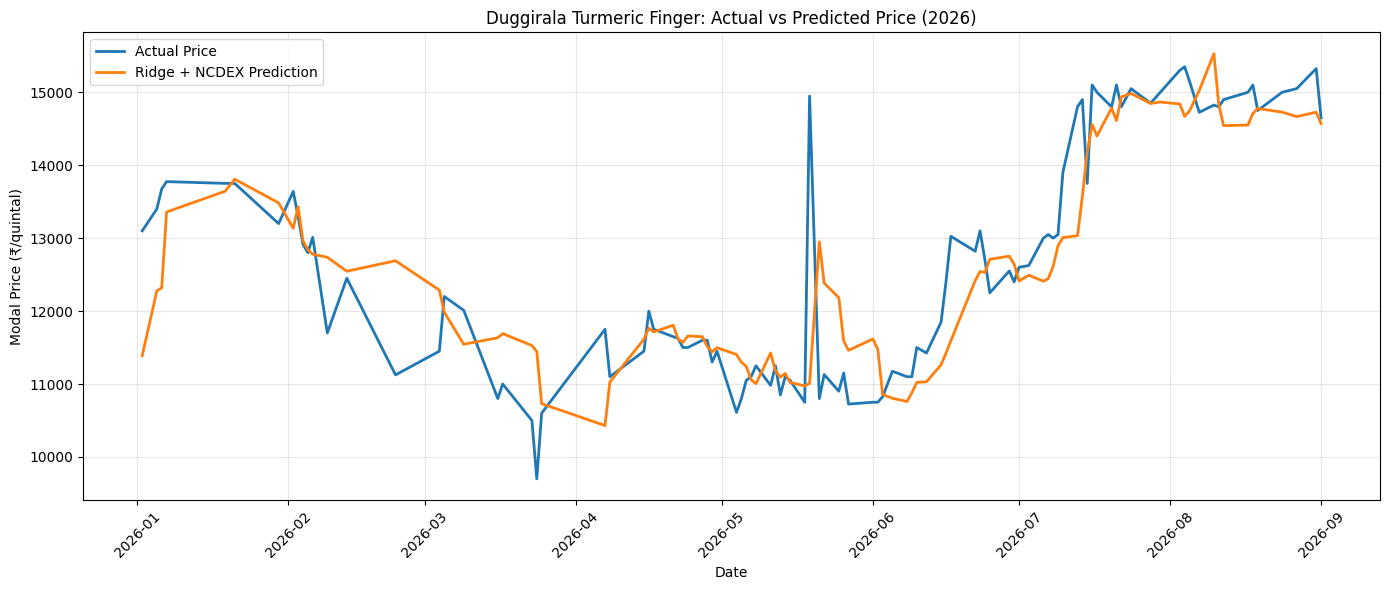

In [304]:
# ============================================================
# STEP 100A: ACTUAL VS PREDICTED PRICE
# ============================================================

import matplotlib.pyplot as plt

# Create prediction dataframe
actual_vs_pred = pd.DataFrame({
    "Arrival_Date": enhanced_common_df.loc[
        X_test_enhanced.index, "Arrival_Date"
    ].values,
    "Actual_Price": y_test_enhanced.values,
    "Predicted_Price": ridge_test_pred
})

# Sort by date
actual_vs_pred = actual_vs_pred.sort_values(
    "Arrival_Date"
).reset_index(drop=True)

# Plot
plt.figure(figsize=(14, 6))

plt.plot(
    actual_vs_pred["Arrival_Date"],
    actual_vs_pred["Actual_Price"],
    label="Actual Price",
    linewidth=2
)

plt.plot(
    actual_vs_pred["Arrival_Date"],
    actual_vs_pred["Predicted_Price"],
    label="Ridge + NCDEX Prediction",
    linewidth=2
)

plt.title(
    "Duggirala Turmeric Finger: Actual vs Predicted Price (2026)"
)

plt.xlabel("Date")
plt.ylabel("Modal Price (₹/quintal)")

plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

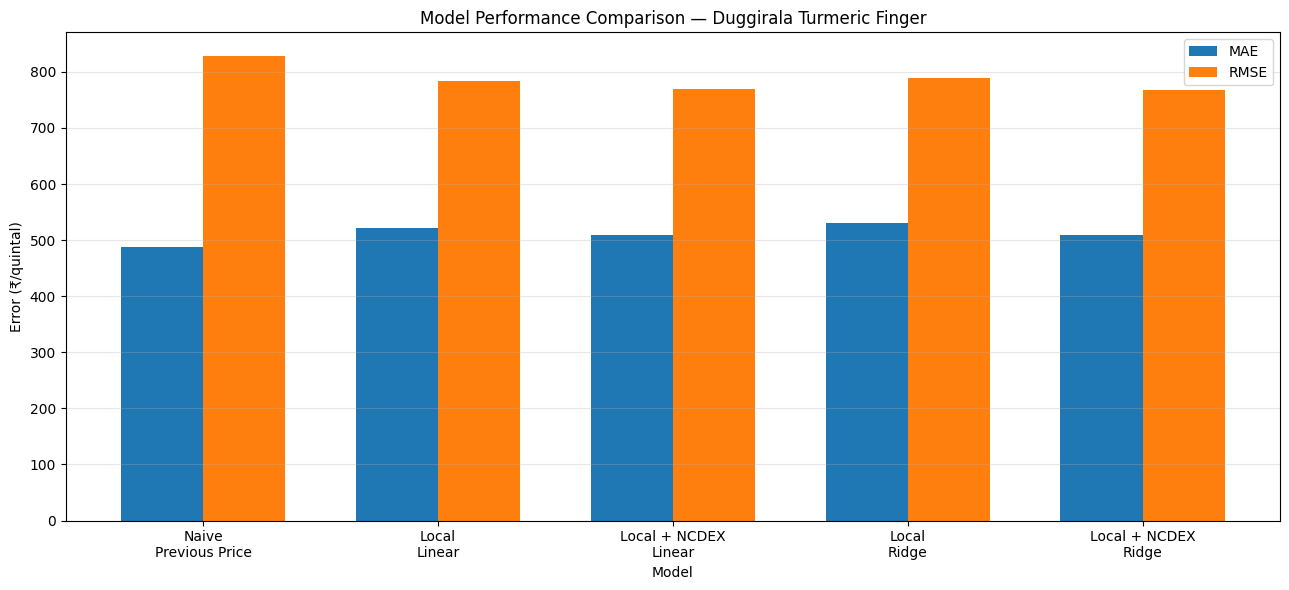

In [305]:
# ============================================================
# STEP 100B: FINAL MODEL COMPARISON VISUALIZATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Final model results on the same 102 common test observations
model_names = [
    "Naive\nPrevious Price",
    "Local\nLinear",
    "Local + NCDEX\nLinear",
    "Local\nRidge",
    "Local + NCDEX\nRidge"
]

mae_values = [
    487.38,
    521.47,
    509.96,
    531.33,
    508.58
]

rmse_values = [
    829.07,
    784.29,
    769.19,
    788.69,
    767.15
]

x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(13, 6))

plt.bar(
    x - width / 2,
    mae_values,
    width,
    label="MAE"
)

plt.bar(
    x + width / 2,
    rmse_values,
    width,
    label="RMSE"
)

plt.title(
    "Model Performance Comparison — Duggirala Turmeric Finger"
)

plt.xlabel("Model")
plt.ylabel("Error (₹/quintal)")

plt.xticks(x, model_names)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

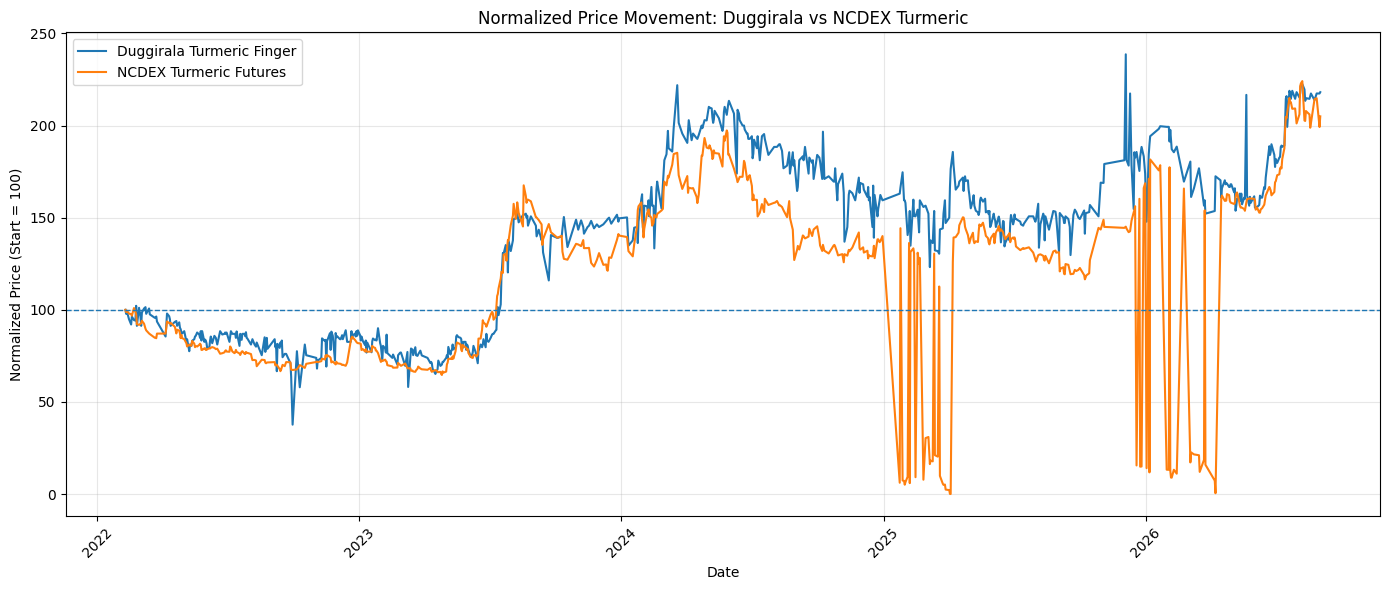

In [306]:
# ============================================================
# STEP 100C: DUGGIRALA vs NCDEX PRICE MOVEMENT
# ============================================================

# Copy the common-date dataset
comparison_df = enhanced_common_df[
    [
        "Arrival_Date",
        "Lag_1",
        "NCDEX_Close_SameContract_Lag_1"
    ]
].copy()

comparison_df = comparison_df.sort_values(
    "Arrival_Date"
).reset_index(drop=True)

# Normalize both series to 100 at the starting point
comparison_df["Duggirala_Normalized"] = (
    comparison_df["Lag_1"]
    / comparison_df["Lag_1"].iloc[0]
    * 100
)

comparison_df["NCDEX_Normalized"] = (
    comparison_df["NCDEX_Close_SameContract_Lag_1"]
    / comparison_df["NCDEX_Close_SameContract_Lag_1"].iloc[0]
    * 100
)

# Plot
plt.figure(figsize=(14, 6))

plt.plot(
    comparison_df["Arrival_Date"],
    comparison_df["Duggirala_Normalized"],
    label="Duggirala Turmeric Finger"
)

plt.plot(
    comparison_df["Arrival_Date"],
    comparison_df["NCDEX_Normalized"],
    label="NCDEX Turmeric Futures"
)

plt.axhline(
    100,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Normalized Price Movement: Duggirala vs NCDEX Turmeric"
)

plt.xlabel("Date")
plt.ylabel("Normalized Price (Start = 100)")

plt.legend()
plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

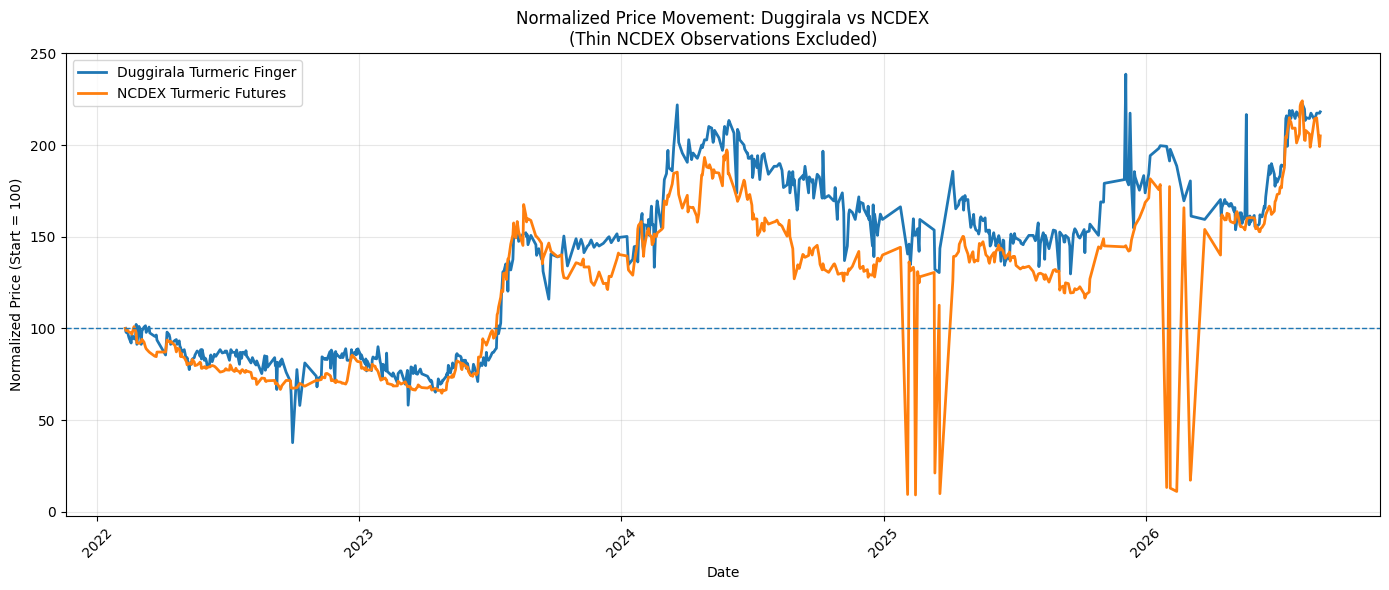

Original common observations: 705
Observations used in visualization: 662


In [309]:
# ============================================================
# STEP 100D: CLEAN NCDEX vs DUGGIRALA VISUALIZATION
# ============================================================

# Recreate the comparison dataframe with NCDEX volume included
clean_comparison = enhanced_common_df[
    [
        "Arrival_Date",
        "Lag_1",
        "NCDEX_Close_SameContract_Lag_1",
        "NCDEX_Volume_SameContract_Lag_1"
    ]
].copy()

clean_comparison = clean_comparison.sort_values(
    "Arrival_Date"
).reset_index(drop=True)

# Remove rows with missing NCDEX values
clean_comparison = clean_comparison.dropna(
    subset=[
        "NCDEX_Close_SameContract_Lag_1",
        "NCDEX_Volume_SameContract_Lag_1"
    ]
).copy()

# Keep only reasonably liquid observations for visualization
# This is ONLY for the chart.
clean_comparison = clean_comparison[
    clean_comparison["NCDEX_Volume_SameContract_Lag_1"] >= 100
].copy()

# Normalize both series to 100 at the first available observation
clean_comparison["Duggirala_Normalized"] = (
    clean_comparison["Lag_1"]
    / clean_comparison["Lag_1"].iloc[0]
    * 100
)

clean_comparison["NCDEX_Normalized"] = (
    clean_comparison["NCDEX_Close_SameContract_Lag_1"]
    / clean_comparison[
        "NCDEX_Close_SameContract_Lag_1"
    ].iloc[0]
    * 100
)

# Plot
plt.figure(figsize=(14, 6))

plt.plot(
    clean_comparison["Arrival_Date"],
    clean_comparison["Duggirala_Normalized"],
    label="Duggirala Turmeric Finger",
    linewidth=2
)

plt.plot(
    clean_comparison["Arrival_Date"],
    clean_comparison["NCDEX_Normalized"],
    label="NCDEX Turmeric Futures",
    linewidth=2
)

plt.axhline(
    100,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Normalized Price Movement: Duggirala vs NCDEX\n"
    "(Thin NCDEX Observations Excluded)"
)

plt.xlabel("Date")
plt.ylabel("Normalized Price (Start = 100)")

plt.legend()
plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print(
    f"Original common observations: "
    f"{len(enhanced_common_df)}"
)

print(
    f"Observations used in visualization: "
    f"{len(clean_comparison)}"
)

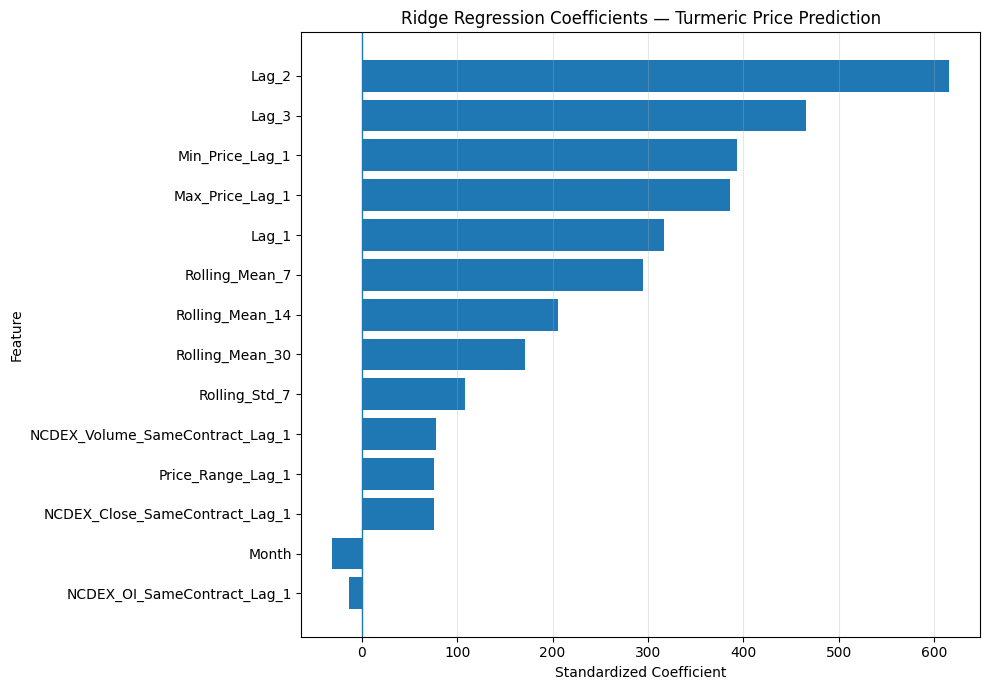

In [310]:
# ============================================================
# STEP 100E: FINAL RIDGE COEFFICIENT VISUALIZATION
# ============================================================

# Extract coefficients from the final Ridge model
ridge_coefficients = pd.DataFrame({
    "Feature": enhanced_features_final,
    "Coefficient": final_ridge_model.named_steps[
        "ridge"
    ].coef_
})

# Add absolute coefficient for sorting
ridge_coefficients["Absolute_Coefficient"] = (
    ridge_coefficients["Coefficient"].abs()
)

# Sort by absolute coefficient
ridge_coefficients = ridge_coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=True
)

# Plot
plt.figure(figsize=(10, 7))

plt.barh(
    ridge_coefficients["Feature"],
    ridge_coefficients["Coefficient"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.title(
    "Ridge Regression Coefficients — Turmeric Price Prediction"
)

plt.xlabel(
    "Standardized Coefficient"
)

plt.ylabel("Feature")

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

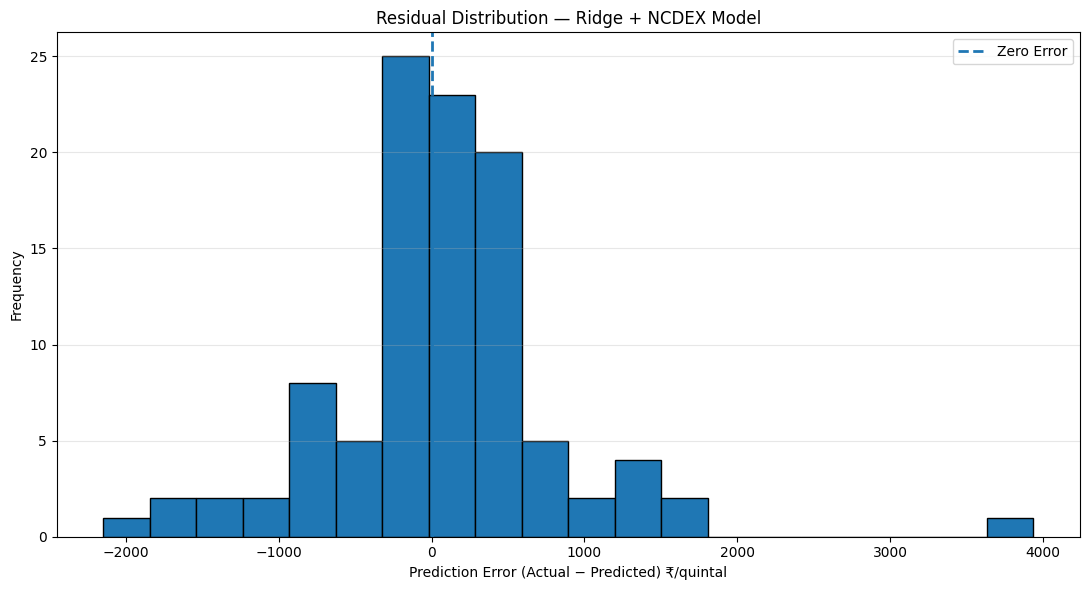

RESIDUAL SUMMARY
Mean Error:   ₹81.84
Median Error: ₹54.02
Minimum Error: ₹-2,147.73
Maximum Error: ₹3,938.67


In [311]:
# ============================================================
# STEP 100F: RESIDUAL ERROR DISTRIBUTION
# ============================================================

# Calculate residuals
residuals = (
    y_test_enhanced.values
    - ridge_test_pred
)

plt.figure(figsize=(11, 6))

plt.hist(
    residuals,
    bins=20,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2,
    label="Zero Error"
)

plt.title(
    "Residual Distribution — Ridge + NCDEX Model"
)

plt.xlabel(
    "Prediction Error (Actual − Predicted) ₹/quintal"
)

plt.ylabel(
    "Frequency"
)

plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

print("=" * 80)
print("RESIDUAL SUMMARY")
print("=" * 80)

print(
    f"Mean Error:   ₹{residuals.mean():,.2f}"
)

print(
    f"Median Error: ₹{np.median(residuals):,.2f}"
)

print(
    f"Minimum Error: ₹{residuals.min():,.2f}"
)

print(
    f"Maximum Error: ₹{residuals.max():,.2f}"
)


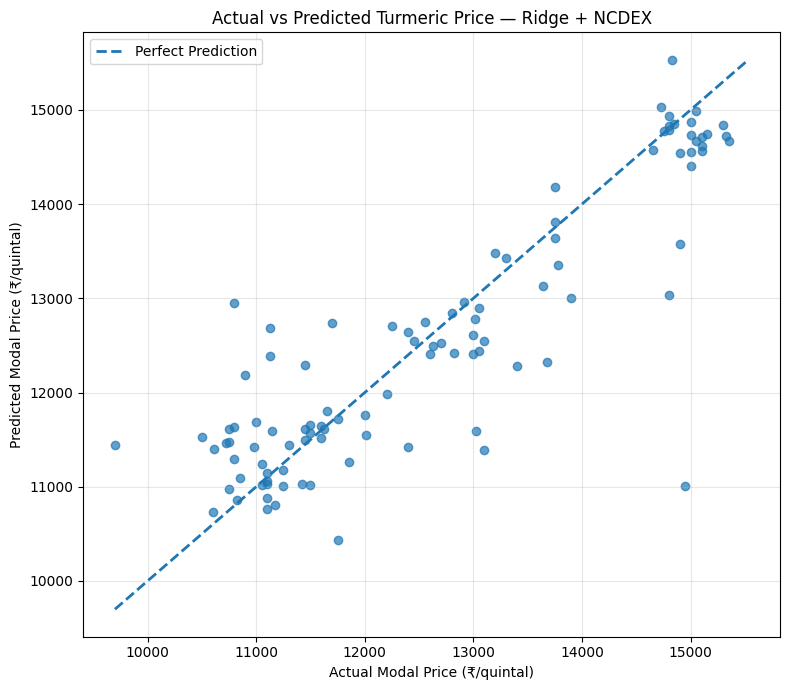

In [312]:
# ============================================================
# STEP 100G: ACTUAL VS PREDICTED SCATTER PLOT
# ============================================================

plt.figure(figsize=(8, 7))

plt.scatter(
    y_test_enhanced,
    ridge_test_pred,
    alpha=0.7
)

# Perfect prediction line
min_price = min(
    y_test_enhanced.min(),
    ridge_test_pred.min()
)

max_price = max(
    y_test_enhanced.max(),
    ridge_test_pred.max()
)

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title(
    "Actual vs Predicted Turmeric Price — Ridge + NCDEX"
)

plt.xlabel(
    "Actual Modal Price (₹/quintal)"
)

plt.ylabel(
    "Predicted Modal Price (₹/quintal)"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [313]:
# ============================================================
# STEP 101A: FINAL PROJECT SUMMARY TABLE
# ============================================================

final_summary = pd.DataFrame([
    {
        "Model": "Naive Previous Price",
        "Features": "Previous observed modal price",
        "Test MAE (₹)": 487.38,
        "Test RMSE (₹)": 829.07,
        "Test R²": 0.7291
    },
    {
        "Model": "Local Linear Regression",
        "Features": "11 local price/time features",
        "Test MAE (₹)": 521.47,
        "Test RMSE (₹)": 784.29,
        "Test R²": 0.7576
    },
    {
        "Model": "Local + NCDEX Linear",
        "Features": "11 local + 3 NCDEX features",
        "Test MAE (₹)": 509.96,
        "Test RMSE (₹)": 769.19,
        "Test R²": 0.7668
    },
    {
        "Model": "Local Ridge",
        "Features": "11 local price/time features",
        "Test MAE (₹)": 531.33,
        "Test RMSE (₹)": 788.69,
        "Test R²": 0.7549
    },
    {
        "Model": "Local + NCDEX Ridge",
        "Features": "11 local + 3 NCDEX features",
        "Test MAE (₹)": 508.58,
        "Test RMSE (₹)": 767.15,
        "Test R²": 0.7681
    }
])

print("=" * 100)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 100)

display(final_summary)

print("\n" + "=" * 100)
print("DATASET & FORECAST SUMMARY")
print("=" * 100)

print(f"Clean Duggirala Finger observations: {len(finger_df)}")
print(f"ML observations: {len(ml_df)}")
print(f"Common local + NCDEX observations: {len(enhanced_common_df)}")

print(
    f"Training observations: "
    f"{len(X_train_enhanced)}"
)

print(
    f"Untouched test observations: "
    f"{len(X_test_enhanced)}"
)

print(
    f"Training period: "
    f"{enhanced_common_df.loc[X_train_enhanced.index, 'Arrival_Date'].min().date()} "
    f"to "
    f"{enhanced_common_df.loc[X_train_enhanced.index, 'Arrival_Date'].max().date()}"
)

print(
    f"Test period: "
    f"{enhanced_common_df.loc[X_test_enhanced.index, 'Arrival_Date'].min().date()} "
    f"to "
    f"{enhanced_common_df.loc[X_test_enhanced.index, 'Arrival_Date'].max().date()}"
)

print("\n" + "=" * 100)
print("FORWARD FORECAST")
print("=" * 100)

print(
    f"Latest information date: "
    f"{forecast_record['Forecast_Date'].iloc[0].date()}"
)

print(
    f"Naive forecast: "
    f"₹{forecast_record['Naive_Prediction'].iloc[0]:,.2f}"
)

print(
    f"Ridge + NCDEX forecast: "
    f"₹{forecast_record['Ridge_NCDEX_Prediction'].iloc[0]:,.2f}"
)

print("\nBest ML model: Local + NCDEX Ridge")
print("Best ML model by RMSE: Local + NCDEX Ridge")
print("Lowest MAE overall: Naive Previous Price")....................

FINAL MODEL PERFORMANCE SUMMARY


,Model,Features,Test MAE (₹),Test RMSE (₹),Test R²
0,Naive Previous Price,Previous observed modal price,487.38,829.07,0.7291
1,Local Linear Regression,11 local price/time features,521.47,784.29,0.7576
2,Local + NCDEX Linear,11 local + 3 NCDEX features,509.96,769.19,0.7668
3,Local Ridge,11 local price/time features,531.33,788.69,0.7549
4,Local + NCDEX Ridge,11 local + 3 NCDEX features,508.58,767.15,0.7681



DATASET & FORECAST SUMMARY
Clean Duggirala Finger observations: 783
ML observations: 752
Common local + NCDEX observations: 705
Training observations: 603
Untouched test observations: 102
Training period: 2022-02-09 to 2025-12-31
Test period: 2026-01-02 to 2026-09-01

FORWARD FORECAST
Latest information date: 2026-09-07
Naive forecast: ₹15,325.00
Ridge + NCDEX forecast: ₹14,990.73

Best ML model: Local + NCDEX Ridge
Best ML model by RMSE: Local + NCDEX Ridge
Lowest MAE overall: Naive Previous Price


In [314]:
# ============================================================
# STEP 101B: VERIFY COMMON DATASET COUNTS
# ============================================================

print("=" * 80)
print("COMMON DATASET CONSISTENCY CHECK")
print("=" * 80)

print(f"enhanced_common_df rows: {len(enhanced_common_df)}")
print(f"X_train_enhanced rows:   {len(X_train_enhanced)}")
print(f"X_test_enhanced rows:    {len(X_test_enhanced)}")

print("\nDate ranges:")

print(
    "Common dataset:",
    enhanced_common_df["Arrival_Date"].min().date(),
    "to",
    enhanced_common_df["Arrival_Date"].max().date()
)

print(
    "Training:",
    enhanced_common_df.loc[
        X_train_enhanced.index,
        "Arrival_Date"
    ].min().date(),
    "to",
    enhanced_common_df.loc[
        X_train_enhanced.index,
        "Arrival_Date"
    ].max().date()
)

print(
    "Test:",
    enhanced_common_df.loc[
        X_test_enhanced.index,
        "Arrival_Date"
    ].min().date(),
    "to",
    enhanced_common_df.loc[
        X_test_enhanced.index,
        "Arrival_Date"
    ].max().date()
)

# Check whether training and test together cover the common dataset
combined_indices = set(X_train_enhanced.index).union(
    set(X_test_enhanced.index)
)

print("\nIndex coverage:")
print(
    f"Training + test unique indices: "
    f"{len(combined_indices)}"
)

print(
    f"Missing indices from common dataset: "
    f"{len(set(enhanced_common_df.index) - combined_indices)}"
)

print(
    f"Extra indices not in common dataset: "
    f"{len(combined_indices - set(enhanced_common_df.index))}"
)

COMMON DATASET CONSISTENCY CHECK
enhanced_common_df rows: 705
X_train_enhanced rows:   603
X_test_enhanced rows:    102

Date ranges:
Common dataset: 2022-02-09 to 2026-09-01
Training: 2022-02-09 to 2025-12-31
Test: 2026-01-02 to 2026-09-01

Index coverage:
Training + test unique indices: 705
Missing indices from common dataset: 0
Extra indices not in common dataset: 0


In [315]:
# ============================================================
# STEP 101C: FINAL VERIFIED PROJECT SUMMARY
# ============================================================

print("=" * 100)
print("FINAL VERIFIED PROJECT SUMMARY")
print("=" * 100)

print("\nDATASET")
print("-" * 100)

print(
    f"Clean Duggirala Turmeric Finger observations : {len(finger_df)}"
)

print(
    f"ML observations                             : {len(ml_df)}"
)

print(
    f"Local + NCDEX common observations           : "
    f"{len(enhanced_common_df)}"
)

print("\nMODEL EVALUATION")
print("-" * 100)

print(
    f"Training observations                       : "
    f"{len(X_train_enhanced)}"
)

print(
    f"Untouched test observations                 : "
    f"{len(X_test_enhanced)}"
)

print(
    f"Training period                             : "
    f"{enhanced_common_df.loc[X_train_enhanced.index, 'Arrival_Date'].min().date()} "
    f"to "
    f"{enhanced_common_df.loc[X_train_enhanced.index, 'Arrival_Date'].max().date()}"
)

print(
    f"Test period                                 : "
    f"{enhanced_common_df.loc[X_test_enhanced.index, 'Arrival_Date'].min().date()} "
    f"to "
    f"{enhanced_common_df.loc[X_test_enhanced.index, 'Arrival_Date'].max().date()}"
)

print("\nFINAL MODEL")
print("-" * 100)

print("Model                                       : Local + NCDEX Ridge")
print("Regularization                              : Ridge (alpha = 10)")
print(f"Test MAE                                    : ₹508.58")
print(f"Test RMSE                                   : ₹767.15")
print(f"Test R²                                     : 0.7681")

print("\nBASELINE COMPARISON")
print("-" * 100)

print(f"Naive MAE                                   : ₹487.38")
print(f"Naive RMSE                                  : ₹829.07")
print(f"Naive R²                                    : 0.7291")

print("\nFORWARD FORECAST")
print("-" * 100)

print(
    f"Latest information date                    : "
    f"{forecast_record['Forecast_Date'].iloc[0].date()}"
)

print(
    f"Naive forecast                              : "
    f"₹{forecast_record['Naive_Prediction'].iloc[0]:,.2f}"
)

print(
    f"Ridge + NCDEX forecast                      : "
    f"₹{forecast_record['Ridge_NCDEX_Prediction'].iloc[0]:,.2f}"
)

print("\nKEY CONCLUSIONS")
print("-" * 100)

print("• Naive Previous Price achieved the lowest MAE.")
print("• Local + NCDEX Ridge achieved the lowest RMSE among tested models.")
print("• Local + NCDEX Ridge achieved the highest R² among tested models.")
print("• Recent local mandi price history remains the dominant signal.")
print("• NCDEX futures provide incremental predictive information.")
print("• Sudden price shocks remain a major source of prediction error.")

FINAL VERIFIED PROJECT SUMMARY

DATASET
----------------------------------------------------------------------------------------------------
Clean Duggirala Turmeric Finger observations : 783
ML observations                             : 752
Local + NCDEX common observations           : 705

MODEL EVALUATION
----------------------------------------------------------------------------------------------------
Training observations                       : 603
Untouched test observations                 : 102
Training period                             : 2022-02-09 to 2025-12-31
Test period                                 : 2026-01-02 to 2026-09-01

FINAL MODEL
----------------------------------------------------------------------------------------------------
Model                                       : Local + NCDEX Ridge
Regularization                              : Ridge (alpha = 10)
Test MAE                                    : ₹508.58
Test RMSE                                   : ₹7

In [316]:
# ============================================================
# STEP 102A: SAVE FINAL PROJECT ARTIFACTS
# ============================================================

# ------------------------------------------------------------
# 1. Save cleaned Duggirala Turmeric Finger data
# ------------------------------------------------------------

finger_df.to_csv(
    "/content/duggirala_turmeric_finger_clean.csv",
    index=False
)


# ------------------------------------------------------------
# 2. Save NCDEX feature data
# ------------------------------------------------------------

final_ncdex_features.to_csv(
    "/content/ncdex_turmeric_features.csv",
    index=False
)


# ------------------------------------------------------------
# 3. Save final model comparison results
# ------------------------------------------------------------

final_summary.to_csv(
    "/content/final_model_results.csv",
    index=False
)


# ------------------------------------------------------------
# 4. Save forward forecast
# ------------------------------------------------------------

forecast_record.to_csv(
    "/content/forward_forecast.csv",
    index=False
)


# ------------------------------------------------------------
# Verify files
# ------------------------------------------------------------

import os

saved_files = [
    "/content/duggirala_turmeric_finger_clean.csv",
    "/content/ncdex_turmeric_features.csv",
    "/content/final_model_results.csv",
    "/content/forward_forecast.csv"
]

print("=" * 80)
print("FINAL PROJECT ARTIFACTS")
print("=" * 80)

for file_path in saved_files:
    file_name = os.path.basename(file_path)
    file_size_kb = os.path.getsize(file_path) / 1024

    print(
        f"✓ {file_name:<40} "
        f"{file_size_kb:.2f} KB"
    )

print("\nAll artifacts saved successfully.")

FINAL PROJECT ARTIFACTS
✓ duggirala_turmeric_finger_clean.csv      82.34 KB
✓ ncdex_turmeric_features.csv              31.15 KB
✓ final_model_results.csv                  0.39 KB
✓ forward_forecast.csv                     0.09 KB

All artifacts saved successfully.
